In [3]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import sys
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

In [4]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output




In [5]:
def train(args, model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if args.dry_run:
                break




In [6]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))




In [6]:
def main():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)
    optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adadelta.pt")



In [18]:
main()

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.425185
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.826558
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.549871
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.466674
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.237647
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.345377
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.339175
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.549706
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.149705
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.178642
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.223440
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.170541
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.125893
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.256454
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.151332
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.518159
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.179029
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.683120
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.163260
Train Epoch: 1 [12800/60000 (

In [21]:
model

Net(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=9216, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [16]:
def show_filters(tensor, title="", n_cols=8):
    weights = tensor.detach().cpu().numpy()
    num_filters = weights.shape[0]

    n_rows = (num_filters + n_cols - 1) // n_cols
    plt.figure(figsize=(n_cols, n_rows))

    for i in range(num_filters):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(weights[i, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()



In [8]:
model.load_state_dict(torch.load("mnist_cnn.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



NameError: name 'model' is not defined

In [56]:
def main_sgd():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=1.2)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgd.pt")



In [57]:
main_sgd()

'''
optimizer = optim.SGD(model.parameters(), lr=0.01)
Test set: Average loss: 0.0882, Accuracy: 9726/10000 (97%)

optimizer = optim.SGD(model.parameters(), lr=1.0)
Test set: Average loss: 0.0395, Accuracy: 9885/10000 (99%)

optimizer = optim.SGD(model.parameters(), lr=1.2)
Test set: Average loss: nan, Accuracy: 980/10000 (10%) 
(getting nan with lr=1.2)


'''


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.322717
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.315641
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.305345
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.299341
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.070292
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.510176
Train Epoch: 1 [4480/60000 (7%)]	Loss: nan
Train Epoch: 1 [5120/60000 (9%)]	Loss: nan
Train Epoch: 1 [5760/60000 (10%)]	Loss: nan
Train Epoch: 1 [6400/60000 (11%)]	Loss: nan
Train Epoch: 1 [7040/60000 (12%)]	Loss: nan
Train Epoch: 1 [7680/60000 (13%)]	Loss: nan
Train Epoch: 1 [8320/60000 (14%)]	Loss: nan
Train Epoch: 1 [8960/60000 (15%)]	Loss: nan
Train Epoch: 1 [9600/60000 (16%)]	Loss: nan
Train Epoch: 1 [10240/60000 (17%)]	Loss: nan
Train Epoch: 1 [10880/60000 (18%)]	Loss: nan
Train Epoch: 1 [11520/60000 (19%)]	Loss: nan
Train Epoch: 1 [12160/60000 (20%)]	Loss: nan
Train Epoch: 1 [12800/60000 (21%)]	Loss: nan
Train Epoch: 1 [13440/60000 (22%)]	Loss: nan
Trai

'\noptimizer = optim.SGD(model.parameters(), lr=0.01)\nTest set: Average loss: 0.0882, Accuracy: 9726/10000 (97%)\n\noptimizer = optim.SGD(model.parameters(), lr=1.0)\nTest set: Average loss: 0.0395, Accuracy: 9885/10000 (99%)\n'

In [58]:
def main_sgdm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.99)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgdm.pt")

In [59]:
main_sgdm()

'''
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 0.0261, Accuracy: 9912/10000 (99%)

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.99)
Test set: Average loss: 0.0420, Accuracy: 9878/10000 (99%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.670773
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.188098
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.320078
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.722977
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.732016
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.410951
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.615599
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.730029
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.316684
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.534505
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.384778
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.453915
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.301764
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.369559
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.426173
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.655002
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.449713
Train Epoch: 1 [11520/60000 (19%)]	Loss: 0.523219
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.539102
Train Epoch: 1 [12800/60000 (

'\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)\nTest set: Average loss: 0.0261, Accuracy: 9912/10000 (99%)\n\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.99)\n\n'

In [46]:
def main_rmsprop():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=5, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    optimizer = optim.RMSprop(model.parameters(), lr=0.01, alpha=0)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_rmsprop.pt")

In [47]:
main_rmsprop()

'''
optimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=0.1)
Test set: Average loss: 2.3015, Accuracy: 1135/10000 (11%)

optimizer = optim.RMSprop(model.parameters(), lr=0.1, alpha=0.9)
Test set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)

optimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.9)
Test set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)

optimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.99)
Test set: Average loss: 2.3014, Accuracy: 1028/10000 (10%)

optimizer = optim.RMSprop(model.parameters(), lr=5.0, alpha=0.99)
args.seed = 5
Test set: Average loss: 2.3029, Accuracy: 958/10000 (10%)

optimizer = optim.RMSprop(model.parameters(), lr=0.01, alpha=0.9)
Test set: Average loss: 0.0549, Accuracy: 9854/10000 (99%)

optimizer = optim.RMSprop(model.parameters(), lr=0.01, alpha=0)
Test set: Average loss: 0.6847, Accuracy: 8327/10000 (83%)

optimizer = optim.RMSprop(model.parameters(), lr=0.1, alpha=0)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303526
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.670716
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.102187
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.879362
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.701761
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.471461
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.399277
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.622334
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.108883
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.587326
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.611356
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.494653
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.267901
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.482944
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.586184
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.554965
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.038285
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.092375
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.951772
Train Epoch: 1 [12160/60000 (20%)]	Loss: 0.954207
Train Epoch: 1 [12800/60000 (

'\noptimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=0.1)\nTest set: Average loss: 2.3015, Accuracy: 1135/10000 (11%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=0.1, alpha=0.9)\nTest set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.9)\nTest set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=1.0, alpha=0.99)\nTest set: Average loss: 2.3014, Accuracy: 1028/10000 (10%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=5.0, alpha=0.99)\nargs.seed = 5\nTest set: Average loss: 2.3029, Accuracy: 958/10000 (10%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=0.01, alpha=0.9)\nTest set: Average loss: 0.0549, Accuracy: 9854/10000 (99%)\n\noptimizer = optim.RMSprop(model.parameters(), lr=0.01, alpha=0)\n\noptimizer = optim.RMSprop(model.parameters(), lr=0.1, alpha=0)\n\n'

In [48]:
def main_adam():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.1, betas=(0.9, 0.9))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam.pt")

In [49]:
main_adam()

'''
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0603, Accuracy: 9816/10000 (98%)

optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.9))
Test set: Average loss: 0.0665, Accuracy: 9814/10000 (98%)

optimizer = optim.Adam(model.parameters(), lr=0.1, betas=(0.9, 0.9))
Test set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)
'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.406596
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.319671
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.298556
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.317286
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.308151
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.304833
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.314755
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.297322
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.300519
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.303669
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.303398
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.317595
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.301389
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.290324
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.293242
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.302644
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.311171
Train Epoch: 1 [11520/60000 (19%)]	Loss: 2.307514
Train Epoch: 1 [12160/60000 (20%)]	Loss: 2.304625
Train Epoch: 1 [12800/60000 (

'\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\nTest set: Average loss: 0.0603, Accuracy: 9816/10000 (98%)\n\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.9))\nTest set: Average loss: 0.0665, Accuracy: 9814/10000 (98%)\n\noptimizer = optim.Adam(model.parameters(), lr=0.1, betas=(0.9, 0.9))\n'

In [53]:
class Net_noDropout(nn.Module):
    def __init__(self):
        super(Net_noDropout, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        # self.dropout1 = nn.Dropout(0.25)
        # self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        # x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        # x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output




In [54]:
def main_sgdm_nodropout():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=16, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_noDropout().to(device)

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgdm_nodropout.pt")

In [55]:
main_sgdm_nodropout()

'''
model = Net_noDropout().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 0.0296, Accuracy: 9906/10000 (99%)

smaller sample size to highlight overfitting without dropout

less epochs

reducing training batch size to from 64 to 16
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

'''


Train Epoch: 1 [0/60000 (0%)]	Loss: 2.285062
Train Epoch: 1 [160/60000 (0%)]	Loss: 1.880776
Train Epoch: 1 [320/60000 (1%)]	Loss: 0.837236
Train Epoch: 1 [480/60000 (1%)]	Loss: 1.272978
Train Epoch: 1 [640/60000 (1%)]	Loss: 0.985802
Train Epoch: 1 [800/60000 (1%)]	Loss: 0.635985
Train Epoch: 1 [960/60000 (2%)]	Loss: 0.990984
Train Epoch: 1 [1120/60000 (2%)]	Loss: 0.972561
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.582339
Train Epoch: 1 [1440/60000 (2%)]	Loss: 0.147823
Train Epoch: 1 [1600/60000 (3%)]	Loss: 0.376112
Train Epoch: 1 [1760/60000 (3%)]	Loss: 0.275154
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.617722
Train Epoch: 1 [2080/60000 (3%)]	Loss: 0.281659
Train Epoch: 1 [2240/60000 (4%)]	Loss: 0.239041
Train Epoch: 1 [2400/60000 (4%)]	Loss: 0.603859
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.162454
Train Epoch: 1 [2720/60000 (5%)]	Loss: 0.389944
Train Epoch: 1 [2880/60000 (5%)]	Loss: 0.316798
Train Epoch: 1 [3040/60000 (5%)]	Loss: 0.104633
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.433630
T

'\nmodel = Net_noDropout().to(device)\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)\nTest set: Average loss: 0.0296, Accuracy: 9906/10000 (99%)\n\nsmaller sample size to highlight overfitting without dropout\n\nless epochs\n\nreducing training batch size to from 64 to 16\n'

tensor([[[[ 0.1546, -0.1279,  0.0060],
          [ 0.3014,  0.0208, -0.0952],
          [-0.0553, -0.1887, -0.2396]]],


        [[[-0.1284, -0.3100,  0.2135],
          [ 0.0586,  0.3154,  0.3085],
          [ 0.1835,  0.0221,  0.2448]]],


        [[[ 0.3305, -0.2168,  0.0647],
          [-0.3223,  0.2064, -0.0312],
          [ 0.2848,  0.2624,  0.1899]]],


        [[[ 0.2289,  0.1780, -0.0513],
          [-0.1814,  0.2392, -0.1478],
          [-0.0978,  0.2308, -0.1116]]],


        [[[-0.0178, -0.2072,  0.2734],
          [ 0.0463, -0.0479, -0.0965],
          [-0.3159, -0.0565, -0.3098]]],


        [[[ 0.2983,  0.1564, -0.0656],
          [ 0.0783,  0.2243,  0.0060],
          [-0.2578, -0.1873, -0.2903]]],


        [[[-0.3092,  0.1844, -0.0714],
          [ 0.0638, -0.0959,  0.3185],
          [-0.0493, -0.3193,  0.0185]]],


        [[[ 0.0857,  0.0201, -0.0895],
          [ 0.2569,  0.2824,  0.0489],
          [ 0.2343, -0.0660,  0.2935]]],


        [[[-0.2436,  0.2872, -0.

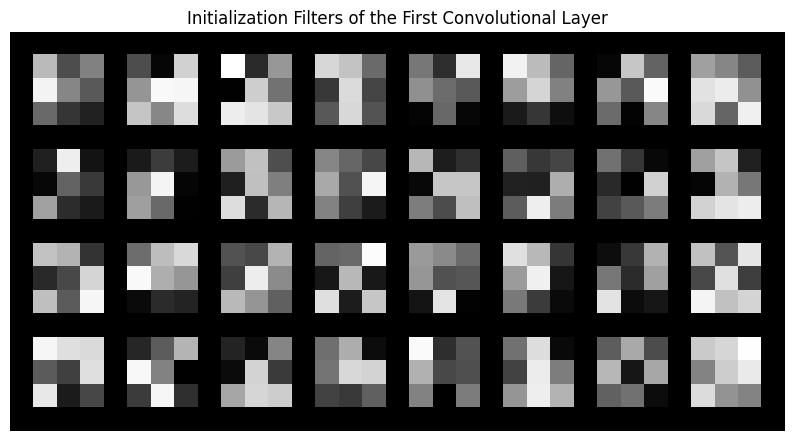

In [35]:
# Check initialization of convolutional layer filters

model = Net()
print(model.conv1.weight.data)

def visualize_filters(weights_tensor, nrow=8):
    weights_tensor = weights_tensor - weights_tensor.min()
    weights_tensor = weights_tensor / weights_tensor.max()
    grid = make_grid(weights_tensor, nrow=nrow, normalize=True, padding=1)
    image_grid = grid.permute(1, 2, 0)
    return image_grid

filter_image_grid = visualize_filters(model.conv1.weight.data)
plt.figure(figsize=(10, 10))
plt.imshow(filter_image_grid)
plt.axis('off')
plt.title('Initialization Filters of the First Convolutional Layer')
plt.show()

# how did they get these values for initialization?

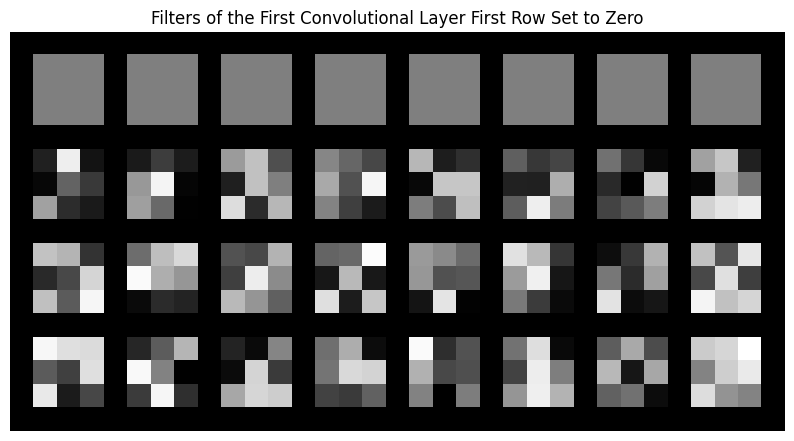

In [36]:
# Set first row to zeros
model.conv1.weight.data[0:8].zero_()
filter_image_grid_zero = visualize_filters(model.conv1.weight.data)
plt.figure(figsize=(10, 10))
plt.imshow(filter_image_grid_zero)
plt.axis('off')
plt.title('Filters of the First Convolutional Layer First Row Set to Zero')
plt.show()


tensor([[[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0., 0., 0.],
          [0., 0., 0.],
          [0., 0., 0.]]],


        [[[0

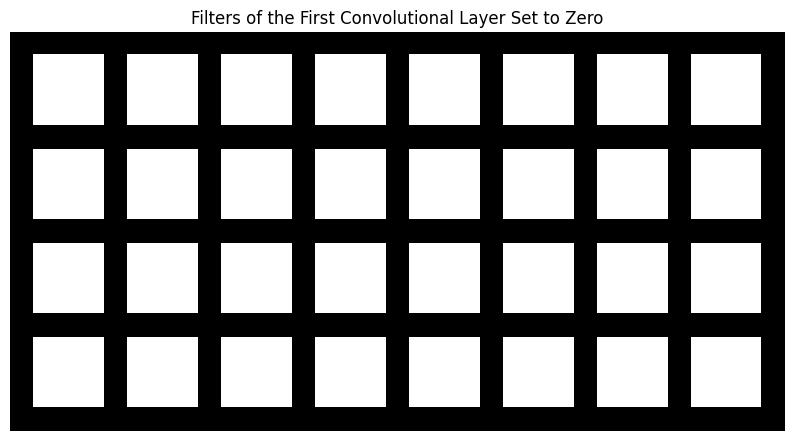

In [37]:
# Observe training with zeroed filters
model.conv1.weight.data.zero_()
print(model.conv1.weight.data)
filter_image_grid_zero = visualize_filters(model.conv1.weight.data)
plt.figure(figsize=(10, 10))
plt.imshow(filter_image_grid_zero)
plt.axis('off')
plt.title('Filters of the First Convolutional Layer Set to Zero')
plt.show()

In [39]:
def main_sgdm_zeroed():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)
    model.conv1.weight.data.zero_()
    model.conv2.weight.data.zero_()
    model.fc1.weight.data.zero_()
    model.fc2.weight.data.zero_()
    model.conv1.bias.data.zero_()
    model.conv2.bias.data.zero_()
    model.fc1.bias.data.zero_()
    model.fc2.bias.data.zero_()

    # optimizer = optim.Adadelta(model.parameters(), lr=args.lr)
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_sgdm_zeroed.pt")

In [40]:
main_sgdm_zeroed()

'''
conv1 weights  initialized to zero
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 0.0292, Accuracy: 9909/10000 (99%)

conv1, conv2, fc1, fc2 weights and biases all initialized to zero
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
Test set: Average loss: 2.3010, Accuracy: 1135/10000 (11%)

optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.302585
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.299675
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.307856
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.299567
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.303746
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.304118
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.301752
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.299236
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.298639
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.288369
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.293234
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.297627
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.308188
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.298060
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.280191
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.291197
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.296446
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.309552
Train Epoch: 1 [11520/60000 (19%)]	Loss: 2.296255
Train Epoch: 1 [12160/60000 (20%)]	Loss: 2.297983
Train Epoch: 1 [12800/60000 (

'\nconv1 weights  initialized to zero\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)\nTest set: Average loss: 0.0292, Accuracy: 9909/10000 (99%)\n\nconv1, conv2, fc1, fc2 weights and biases all initialized to zero\noptimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)\nTest set: Average loss: 2.3010, Accuracy: 1135/10000 (11%)\n\noptimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)\n'

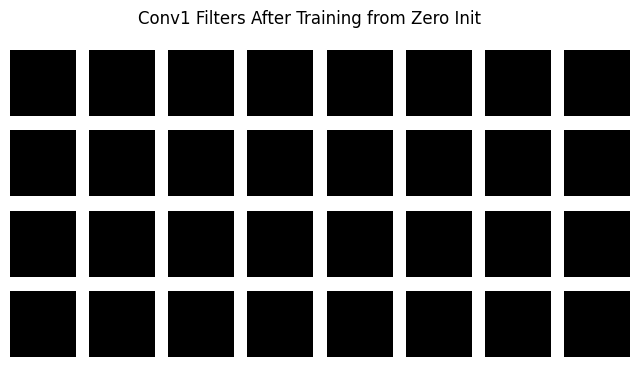

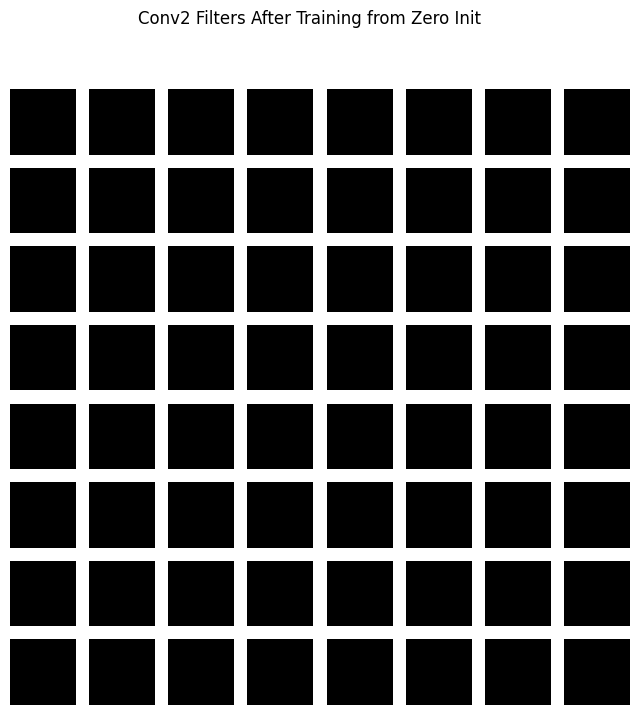

In [34]:
model = Net()
model.load_state_dict(torch.load("mnist_cnn_sgdm_zeroed.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters After Training from Zero Init")
show_filters(model.conv2.weight, "Conv2 Filters After Training from Zero Init")

In [12]:
def visualize_fc_weights(fc1_weights, fc1_caption, fc2_weights, fc2_caption):
    fc1_weights = fc1_weights.view(fc1_weights.size(0), -1)
    fc2_weights = fc2_weights.view(fc2_weights.size(0), -1)

    # Each row represents one neuron, each column represents one input feature
    plt.figure(figsize=(20, 8))
    plt.imshow(fc1_weights, cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.title(fc1_caption)
    plt.xlabel('Input Features')
    plt.ylabel('Neurons')
    plt.tight_layout()
    plt.show()

    # Each row represents one output class, each column represents one hidden neuron
    plt.figure(figsize=(12, 4))
    plt.imshow(fc2_weights, cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.title(fc2_caption)
    plt.xlabel('Hidden Neurons')
    plt.ylabel('Output Classes')
    plt.tight_layout()
    plt.show()

In [11]:
import torchvision.utils as vutils
from torchvision.transforms.functional import to_pil_image
from IPython.display import display
def visualize_fc(fc_weights):
    
    weights = fc_weights.data.clone().cpu() 
    num_neurons = weights.shape[0]
    image_size = int(weights.shape[1] ** 0.5)  

    # reshape to (N, 1, H, W)
    weights_reshaped = weights.view(num_neurons, 1, image_size, image_size)

    # scale for visibility
    grid = vutils.make_grid(weights_reshaped, nrow=16, normalize=True)
    display(to_pil_image(grid))

In [31]:
# Gradual zeroing of layers

def main_weights_zeroing(layers_to_zero=['conv1', 'conv2', 'fc1', 'fc2']):
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=256, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=3, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net().to(device)
    if 'conv1' in layers_to_zero:
        model.conv1.weight.data.zero_()
        model.conv1.bias.data.zero_()
    if 'conv2' in layers_to_zero:
        model.conv2.weight.data.zero_()
        model.conv2.bias.data.zero_()
    if 'fc1' in layers_to_zero:
        model.fc1.weight.data.zero_()
        model.fc1.bias.data.zero_()
    if 'fc2' in layers_to_zero:
        model.fc2.weight.data.zero_()
        model.fc2.bias.data.zero_()

    # Store copies of weights BEFORE training
    conv1_weights_before = model.conv1.weight.data.clone().cpu()
    conv2_weights_before = model.conv2.weight.data.clone().cpu()
    fc1_weights_before = model.fc1.weight.data.clone().cpu()
    fc2_weights_before = model.fc2.weight.data.clone().cpu()

    show_filters(conv1_weights_before, "Conv1 Filters Before Training")
    show_filters(conv2_weights_before, "Conv2 Filters Before Training")
    # visualize_fc_weights(fc1_weights_before, "FC1 Weights Before Training with Adadelta", fc2_weights_before, "FC2 Weights Before Training with Adadelta")

    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)    

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    # Store copies of weights AFTER training
    conv1_weights_after = model.conv1.weight.data.clone().cpu()
    conv2_weights_after = model.conv2.weight.data.clone().cpu()
    fc1_weights_after = model.fc1.weight.data.clone().cpu()
    fc2_weights_after = model.fc2.weight.data.clone().cpu()

    show_filters(conv1_weights_after, "Conv1 Filters After Training ")
    show_filters(conv2_weights_after, "Conv2 Filters After Training ")
    # visualize_fc_weights(fc1_weights_after, "FC1 Weights After Training with Adadelta", fc2_weights_after, "FC2 Weights After Training with Adadelta")

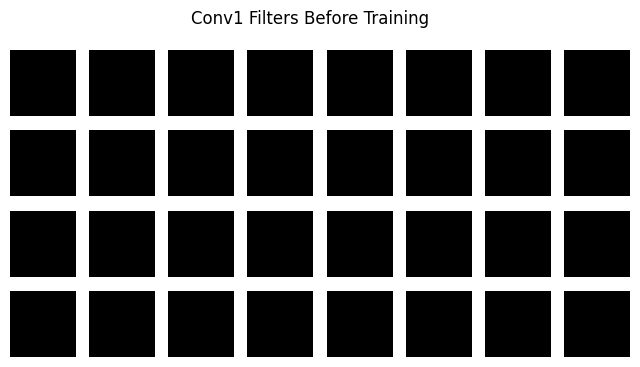

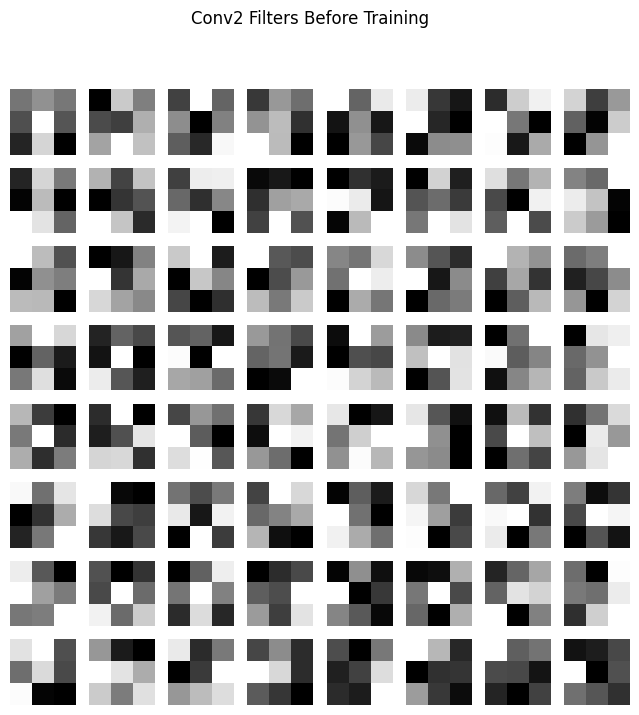

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.302010
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.301710
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.301710
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.302368
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.302368
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.302802
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.302802
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.302712
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.302712
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.296898
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.296898
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.301486
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.301486
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.303156
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.303156
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.299460
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.299460
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.287478
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.287478
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.305367
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.

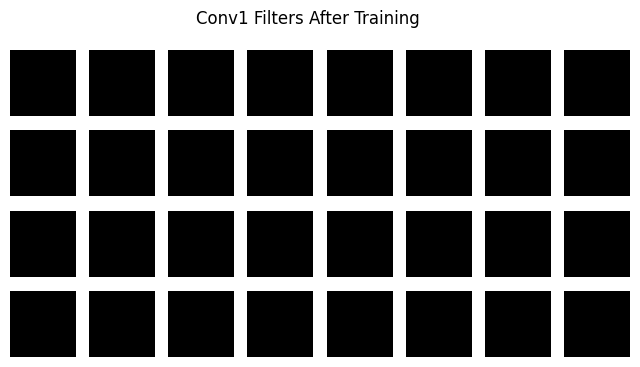

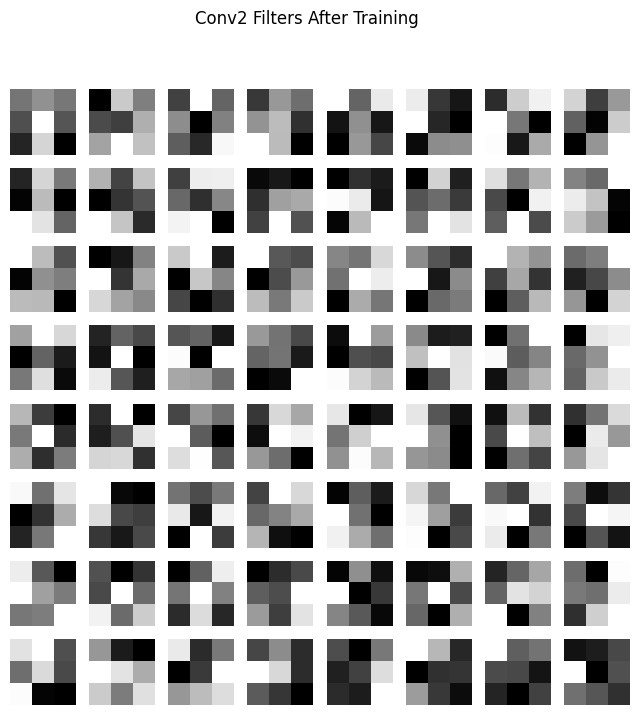

In [30]:
main_weights_zeroing(layers_to_zero=['conv1'])

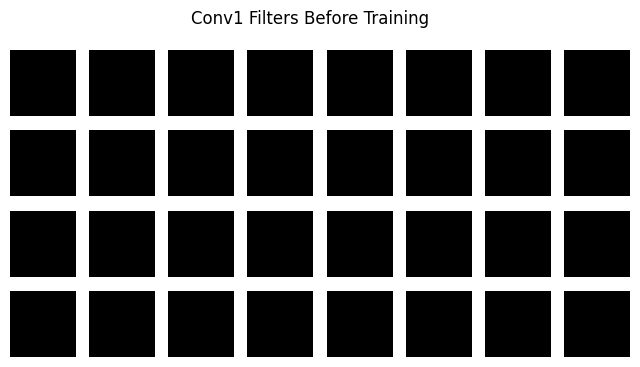

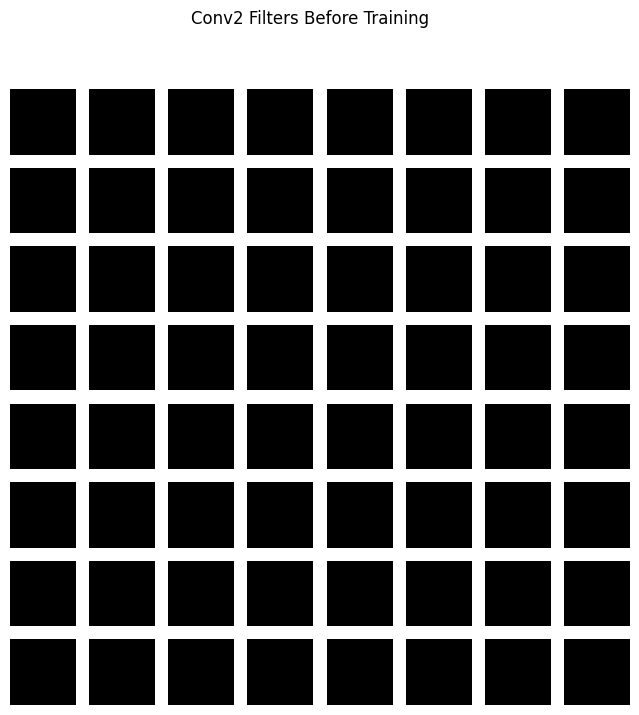

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303948
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.302402
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.302402
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.305942
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.305942
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.306483
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.306483
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.301539
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.301539
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.303437
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.303437
Train Epoch: 1 [15360/60000 (26%)]	Loss: 2.302253
Train Epoch: 1 [15360/60000 (26%)]	Loss: 2.302253
Train Epoch: 1 [17920/60000 (30%)]	Loss: 2.298715
Train Epoch: 1 [17920/60000 (30%)]	Loss: 2.298715
Train Epoch: 1 [20480/60000 (34%)]	Loss: 2.305740
Train Epoch: 1 [20480/60000 (34%)]	Loss: 2.305740
Train Epoch: 1 [23040/60000 (38%)]	Loss: 2.300934
Train Epoch: 1 [23040/60000 (38%)]	Loss: 2.300934
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.298548
Train Epoch: 1 

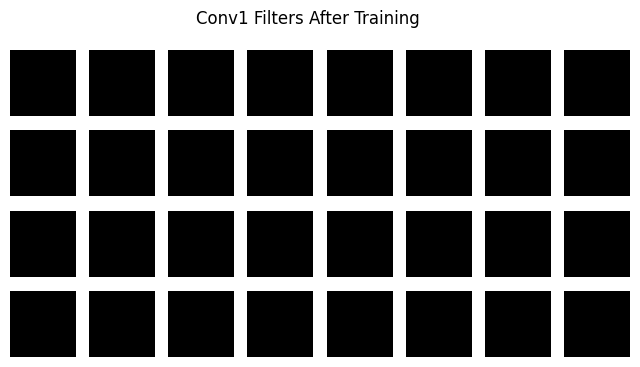

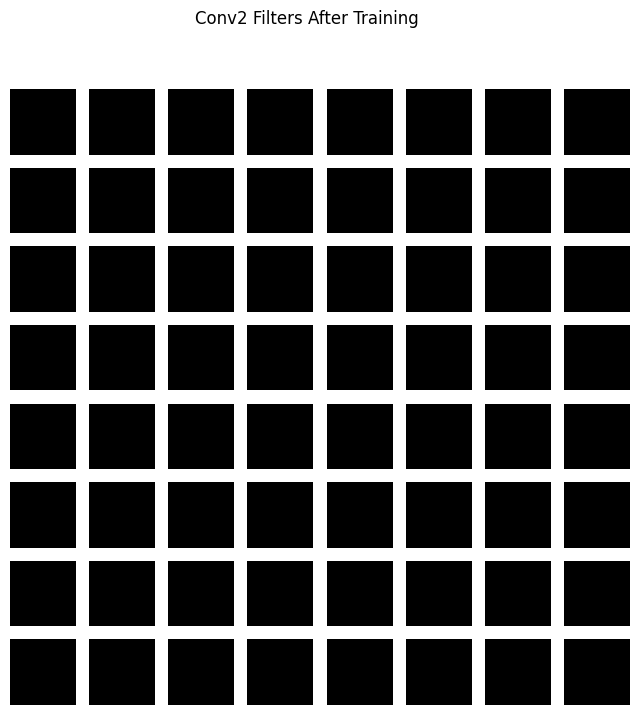

In [32]:
main_weights_zeroing(layers_to_zero=['conv1', 'conv2'])

In [10]:
class Net_LayerNorm(nn.Module):
    def __init__(self):
        super(Net_LayerNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.ln1 = nn.LayerNorm([32, 26, 26])
        self.ln2 = nn.LayerNorm([64, 24, 24])

    def forward(self, x):
        x = self.conv1(x)
        x = self.ln1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.ln2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [11]:
def main_adam_layernorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_LayerNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_layernorm.pt")

In [12]:
main_adam_layernorm()
'''
LayerNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0566, Accuracy: 9858/10000 (99%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.420038
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.796321
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.549538
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.379646
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.657637
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.259333
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.394978
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.177463
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.566705
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.177794
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.292620
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.233553
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.035632
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.337056
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.179683
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.469626
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.389325
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.253484
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.156397
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.434880
Train Epoch: 1 [12800/60000 (

'\nLayerNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\nTest set: Average loss: 0.0566, Accuracy: 9858/10000 (99%)\n\n'

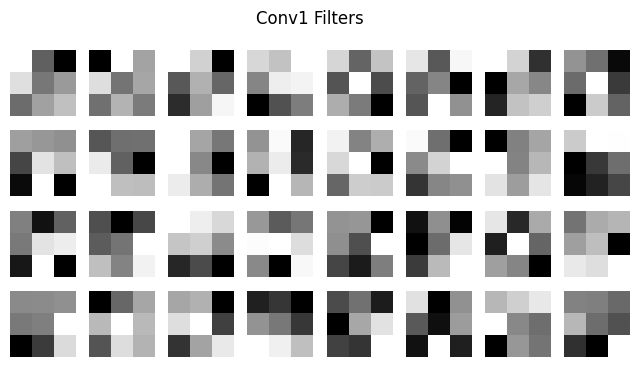

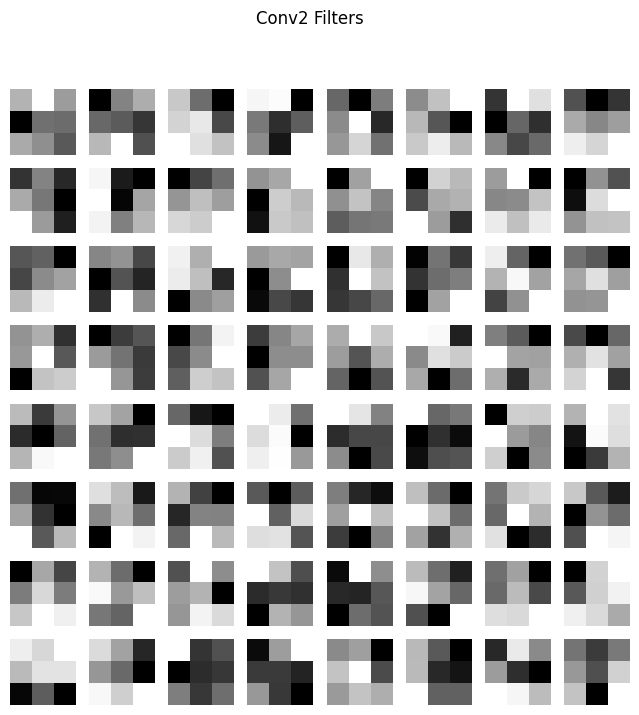

In [19]:
model = Net_LayerNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_layernorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [33]:
class Net_BatchNorm(nn.Module):
    def __init__(self):
        super(Net_BatchNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [21]:
def main_adam_batchnorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_BatchNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_batchnorm.pt")

In [22]:
main_adam_batchnorm()
'''
BatchNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0350, Accuracy: 9907/10000 (99%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.377147
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.782639
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.779488
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.485038
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.739862
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.321220
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.347836
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.414182
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.407821
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.247865
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.987620
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.277637
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.990640
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.015910
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.861521
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.594289
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.250536
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.858826
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.059705
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.262506
Train Epoch: 1 [12800/60000 (

'\nBatchNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\n\n\n'

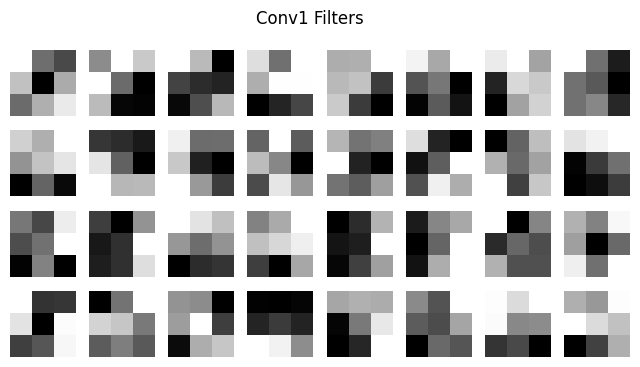

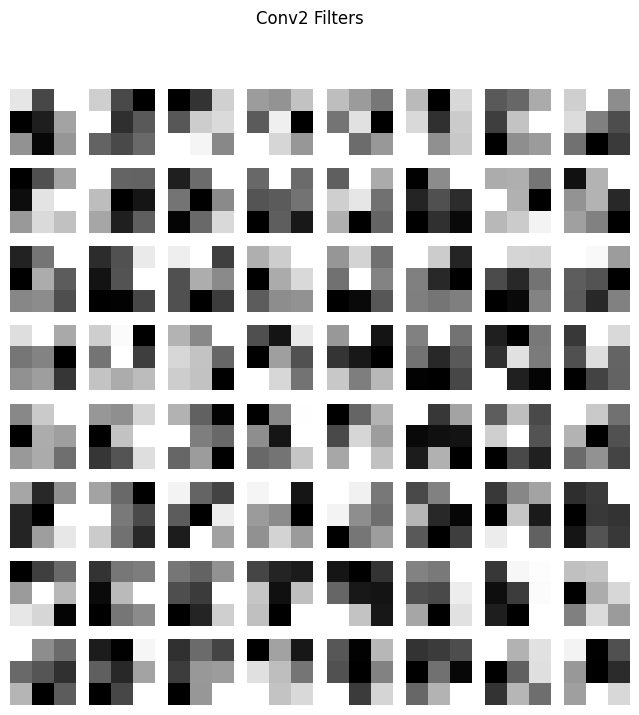

In [23]:
model = Net_BatchNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_batchnorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [24]:
class Net_GroupNorm(nn.Module):
    def __init__(self):
        super(Net_GroupNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.gn1 = nn.GroupNorm(8, 32)
        self.gn2 = nn.GroupNorm(8, 64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.gn1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.gn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [27]:
def main_adam_groupnorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_GroupNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_groupnorm.pt")

In [28]:
main_adam_groupnorm()
'''
GroupNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.0373, Accuracy: 9905/10000 (99%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.393244
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.127675
Train Epoch: 1 [1280/60000 (2%)]	Loss: 1.689615
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.618227
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.461939
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.264604
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.385481
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.217778
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.531035
Train Epoch: 1 [5760/60000 (10%)]	Loss: 1.327949
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.142339
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.152959
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.139345
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.223134
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.086034
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.422279
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.344761
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.092546
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.828579
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.381839
Train Epoch: 1 [12800/60000 (

'\nGroupNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\n\n\n'

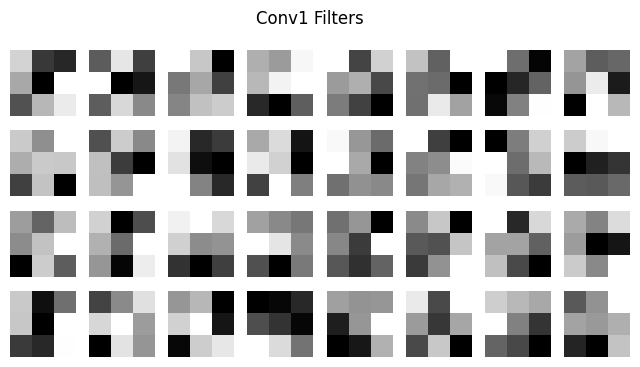

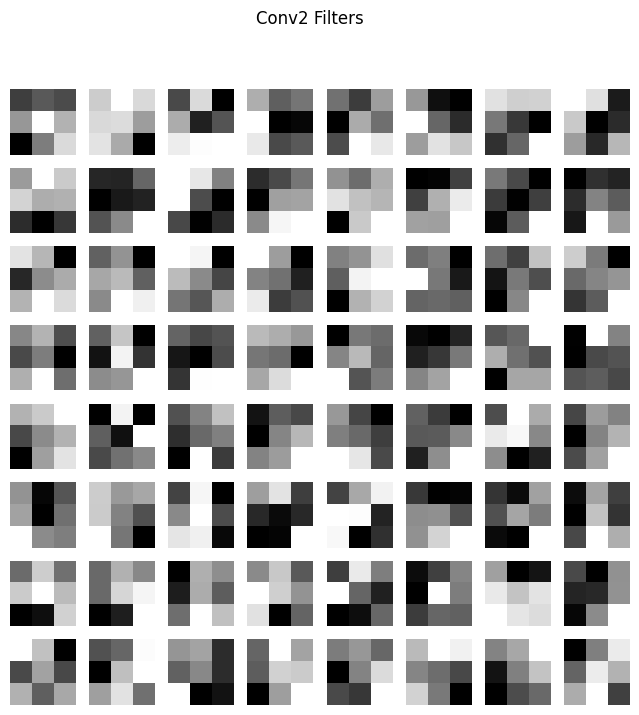

In [29]:
model = Net_GroupNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_groupnorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")



In [8]:
class Net_InstanceNorm(nn.Module):
    def __init__(self):
        super(Net_InstanceNorm, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)
        self.in1 = nn.InstanceNorm2d(32)
        self.in2 = nn.InstanceNorm2d(64)

    def forward(self, x):
        x = self.conv1(x)
        x = self.in1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = self.in2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output


In [31]:
def main_adam_instancenorm():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=14, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = Net_InstanceNorm().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model, device, train_loader, optimizer, epoch)
        test(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_adam_instancenorm.pt")

In [32]:
main_adam_instancenorm()
'''
InstanceNorm model with Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))
Test set: Average loss: 0.5443, Accuracy: 8751/10000 (88%)

'''

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.368529
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.058616
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.075907
Train Epoch: 1 [1920/60000 (3%)]	Loss: 1.699031
Train Epoch: 1 [2560/60000 (4%)]	Loss: 1.730584
Train Epoch: 1 [3200/60000 (5%)]	Loss: 1.831294
Train Epoch: 1 [3840/60000 (6%)]	Loss: 1.478165
Train Epoch: 1 [4480/60000 (7%)]	Loss: 1.610692
Train Epoch: 1 [5120/60000 (9%)]	Loss: 1.888177
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.113302
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.466295
Train Epoch: 1 [7040/60000 (12%)]	Loss: 1.670440
Train Epoch: 1 [7680/60000 (13%)]	Loss: 1.446375
Train Epoch: 1 [8320/60000 (14%)]	Loss: 1.650178
Train Epoch: 1 [8960/60000 (15%)]	Loss: 1.331318
Train Epoch: 1 [9600/60000 (16%)]	Loss: 1.808913
Train Epoch: 1 [10240/60000 (17%)]	Loss: 1.759344
Train Epoch: 1 [10880/60000 (18%)]	Loss: 1.701336
Train Epoch: 1 [11520/60000 (19%)]	Loss: 1.673213
Train Epoch: 1 [12160/60000 (20%)]	Loss: 1.676623
Train Epoch: 1 [12800/60000 (

'\nInstanceNorm model with Adam optimizer\noptimizer = optim.Adam(model.parameters(), lr=0.01, betas=(0.9, 0.999))\n\n\n'

Test results for different normalization types using Adam optimizer with learning rate = 0.01, betas = (0.9, 0.999)

|       | LayerNorm | BatchNorm | GroupNorm | InstanceNorm |
|:------|:--------:|:--------:|:--------:|:--------:|
|Avg Loss|0.0566|0.0350|0.0373|0.5443|
|Accuracy(%)|98.58|99.07|99.05|87.51| 

In [ ]:
# def visualize_filters(weights, layer_name)
import torchvision.utils as utils
def visualize_filters(weights, layer_name):
    weights = weights.cpu().detach()
    if weights.shape[1] == 3:
        weights = weights
    else: # for layers with more than 3 channels, take only the first 3 channels
        weights = weights[:, :3, :, :] 
    f_min = weights.min()
    f_max = weights.max()
    weights = (weights - f_min) / (f_max - f_min)

    grid = utils.make_grid(weights, nrow=8, padding=1, normalize=False)
    np_grid = grid.permute(1, 2, 0).numpy()
    plt.figure(figsize=(12, 12))
    plt.imshow(np_grid)
    plt.axis('off')
    plt.title(f'Filters of Layer: {layer_name}')
    plt.show()



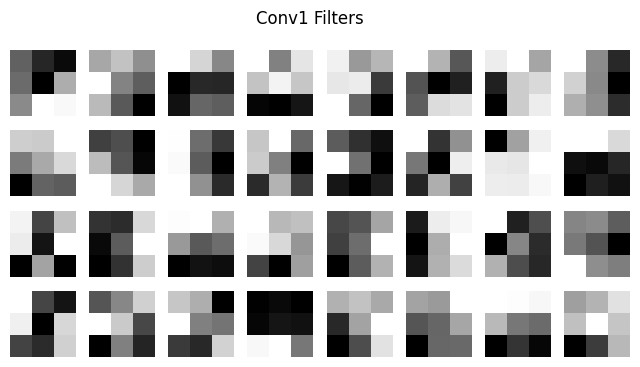

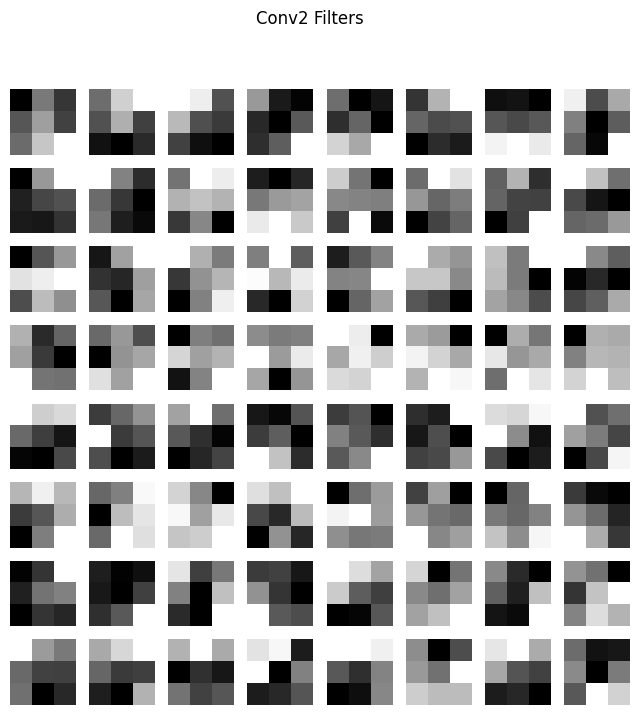

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
    InstanceNorm2d-2           [-1, 32, 26, 26]               0
            Conv2d-3           [-1, 64, 24, 24]          18,496
    InstanceNorm2d-4           [-1, 64, 24, 24]               0
           Dropout-5           [-1, 64, 12, 12]               0
            Linear-6                  [-1, 128]       1,179,776
           Dropout-7                  [-1, 128]               0
            Linear-8                   [-1, 10]           1,290
Total params: 1,199,882
Trainable params: 1,199,882
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.96
Params size (MB): 4.58
Estimated Total Size (MB): 5.55
----------------------------------------------------------------


In [ ]:
# Load and visualize InstanceNorm model filters
model = Net_InstanceNorm()
model.load_state_dict(torch.load("mnist_cnn_adam_instancenorm.pt"))
# visualize conv layers
show_filters(model.conv1.weight, "Conv1 Filters")
show_filters(model.conv2.weight, "Conv2 Filters")
# show_filters(model.fc1.weight.view(-1, 1, 16, 8), "FC1 Weights Reshaped")
# show_filters(model.fc2.weight.view(-1, 1, 16, 8), "FC2 Weights Reshaped")

import torchsummary
from torchsummary import summary
summary(model, (1, 28, 28))



 Conv Layer: conv1 | Shape: torch.Size([32, 1, 3, 3])


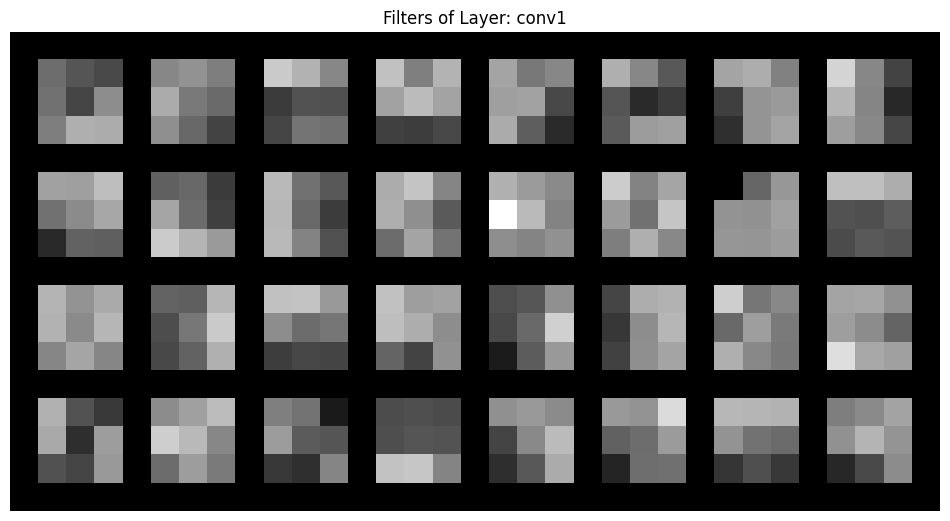


 Conv Layer: conv2 | Shape: torch.Size([64, 32, 3, 3])


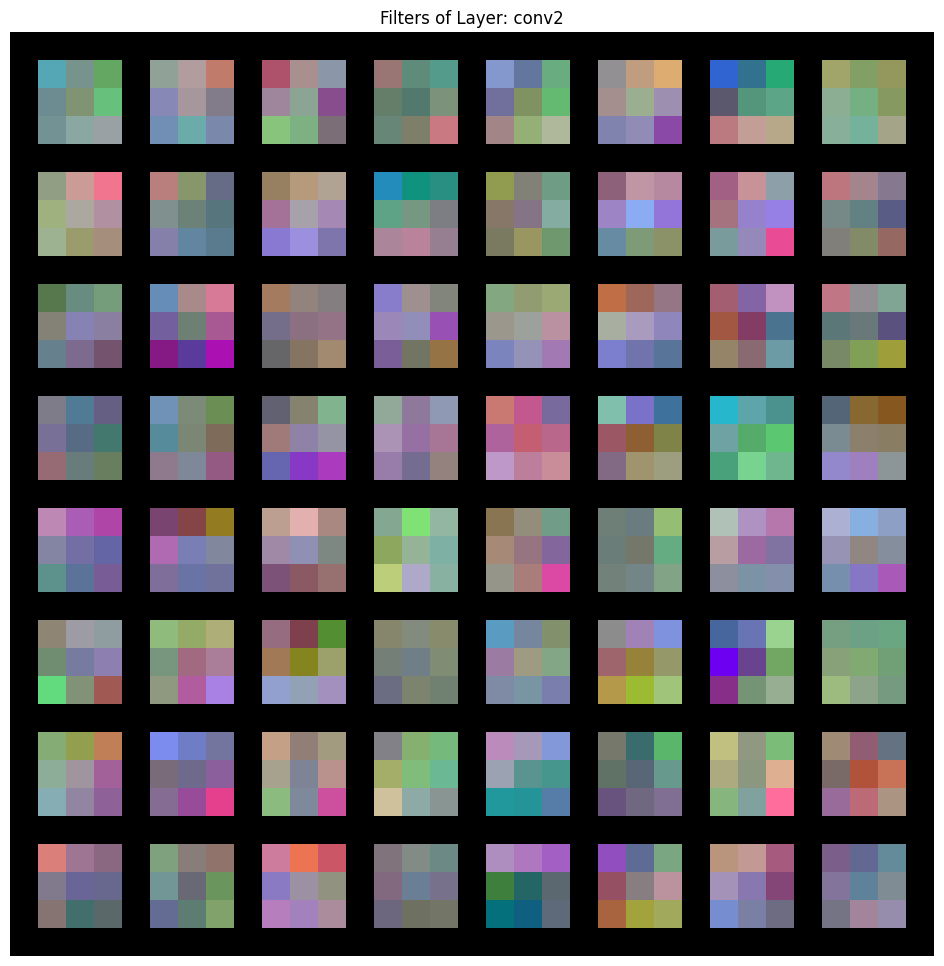

In [17]:
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        weights = module.weight.data
        print(f"\n Conv Layer: {name} | Shape: {weights.shape}")        
        # if 'features.0' in name or 'features.2' in name or 'features.5' in name:
        visualize_filters(weights, name)


In [14]:
from torchvision.models import resnet18
def train_resnet18(args, model, device, train_loader, optimizer, epoch):
    """
    Training loop for ResNet18 (uses cross_entropy loss for raw logits).
    """
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        # Use cross_entropy for raw logits (ResNet returns logits, not log-probs)
        loss = F.cross_entropy(output, target)
        loss.backward()
        # Clip gradients to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if args.dry_run:
                break


def test_resnet18(model, device, test_loader):
    """
    Test loop for ResNet18 (uses cross_entropy loss for raw logits).
    """
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))




In [3]:
def main_resnet18():
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=500, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=1, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform = transforms.Compose([
        transforms.Lambda(lambda img: img.convert("RGB")),  
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],
                            std=[0.229,0.224,0.225]),
    ])
    dataset1 = datasets.MNIST('../data', train=True, download=True,
                       transform=transform)
    dataset2 = datasets.MNIST('../data', train=False,
                       transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    model = resnet18(num_classes=10).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.1, betas=(0.9, 0.9))

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train_resnet18(args, model, device, train_loader, optimizer, epoch)
        test_resnet18(model, device, test_loader)
        scheduler.step()

    if args.save_model:
        torch.save(model.state_dict(), "mnist_cnn_resnet18.pt")



In [6]:
main_resnet18()

NameError: name 'resnet18' is not defined

In [13]:
from torchvision import models
import math

In [17]:
# 3 different weight initializations for comparison

def main_weights_comparison(temp_lr = 0.01):
    
    sys.argv = ['']

    # Training settings
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=5, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=temp_lr, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-accel', action='store_true',
                        help='disables accelerator')
    parser.add_argument('--dry-run', action='store_true',
                        help='quickly check a single pass')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--log-interval', type=int, default=10, metavar='N',
                        help='how many batches to wait before logging training status')
    parser.add_argument('--save-model', action='store_true', 
                        help='For Saving the current Model')
    args = parser.parse_args()
    args.save_model = True


    use_accel = not args.no_accel and torch.accelerator.is_available()

    torch.manual_seed(args.seed)

    if use_accel:
        device = torch.accelerator.current_accelerator()
    else:
        device = torch.device("cpu")

    train_kwargs = {'batch_size': args.batch_size}
    test_kwargs = {'batch_size': args.test_batch_size}
    if use_accel:
        accel_kwargs = {'num_workers': 1,
                        'persistent_workers': True,
                       'pin_memory': True,
                       'shuffle': True}
        train_kwargs.update(accel_kwargs)
        test_kwargs.update(accel_kwargs)

    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
        ])
    dataset1 = datasets.MNIST('../data', train=True, download=True, transform=transform)
    dataset2 = datasets.MNIST('../data', train=False, transform=transform)
    train_loader = torch.utils.data.DataLoader(dataset1,**train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)

    print("\n--- Training with Different Weight Initializations ---\n")

    print("\n--- 1. Weights Initialized with Default Random Weights ---\n")
    # weights initialized with default pretrained weights
    model_w1 = Net() # weights are randomly initialized by default 
    model_w1 = model_w1.to(device) 
    # store weights before training
    w1_conv1_weights_before = model_w1.conv1.weight.data.clone()
    w1_conv2_weights_before = model_w1.conv2.weight.data.clone()
    optimizer_w1 = optim.Adam(model_w1.parameters(), lr=args.lr, betas=(0.9, 0.999))
    scheduler_w1 = StepLR(optimizer_w1, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model_w1, device, train_loader, optimizer_w1, epoch)
        test(model_w1, device, test_loader)
        scheduler_w1.step()

    print("\n--- 2. Weights Initialized with Kaiming Initialization ---\n")
    # weights initialized with Kaiming initialization
    model_w2 = Net()
    for m in model_w2.modules():
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        elif isinstance(m, nn.Linear):
            nn.init.kaiming_uniform_(m.weight, a=math.sqrt(5))
    model_w2 = model_w2.to(device) 
    # store weights before training
    w2_conv1_weights_before = model_w2.conv1.weight.data.clone()
    w2_conv2_weights_before = model_w2.conv2.weight.data.clone()
    optimizer_w2 = optim.Adam(model_w2.parameters(), lr=args.lr, betas=(0.9, 0.999))
    scheduler_w2 = StepLR(optimizer_w2, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model_w2, device, train_loader, optimizer_w2, epoch)
        test(model_w2, device, test_loader)
        scheduler_w2.step()

    print("\n--- 3. Weights Initialized to Zero ---\n")
    # weights initialized to zero
    model_w3 = Net() 
    model_w3 = model_w3.to(device) 
    for param in model_w3.parameters():
        param.data.zero_() # initialize all weights to zero
    # store weights before training
    w3_conv1_weights_before = model_w3.conv1.weight.data.clone()
    w3_conv2_weights_before = model_w3.conv2.weight.data.clone()
    optimizer_w3 = optim.Adam(model_w3.parameters(), lr=args.lr, betas=(0.9, 0.999))
    scheduler_w3 = StepLR(optimizer_w3, step_size=1, gamma=args.gamma)
    for epoch in range(1, args.epochs + 1):
        train(args, model_w3, device, train_loader, optimizer_w3, epoch)
        test(model_w3, device, test_loader)
        scheduler_w3.step()

    # store weights after training
    w1_conv1_weights_after = model_w1.conv1.weight.data.clone()
    w1_conv2_weights_after = model_w1.conv2.weight.data.clone()
    w2_conv1_weights_after = model_w2.conv1.weight.data.clone()
    w2_conv2_weights_after = model_w2.conv2.weight.data.clone()
    w3_conv1_weights_after = model_w3.conv1.weight.data.clone()
    w3_conv2_weights_after = model_w3.conv2.weight.data.clone()

    # visualize weights before and after training for each model
    show_filters(w1_conv1_weights_before, "Model 1 Conv1 Filters Before Training (Default Random Weights)")
    show_filters(w1_conv1_weights_after, "Model 1 Conv1 Filters After Training (Default Random Weights)")
    show_filters(w1_conv2_weights_before, "Model 1 Conv2 Filters Before Training (Default Random Weights)")
    show_filters(w1_conv2_weights_after, "Model 1 Conv2 Filters After Training (Default Random Weights)")
    show_filters(w2_conv1_weights_before, "Model 2 Conv1 Filters Before Training (Kaiming Initialization)")
    show_filters(w2_conv1_weights_after, "Model 2 Conv1 Filters After Training (Kaiming Initialization)")
    show_filters(w2_conv2_weights_before, "Model 2 Conv2 Filters Before Training (Kaiming Initialization)")
    show_filters(w2_conv2_weights_after, "Model 2 Conv2 Filters After Training (Kaiming Initialization)")
    show_filters(w3_conv1_weights_before, "Model 3 Conv1 Filters Before Training (Zero Initialization)")
    show_filters(w3_conv1_weights_after, "Model 3 Conv1 Filters After Training (Zero Initialization)")
    show_filters(w3_conv2_weights_before, "Model 3 Conv2 Filters Before Training (Zero Initialization)")
    show_filters(w3_conv2_weights_after, "Model 3 Conv2 Filters After Training (Zero Initialization)")



--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.412709
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.300366
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.305380
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.309646
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.305781
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.299575
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.309937
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.298617
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.293137
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.293768
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.301614
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.317574
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.297805
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.287058
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.297905
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.304908
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.309280
Train Epoch

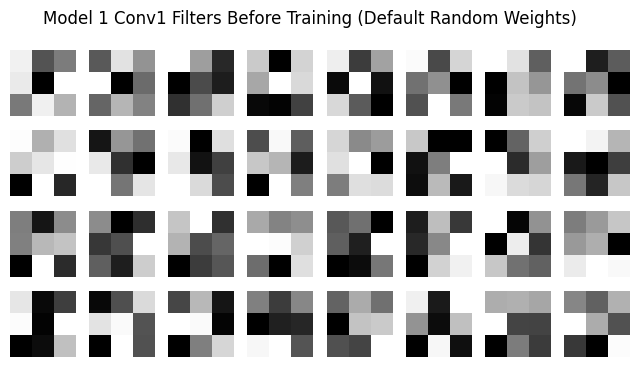

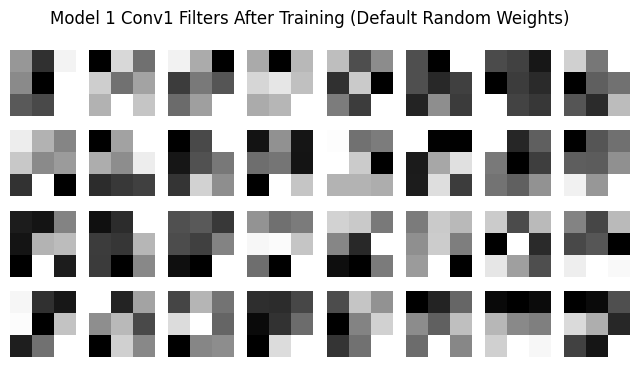

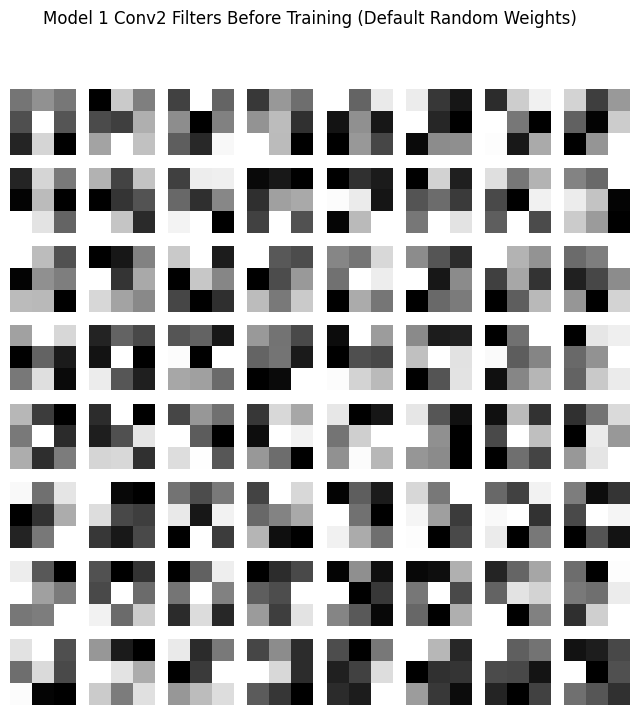

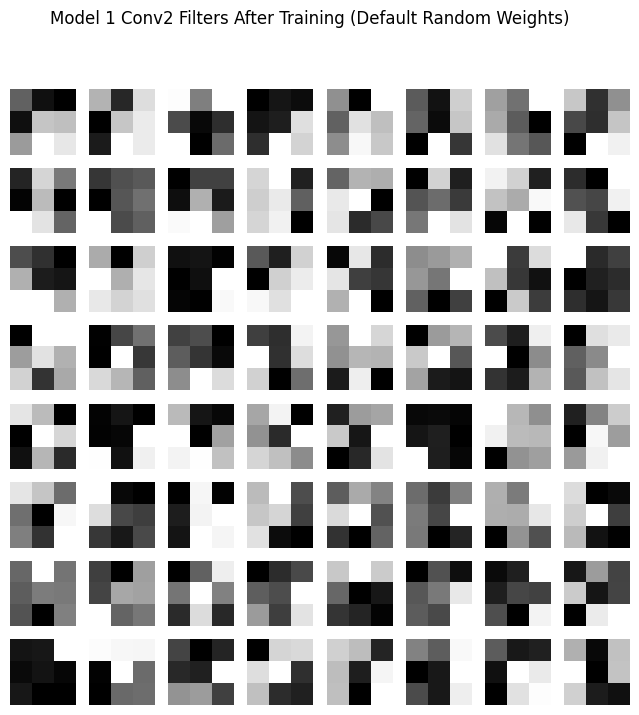

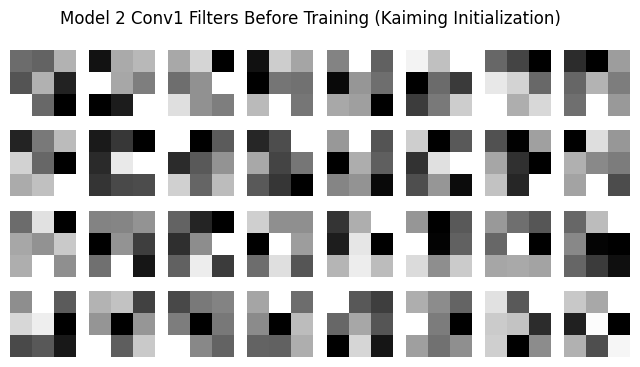

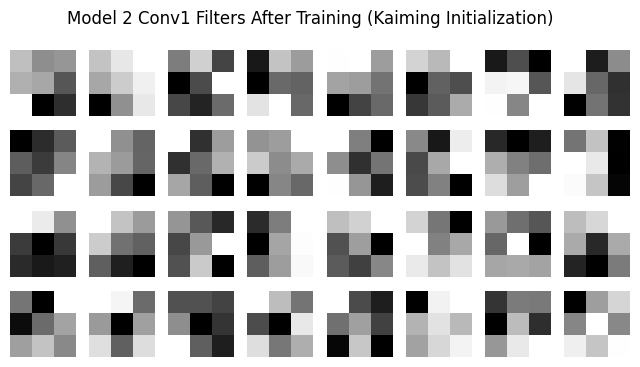

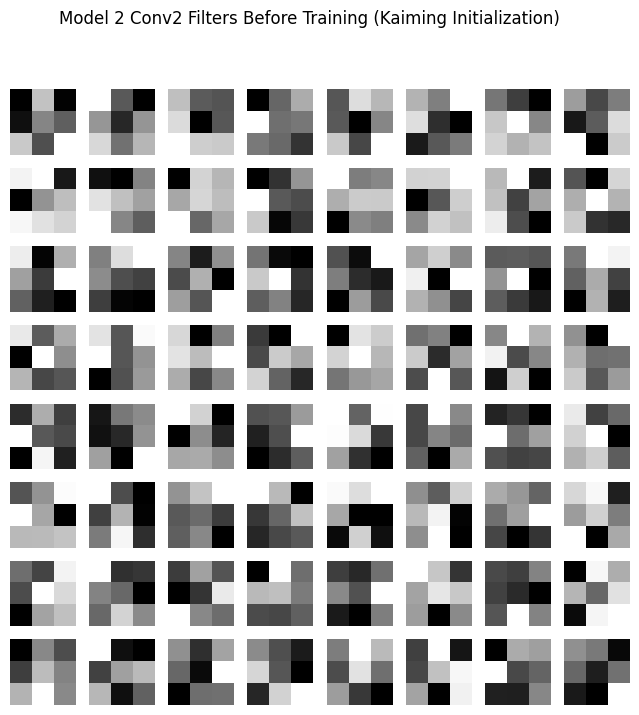

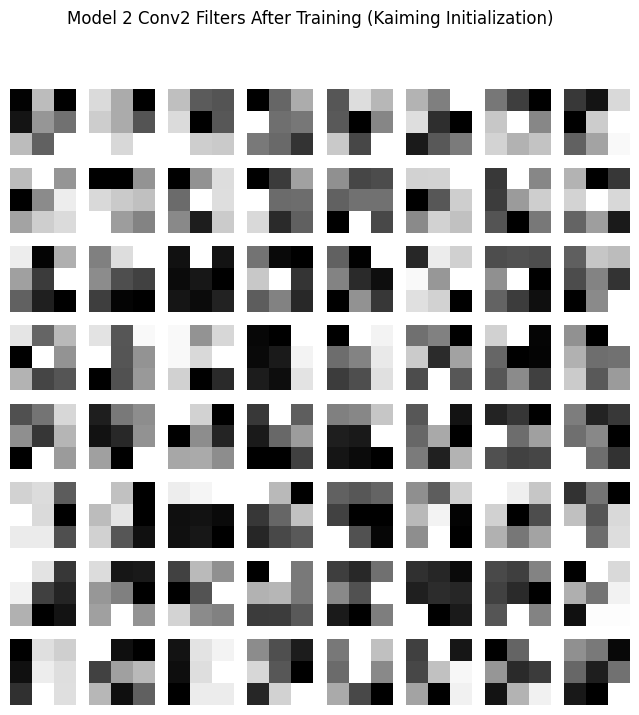

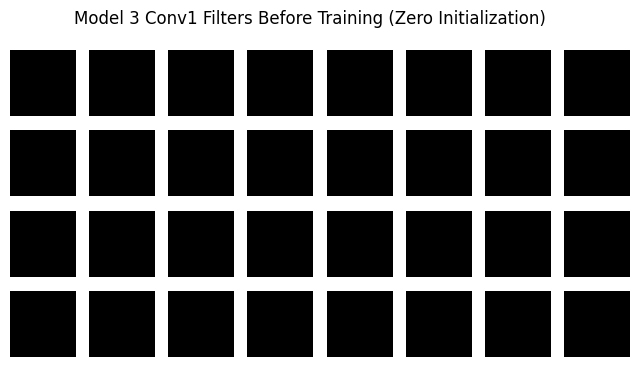

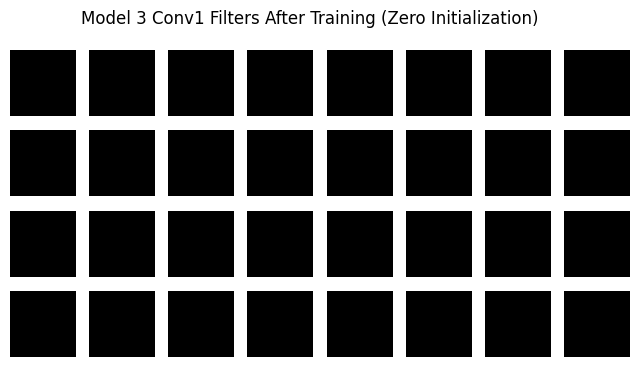

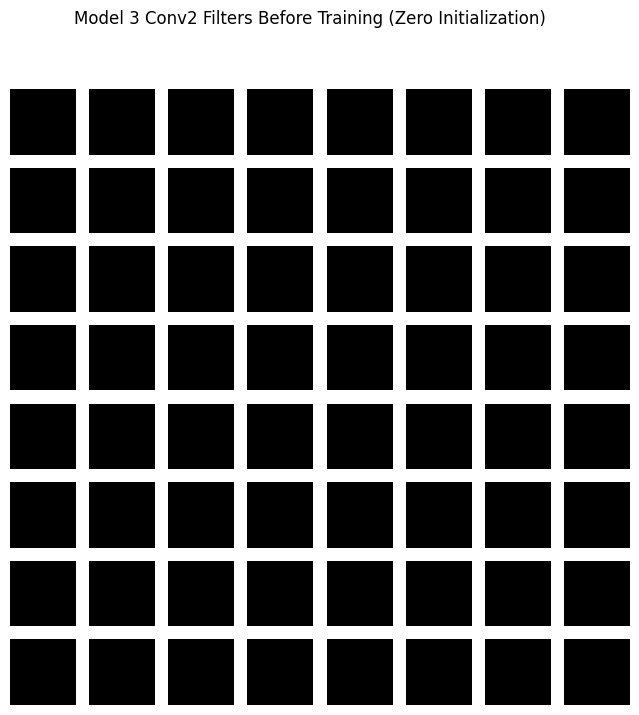

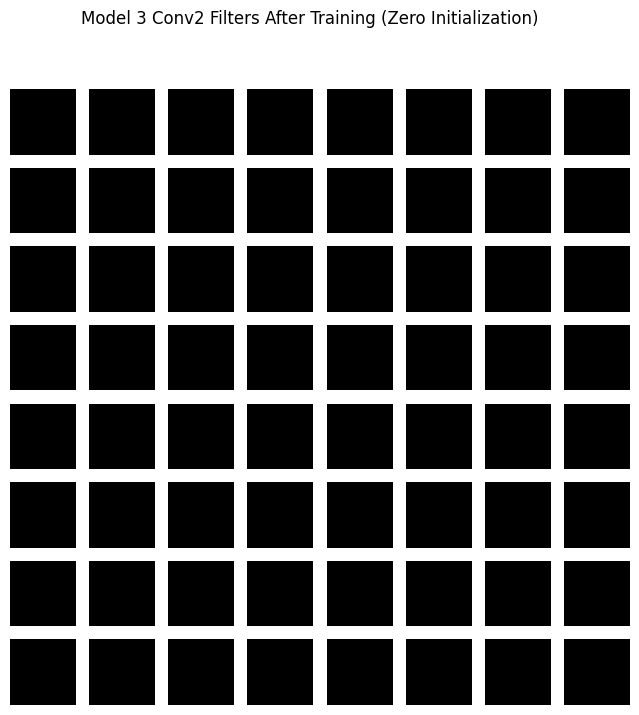

'\n\nNet() model AdaDelta optimizer with lr=1.0 for all 3 cases\n--- 1. Weights Initialized with Default Random Weights ---\nTest set: Average loss: 0.0277, Accuracy: 9915/10000 (99%)\n--- 2. Weights Initialized with Kaiming Initialization ---\nTest set: Average loss: 0.0328, Accuracy: 9896/10000 (99%)\n--- 3. Weights Initialized to Zero ---\nTest set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)\n\nNet_BatchNorm() model AdaDelta optimizer with lr=1.0 for all 3 cases\n--- 1. Weights Initialized with Default Random Weights ---\nTest set: Average loss: 0.0379, Accuracy: 9877/10000 (99%)\n--- 2. Weights Initialized with Kaiming Initialization ---\nTest set: Average loss: 0.0377, Accuracy: 9872/10000 (99%)\n--- 3. Weights Initialized to Zero ---\nTest set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)\n\nNet() model Adam optimizer with lr=0.01 for all 3 cases\n--- 1. Weights Initialized with Default Random Weights ---\nTest set: Average loss: 0.0862, Accuracy: 9734/10000 (97%)\n--- 

In [ ]:
main_weights_comparison(0.1)

'''

Net() model AdaDelta optimizer with lr=1.0 for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 0.0277, Accuracy: 9915/10000 (99%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 0.0328, Accuracy: 9896/10000 (99%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)

Net_BatchNorm() model AdaDelta optimizer with lr=1.0 for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 0.0379, Accuracy: 9877/10000 (99%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 0.0377, Accuracy: 9872/10000 (99%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3011, Accuracy: 1135/10000 (11%)

Net() model Adam optimizer with lr=0.01, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 0.0862, Accuracy: 9734/10000 (97%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 0.0450, Accuracy: 9862/10000 (99%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3013, Accuracy: 1028/10000 (10%)

gonna try adam 0.1 0.2 ... 0.9
then 0.01 to 0.09?

Net() model Adam optimizer with lr=0.1, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3015, Accuracy: 1135/10000 (11%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3015, Accuracy: 1135/10000 (11%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3015, Accuracy: 1135/10000 (11%)

Net() model Adam optimizer with lr=0.2, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3027, Accuracy: 958/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3027, Accuracy: 958/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3027, Accuracy: 958/10000 (10%)

Net() model Adam optimizer with lr=0.3, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3039, Accuracy: 958/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3039, Accuracy: 958/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3039, Accuracy: 958/10000 (10%)

Net() model Adam optimizer with lr=0.4, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3041, Accuracy: 1028/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3041, Accuracy: 1028/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3041, Accuracy: 1028/10000 (10%)

Net() model Adam optimizer with lr=0.5, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3045, Accuracy: 1028/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3045, Accuracy: 1028/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3045, Accuracy: 1028/10000 (10%)

Net() model Adam optimizer with lr=0.6, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3052, Accuracy: 1032/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3052, Accuracy: 1032/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3052, Accuracy: 1032/10000 (10%)

Net() model Adam optimizer with lr=0.7, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3060, Accuracy: 1032/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3060, Accuracy: 1032/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3060, Accuracy: 1032/10000 (10%)

Net() model Adam optimizer with lr=0.8, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3067, Accuracy: 1032/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3067, Accuracy: 1032/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3067, Accuracy: 1032/10000 (10%)

Net() model Adam optimizer with lr=0.9, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3069, Accuracy: 1032/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3069, Accuracy: 1032/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3068, Accuracy: 1032/10000 (10%)

Net() model Adam optimizer with lr=0.01, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 0.0862, Accuracy: 9734/10000 (97%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 0.0450, Accuracy: 9862/10000 (99%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3013, Accuracy: 1028/10000 (10%)

Net() model Adam optimizer with lr=0.02, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 0.1801, Accuracy: 9420/10000 (94%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)

Net() model Adam optimizer with lr=0.03, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3016, Accuracy: 1028/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3016, Accuracy: 1028/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3016, Accuracy: 1028/10000 (10%)

Net() model Adam optimizer with lr=0.04, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---
Test set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)
--- 2. Weights Initialized with Kaiming Initialization ---
Test set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)
--- 3. Weights Initialized to Zero ---
Test set: Average loss: 2.3015, Accuracy: 1028/10000 (10%)

Net() model Adam optimizer with lr=0.05, betas=(0.9,0.999) for all 3 cases
--- 1. Weights Initialized with Default Random Weights ---




'''


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.326034
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.302839
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.305845
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.301451
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.526966
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.322111
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.308257
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.296233
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.298060
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.305224
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.320257
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.309359
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.301107
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.308151
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.313570
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.315380
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.300815
Train Epoch

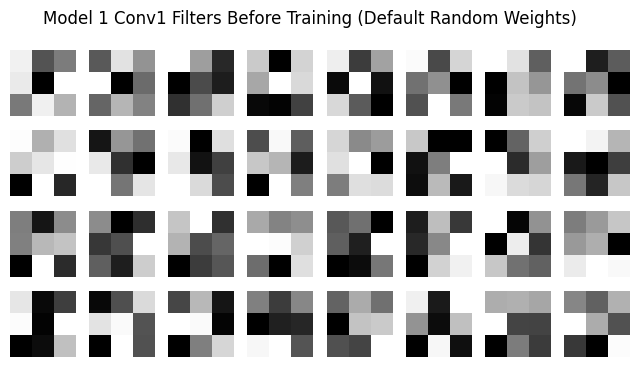

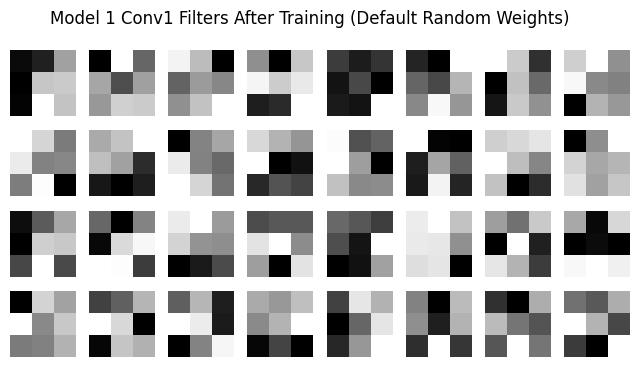

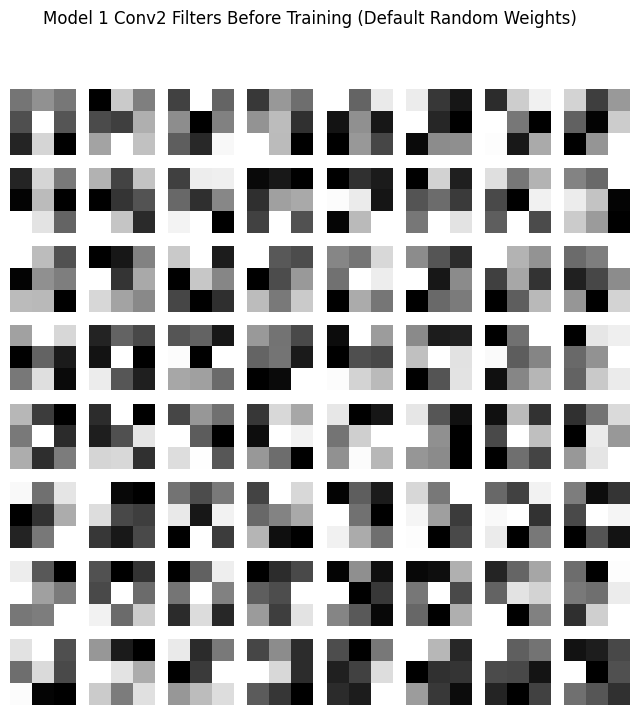

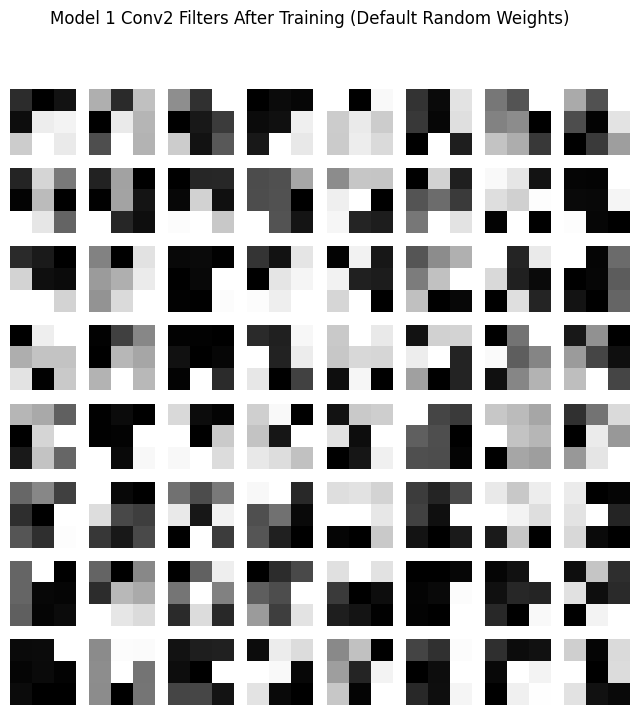

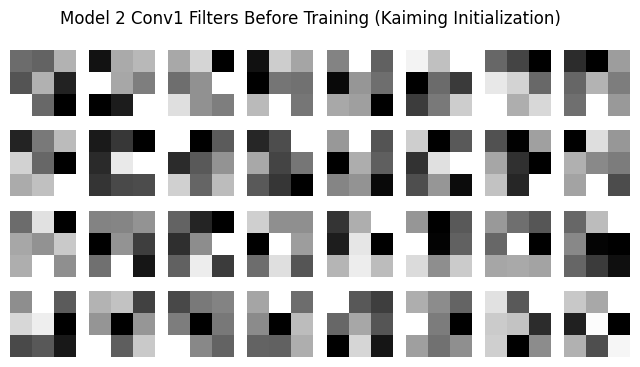

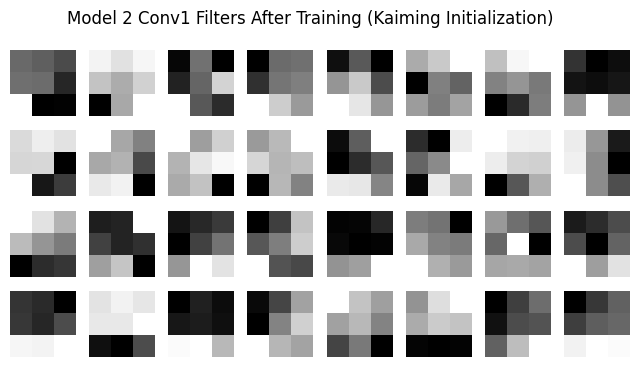

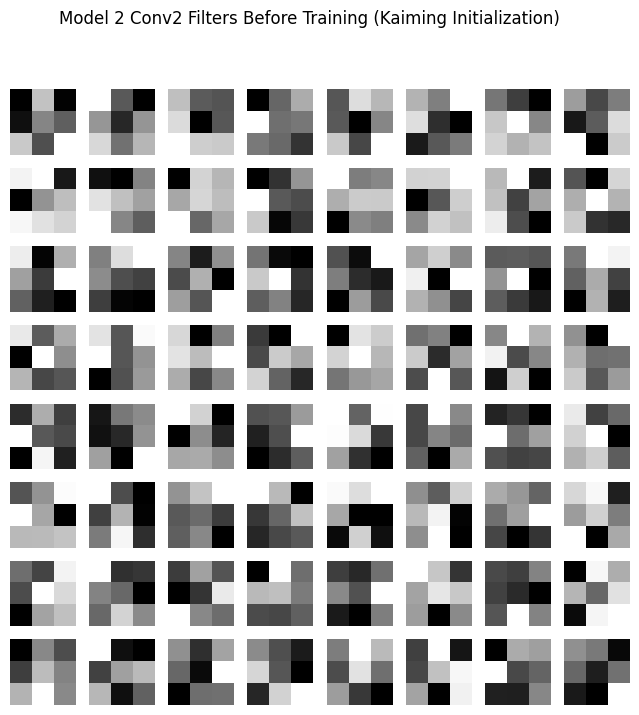

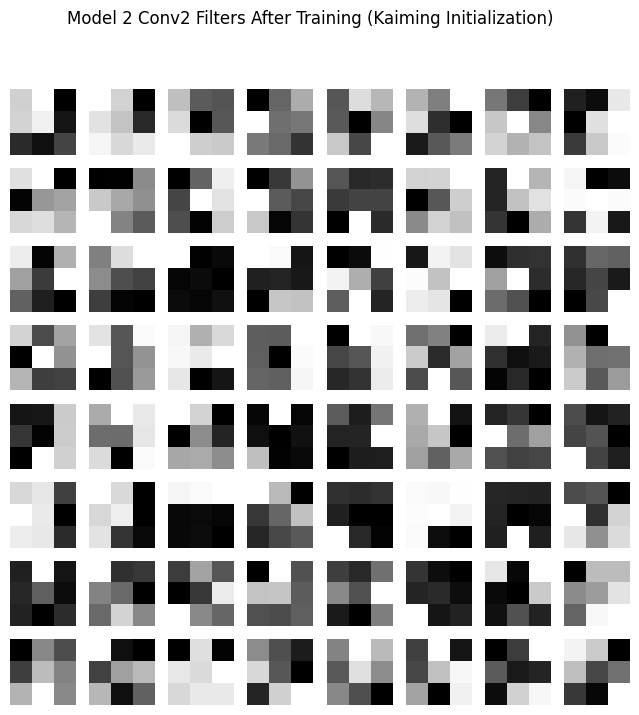

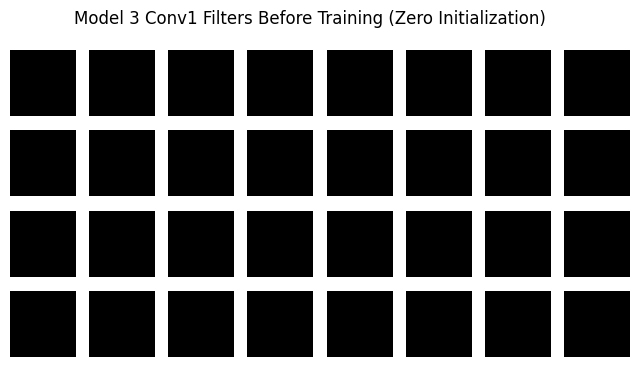

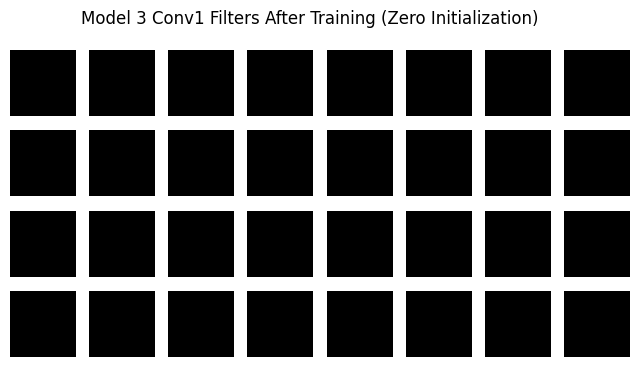

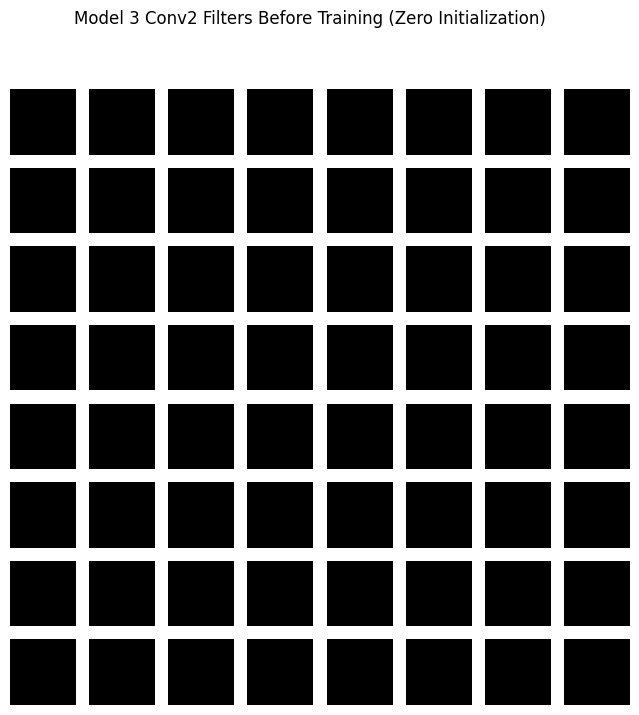

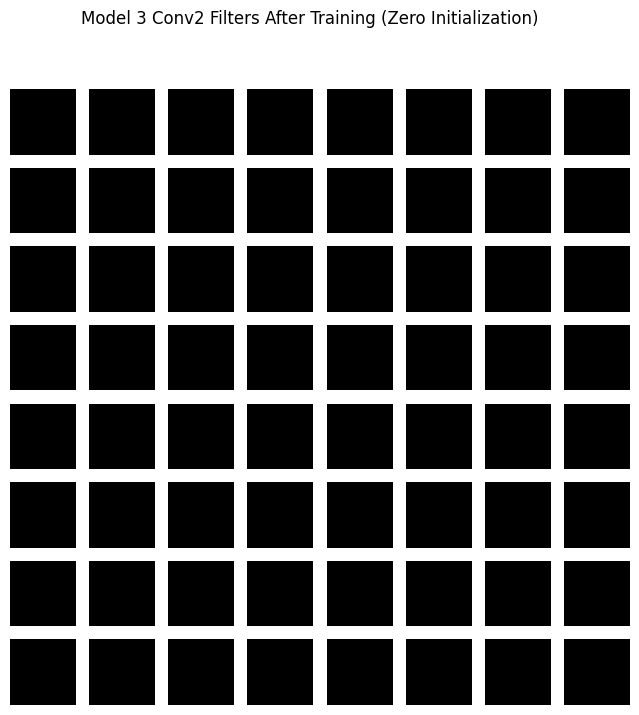

In [19]:
main_weights_comparison(0.2)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.367175
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.352122
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.321817
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.408524
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.312890
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.344786
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.312941
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.293536
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.305293
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.312791
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.338425
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.313699
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.291668
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.311494
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.314909
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.339179
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.296475
Train Epoch

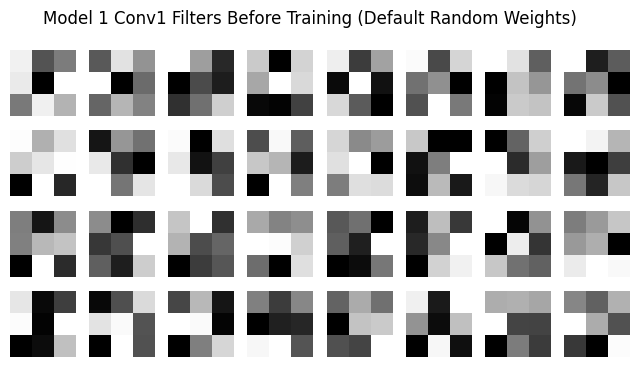

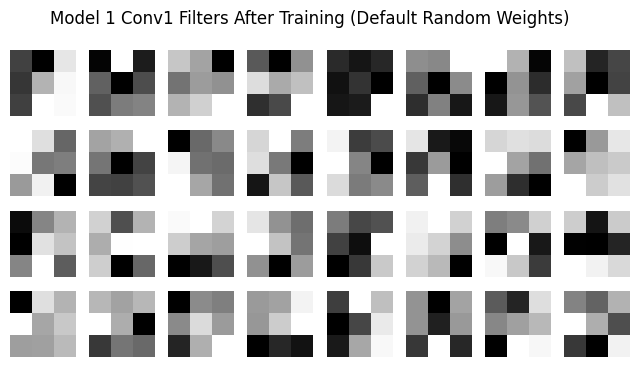

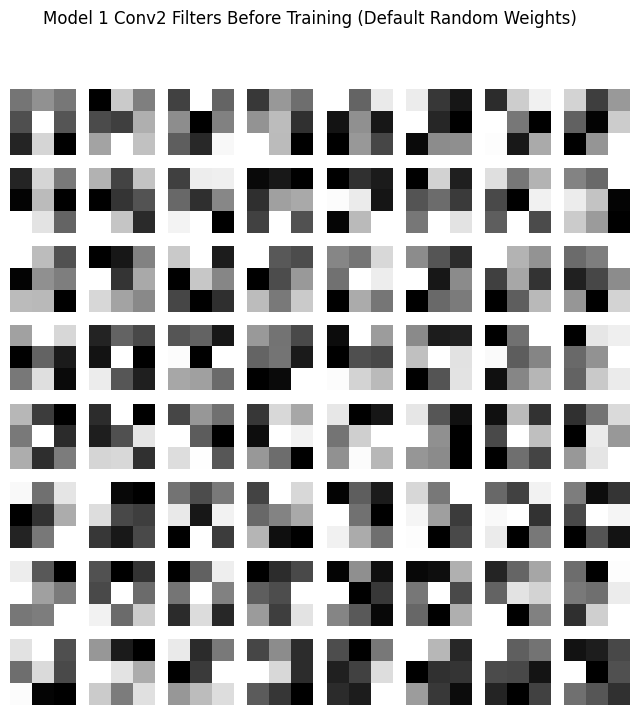

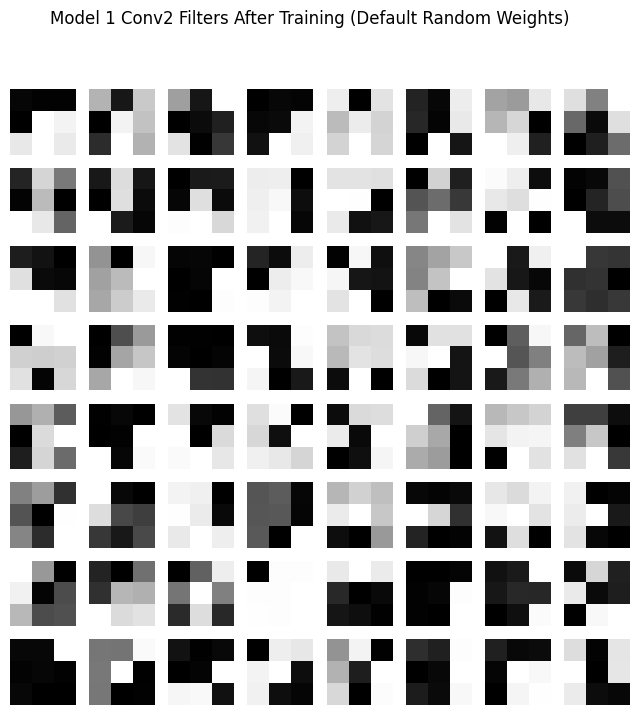

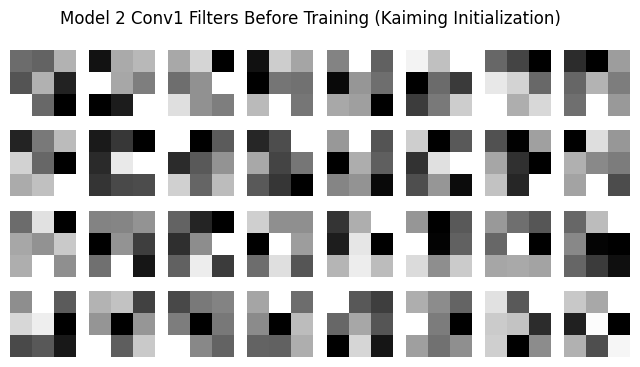

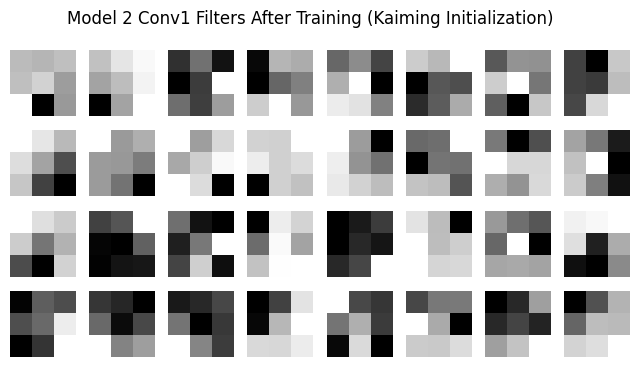

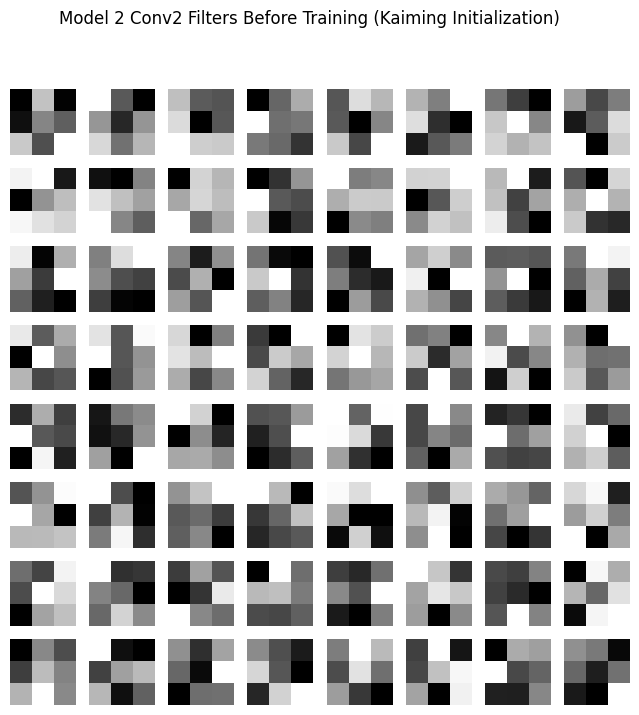

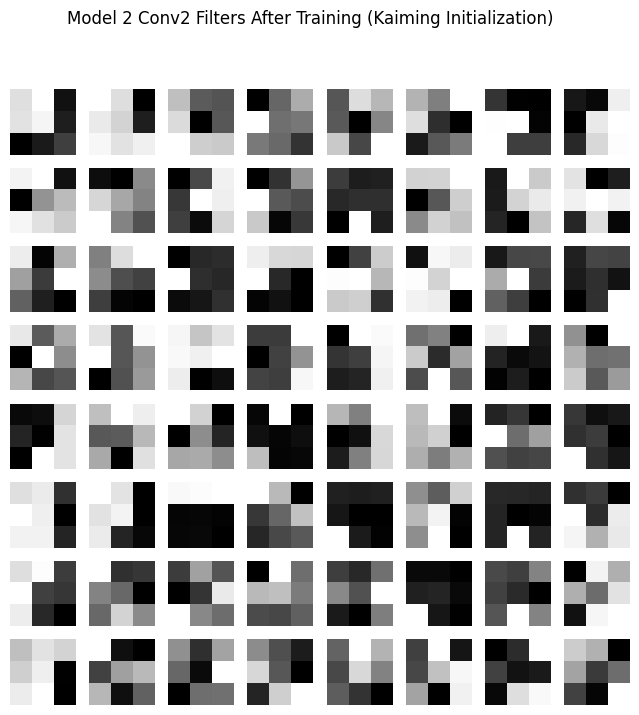

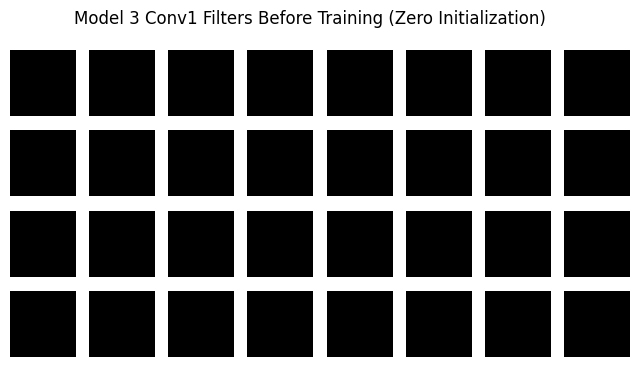

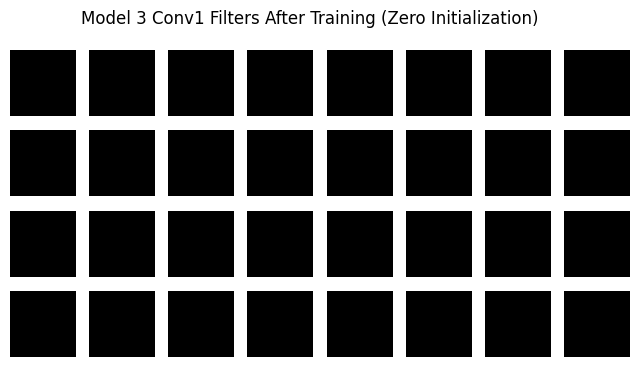

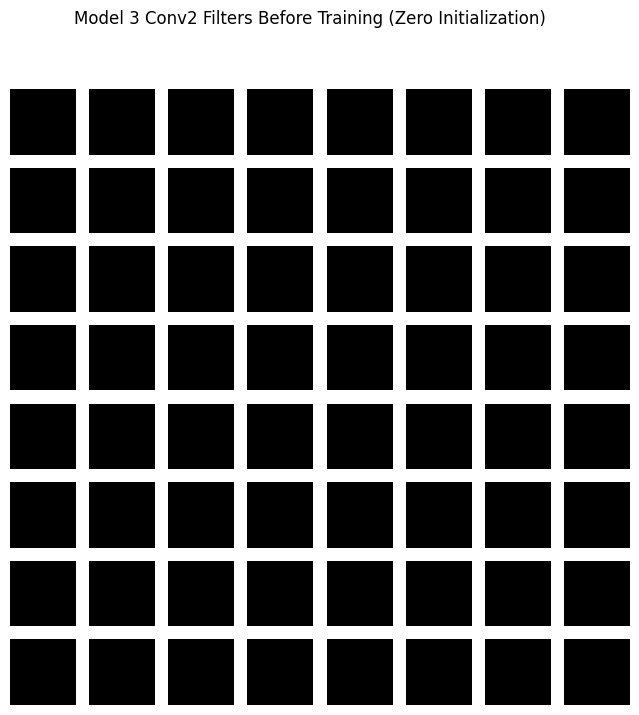

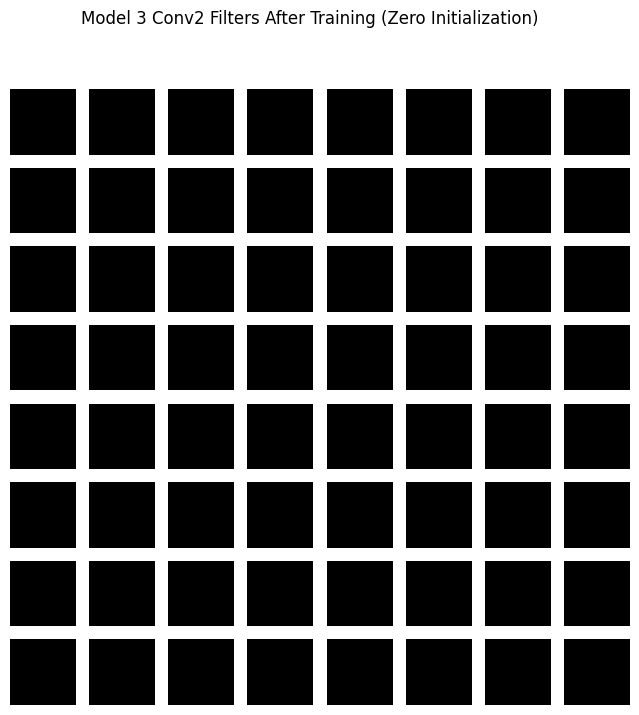

In [20]:
main_weights_comparison(0.3)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.525205
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.416230
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.341608
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.320912
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.326439
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.336933
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.323592
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.297228
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.314888
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.316308
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.349142
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.328079
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.289555
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.304405
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.317632
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.356761
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.297664
Train Epoch

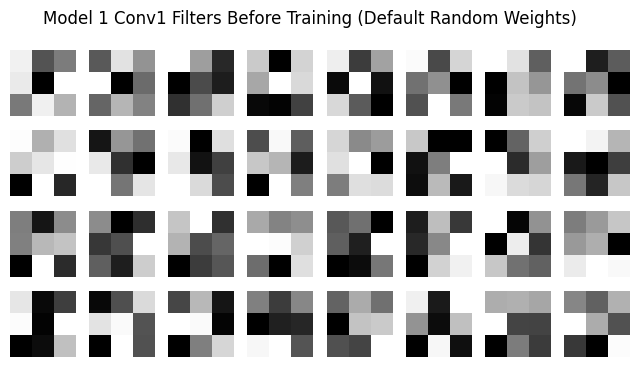

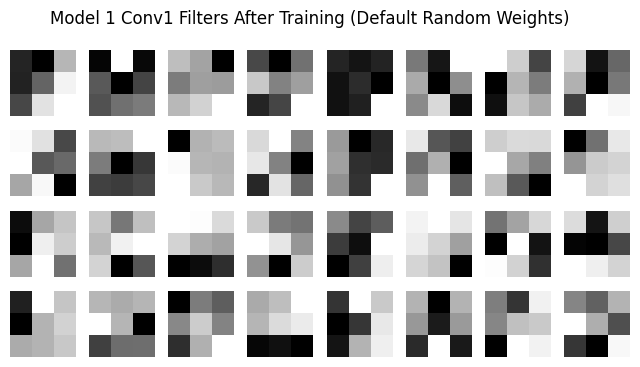

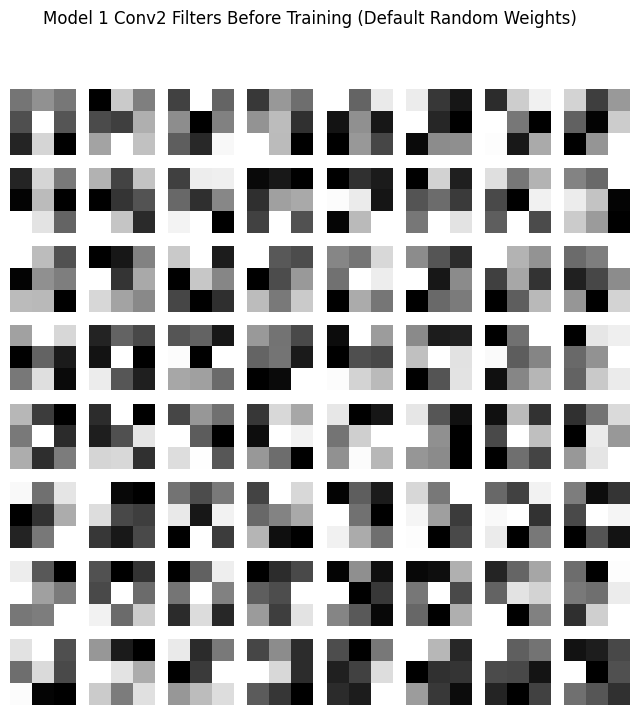

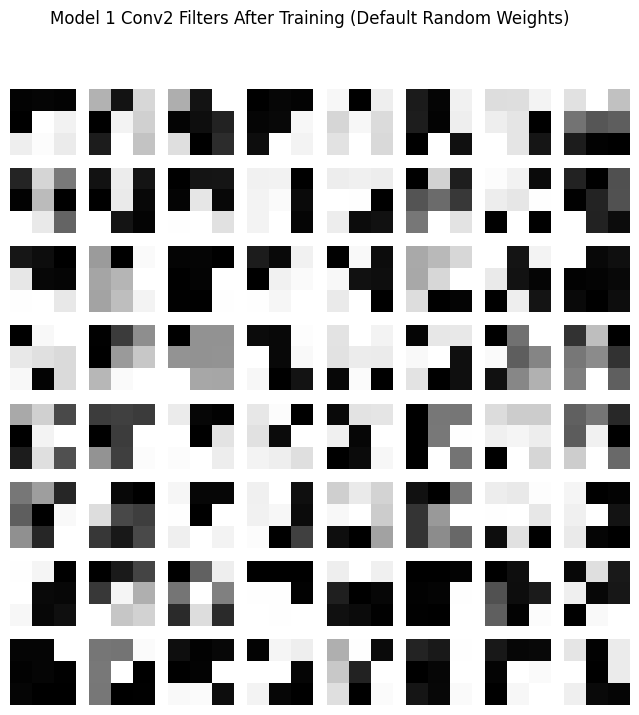

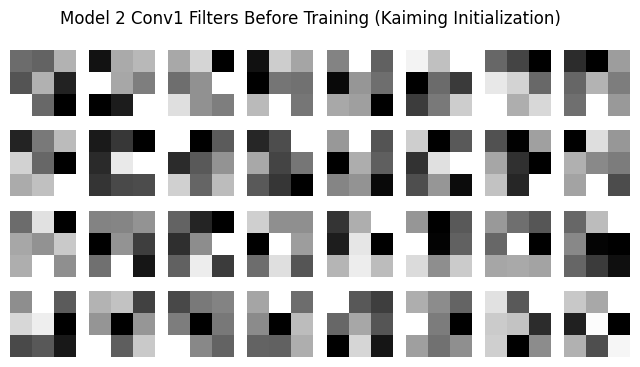

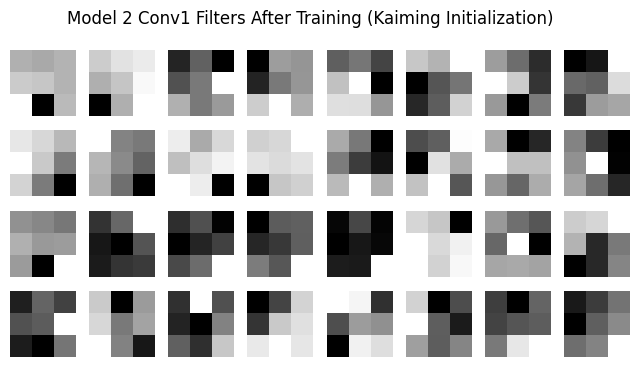

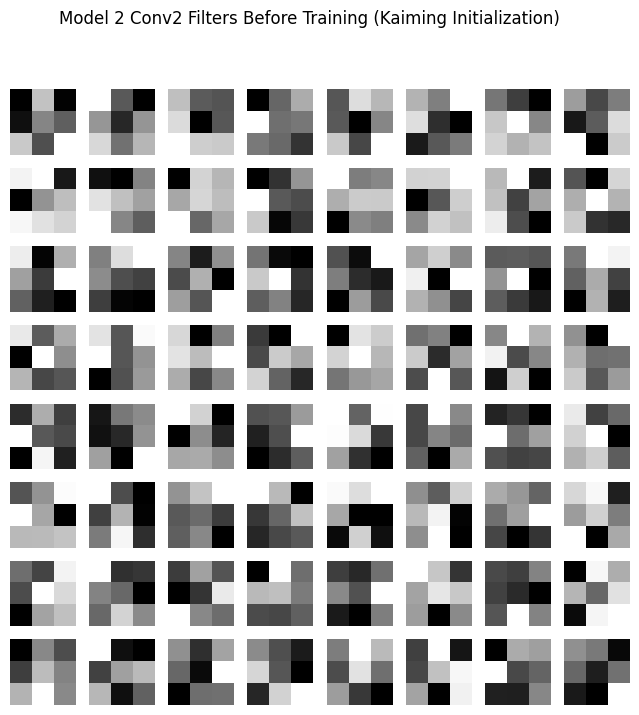

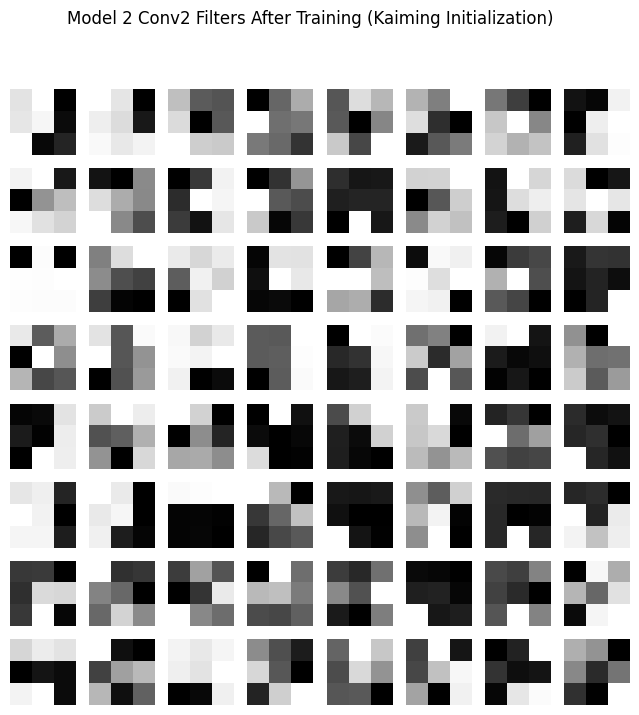

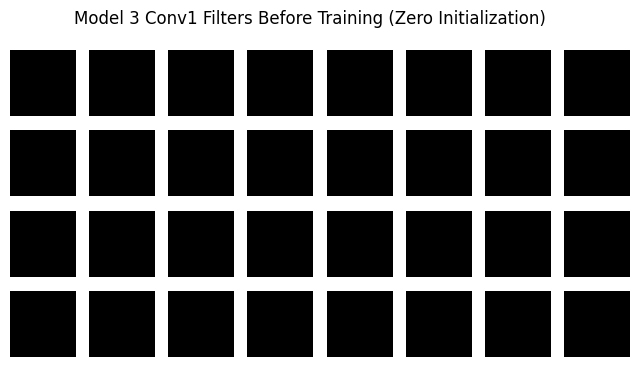

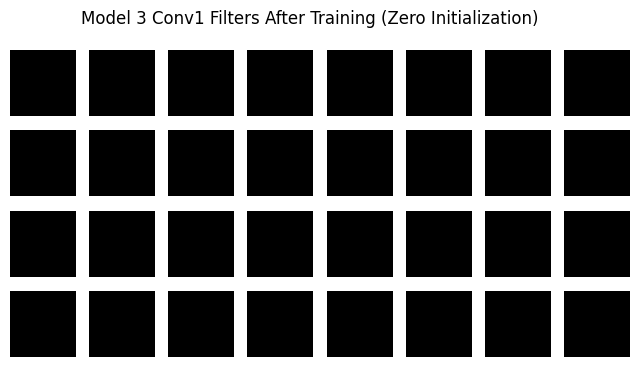

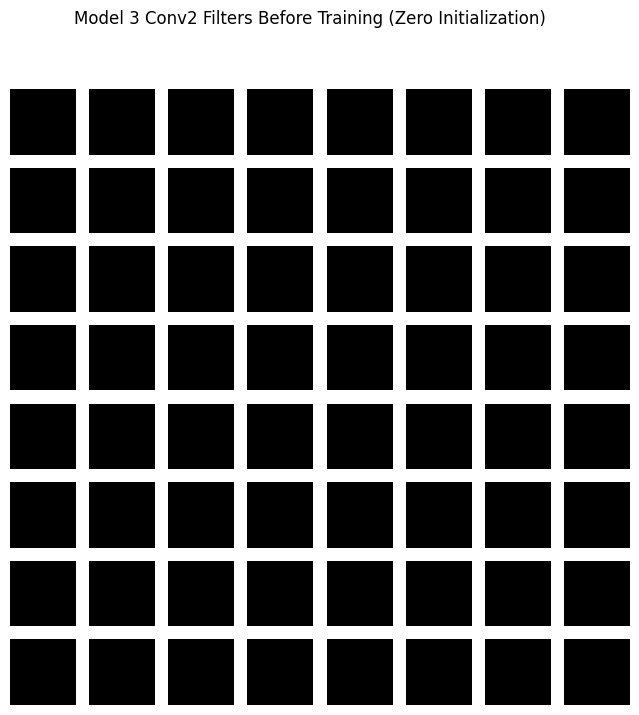

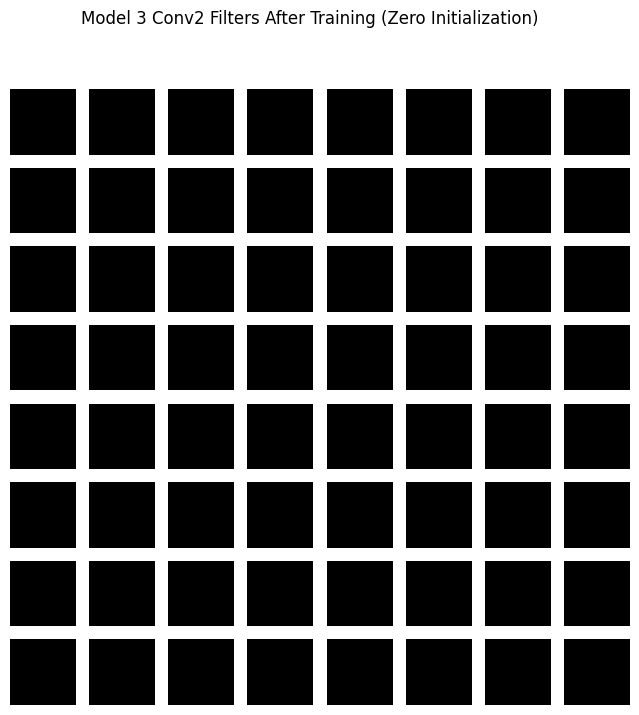

In [21]:
main_weights_comparison(0.4)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 3.240395
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.465664
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.370086
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.324437
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.331140
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.328863
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.302231
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.301368
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.327961
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.327013
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.334121
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.330577
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.291569
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.304494
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.323643
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.359288
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.292984
Train Epoch

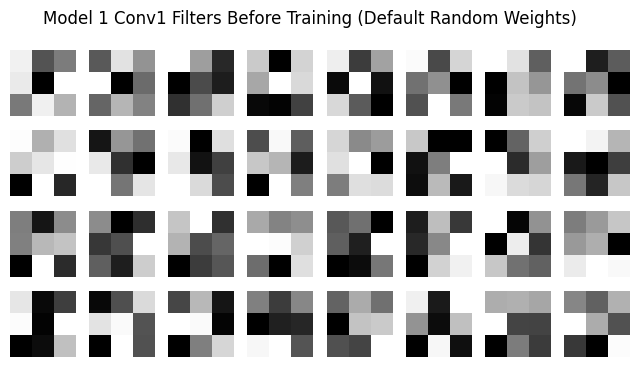

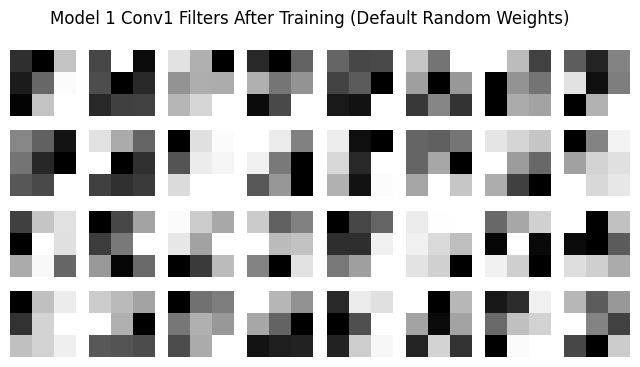

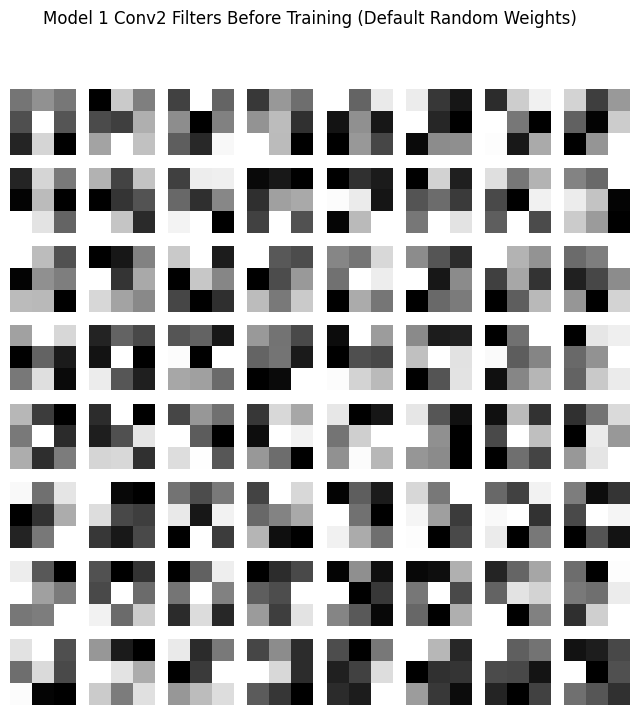

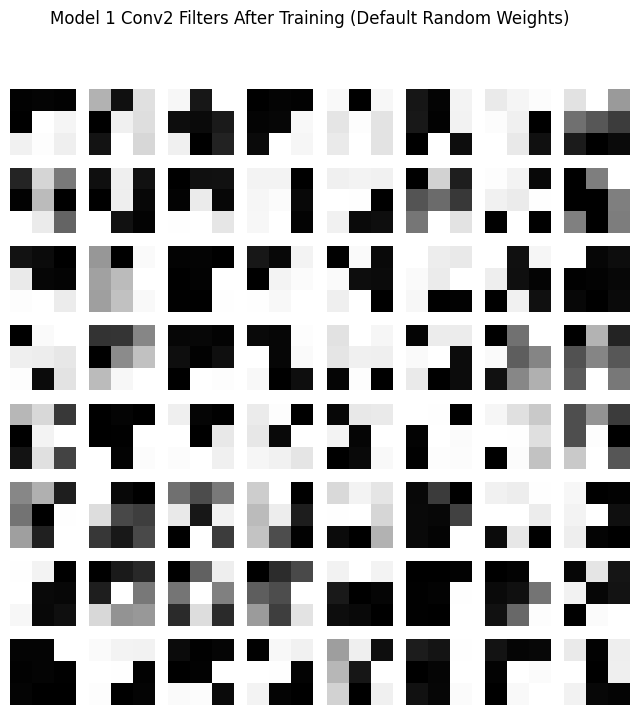

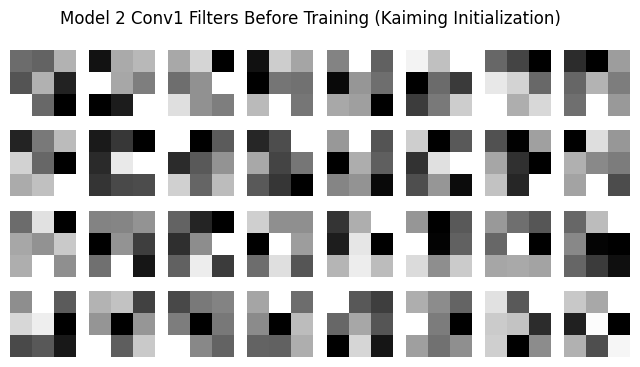

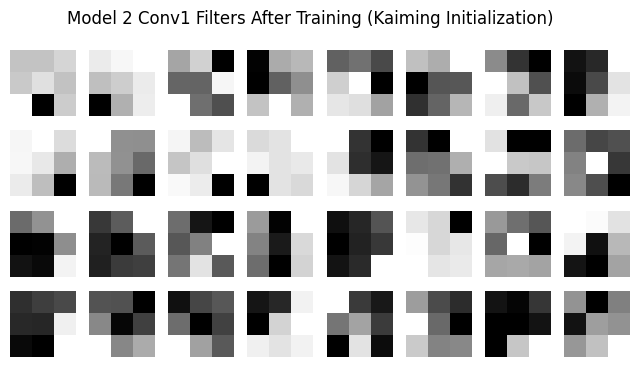

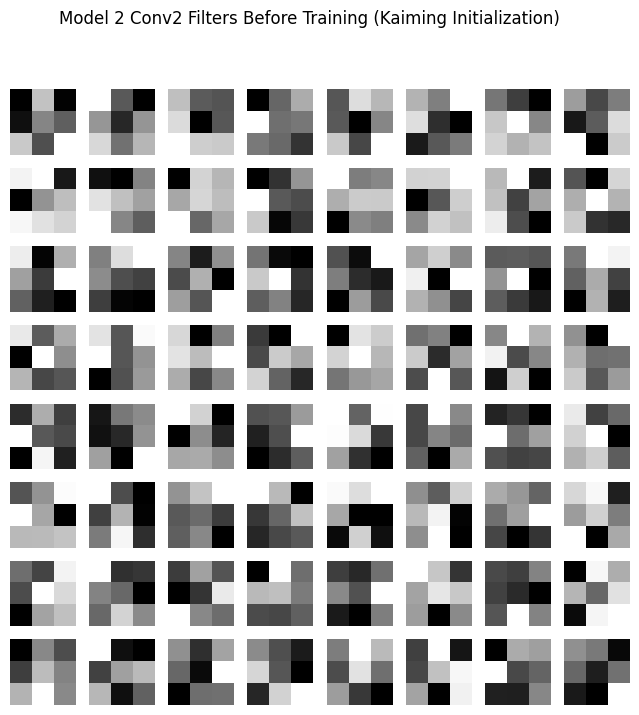

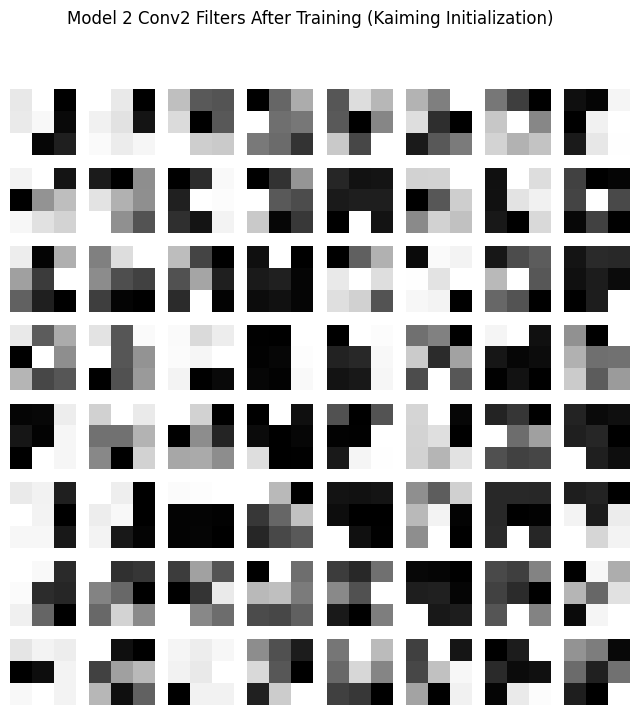

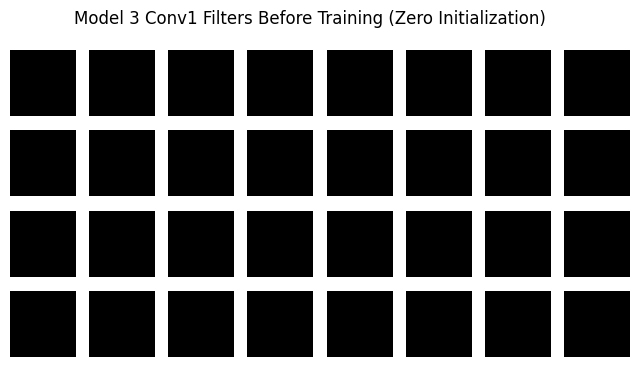

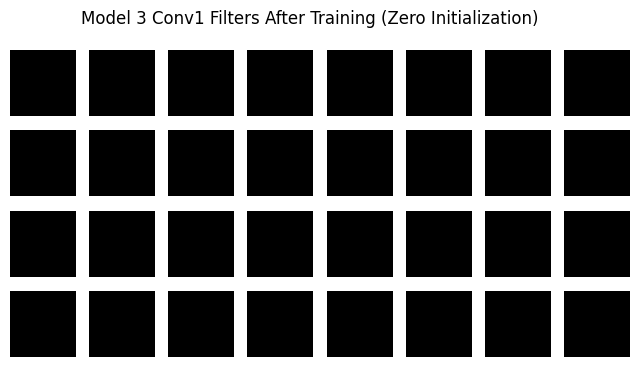

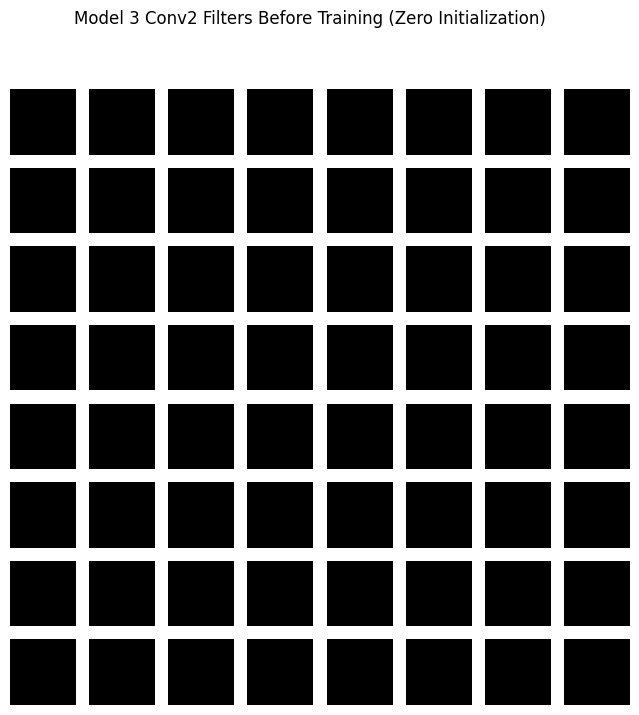

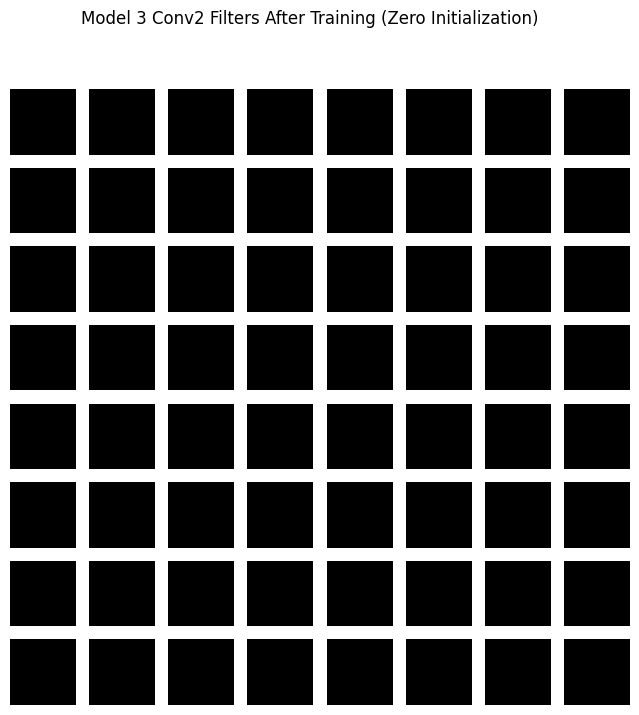

In [22]:
main_weights_comparison(0.5)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 3.833790
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.831666
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.396484
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.370799
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.330853
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.322822
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.338563
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.308380
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.324445
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.329525
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.351453
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.344265
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.299235
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.337607
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.368115
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.371627
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.298902
Train Epoch

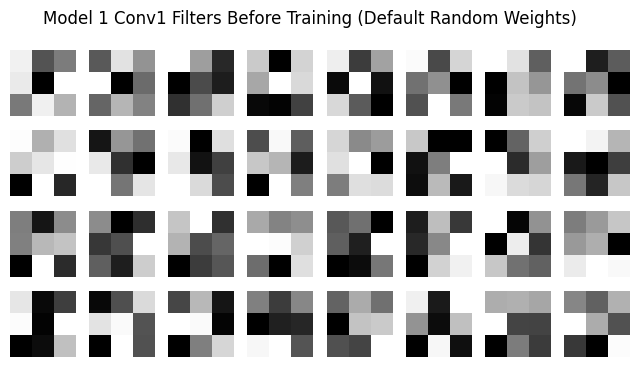

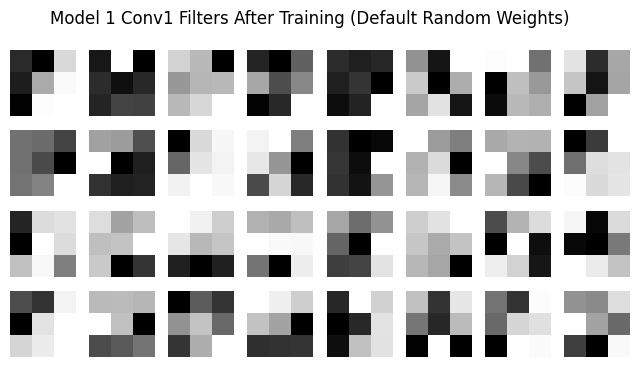

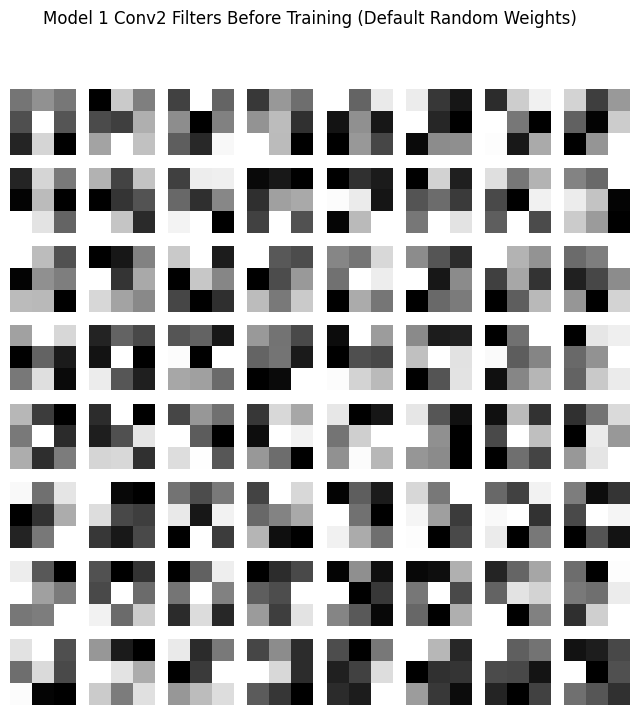

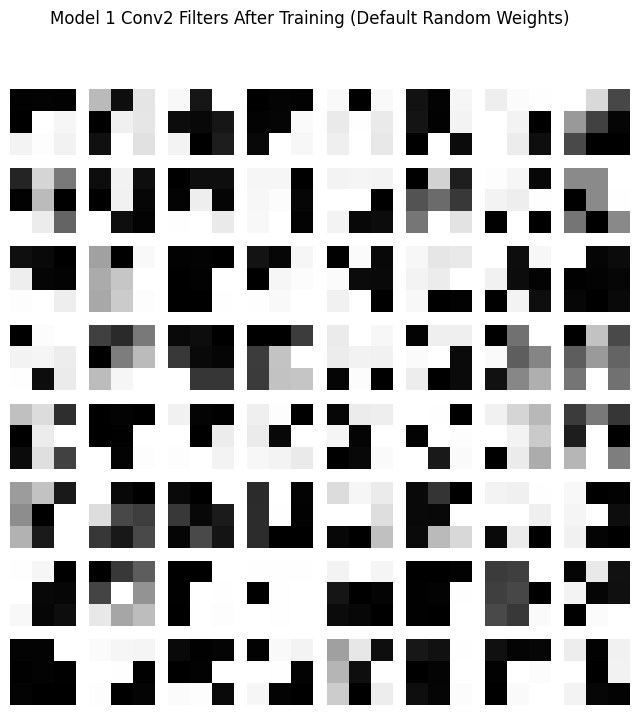

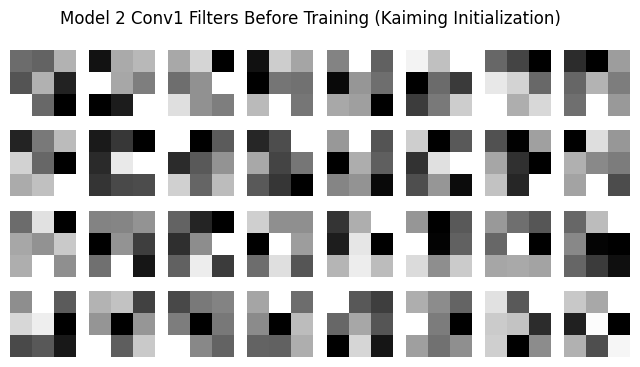

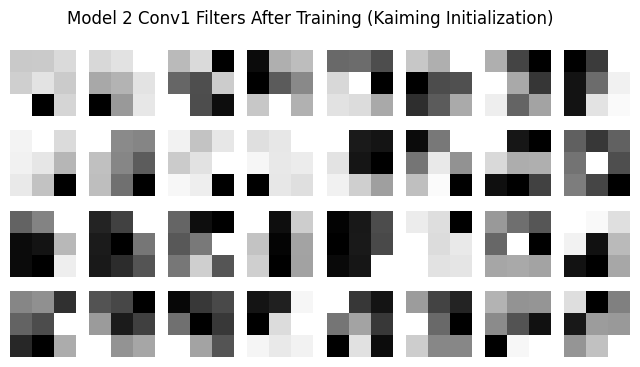

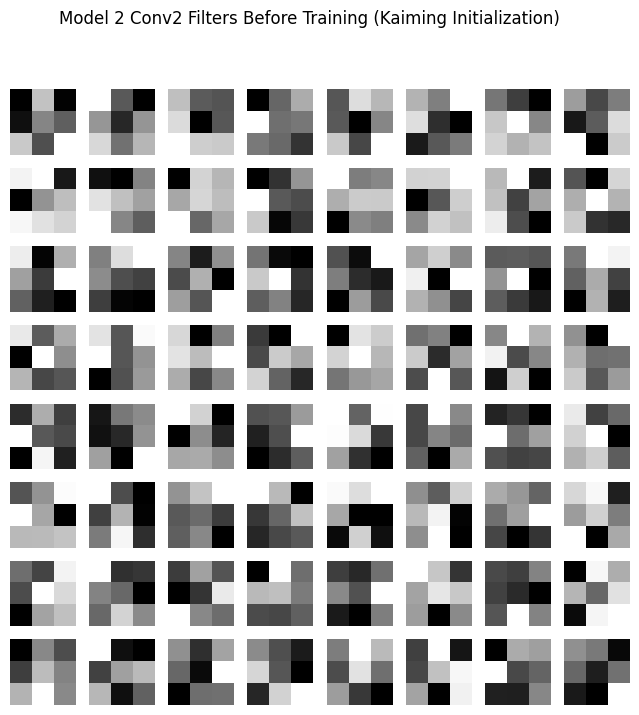

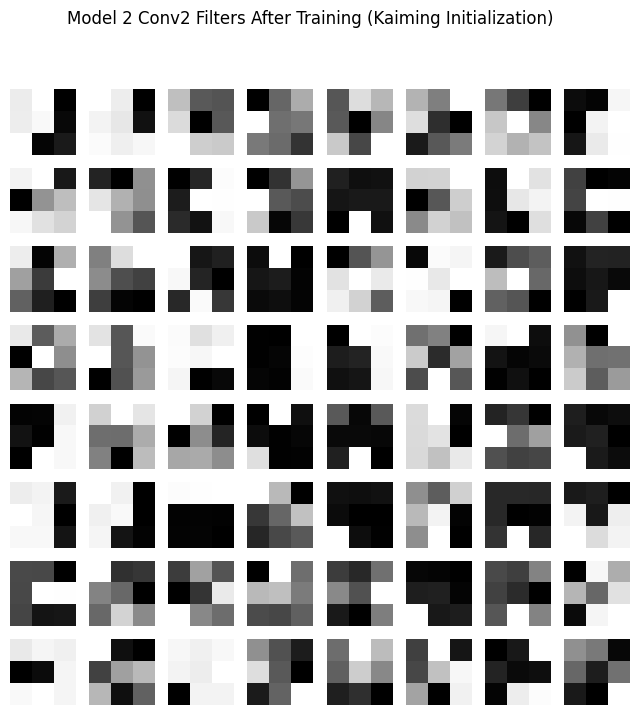

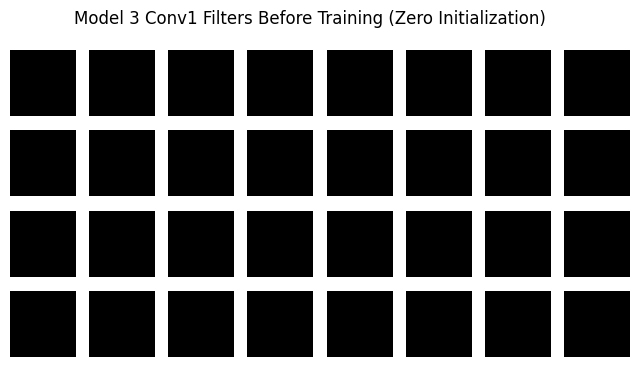

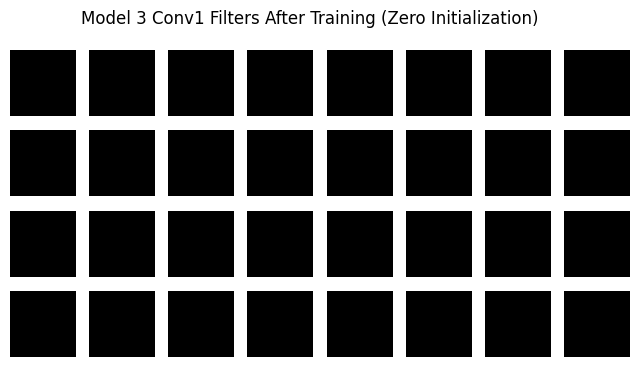

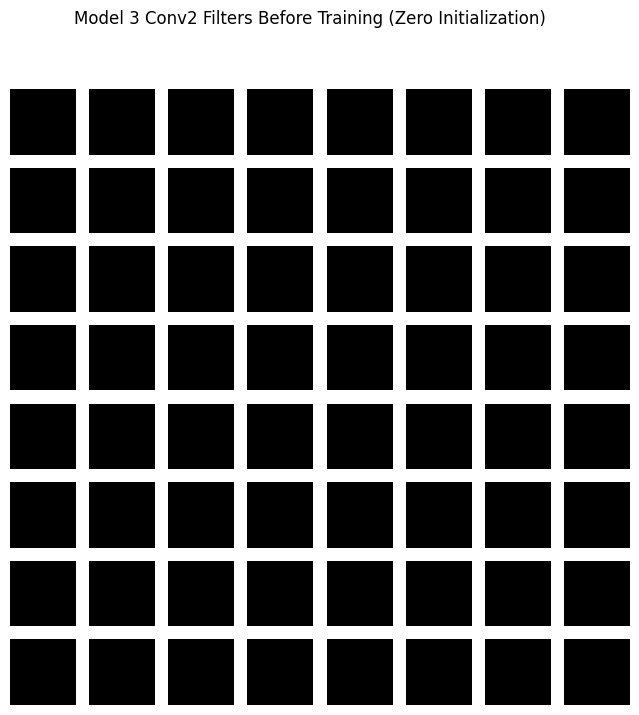

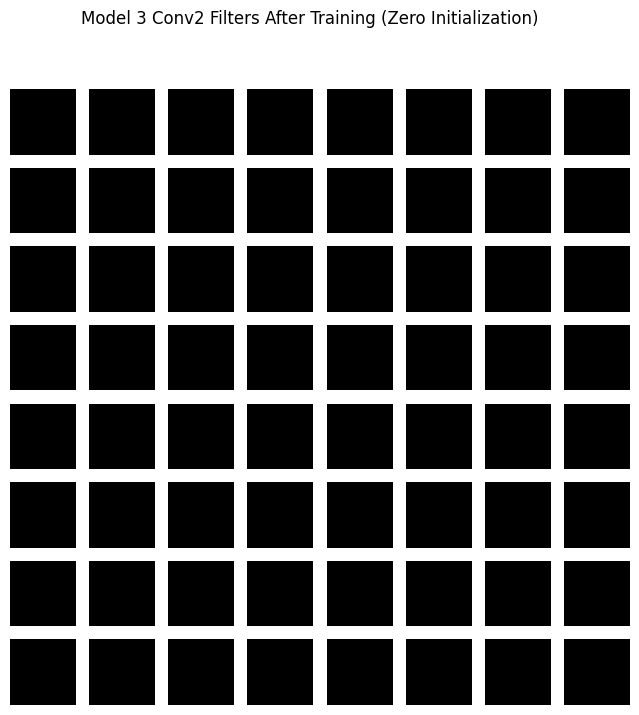

In [23]:
main_weights_comparison(0.6)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 3.676943
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.533819
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.374608
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.372388
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.314671
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.328843
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.329440
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.310973
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.324254
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.355945
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.340032
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.340219
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.313689
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.357375
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.395319
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.350185
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.299708
Train Epoch

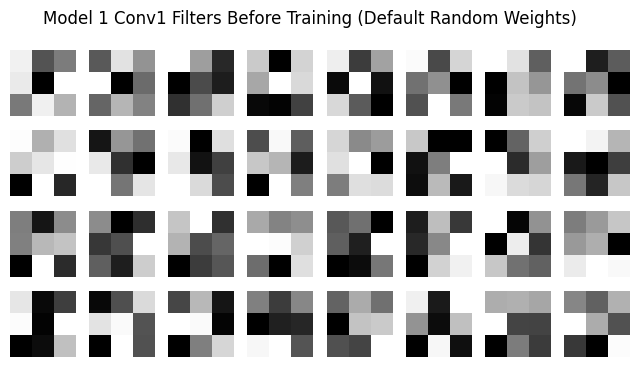

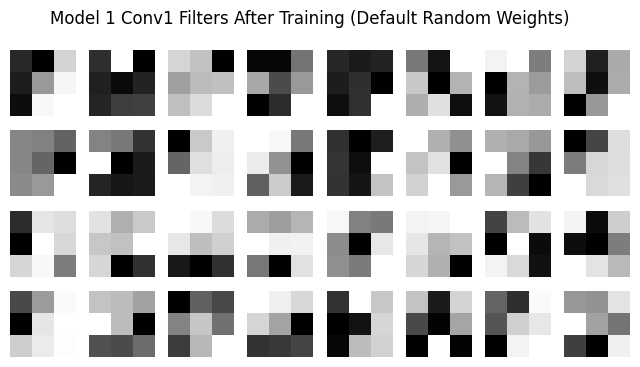

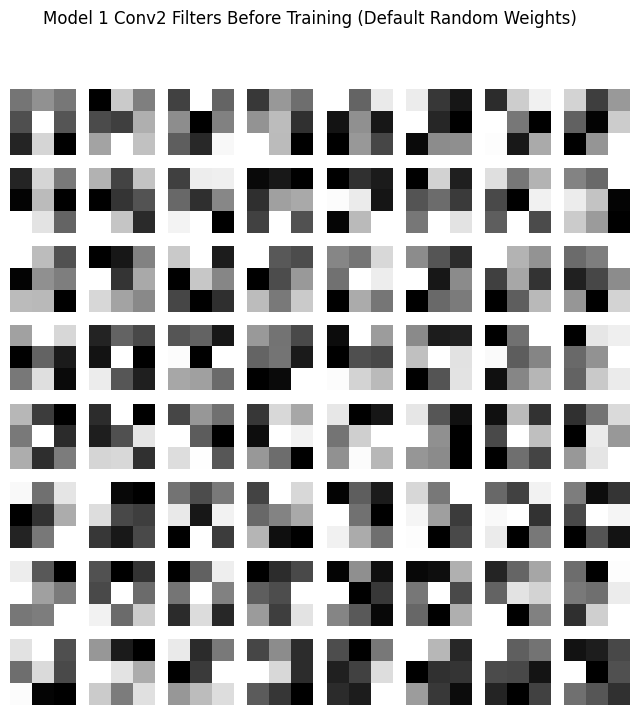

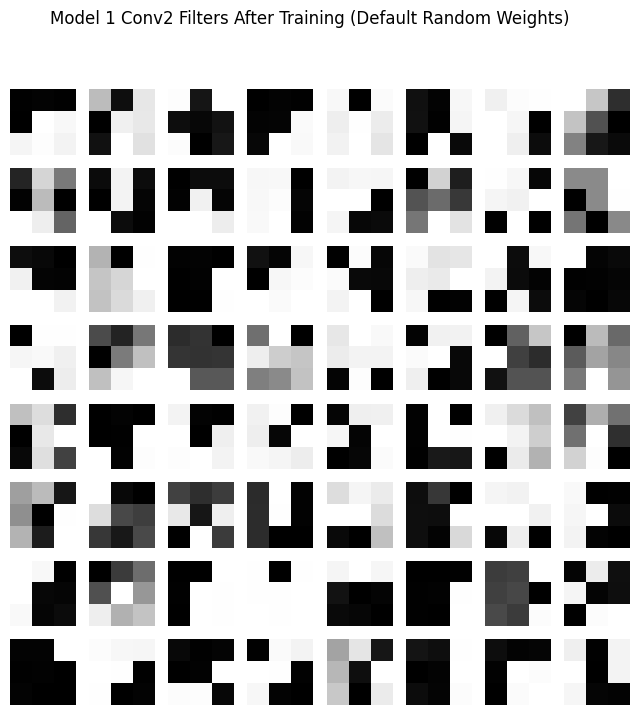

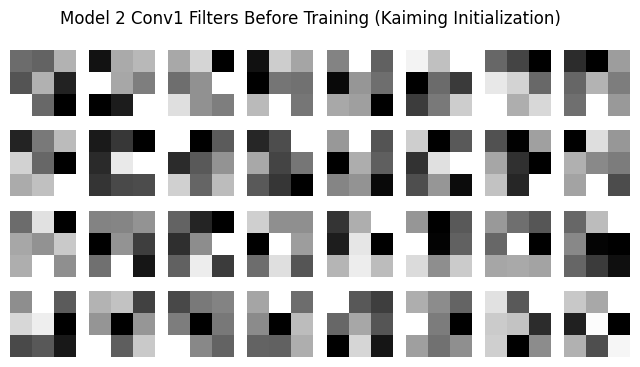

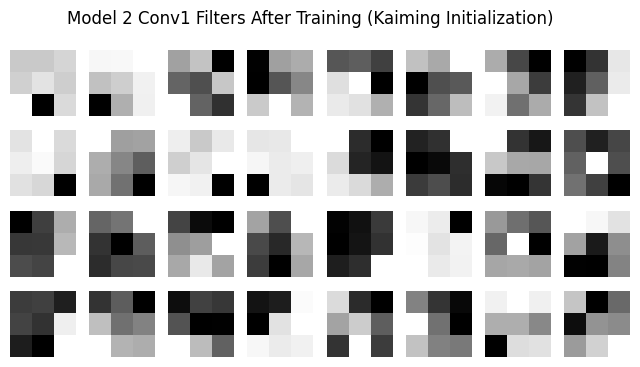

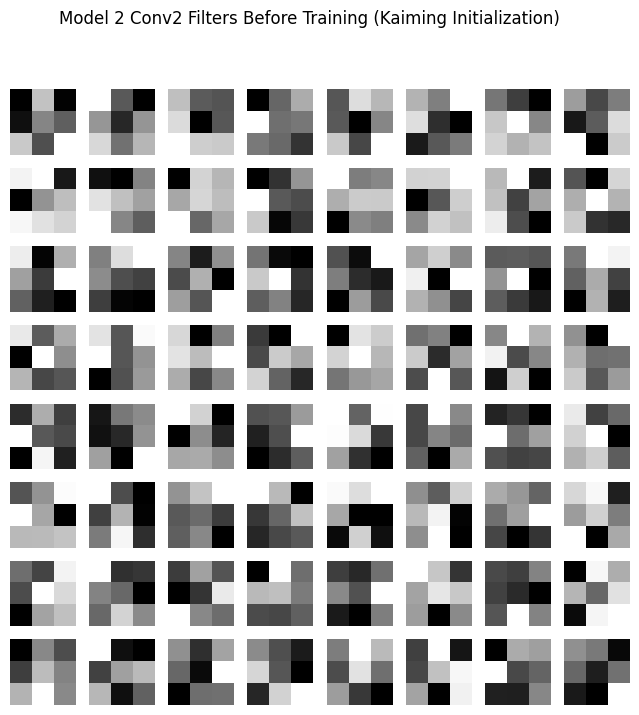

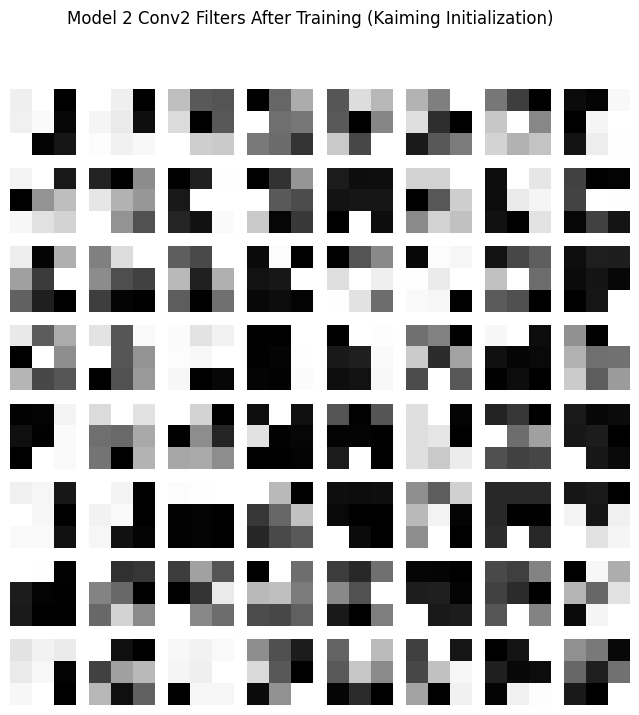

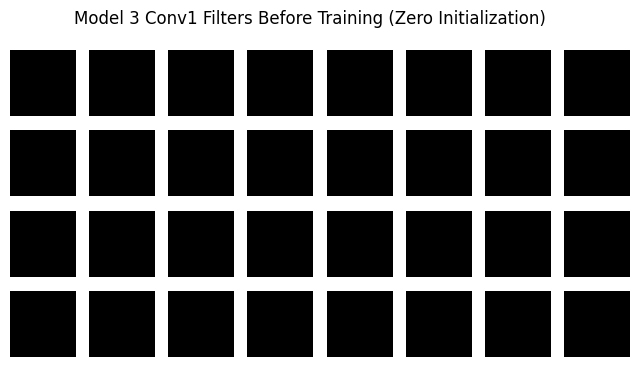

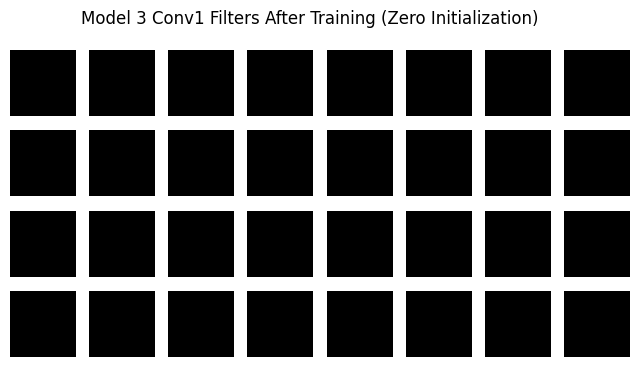

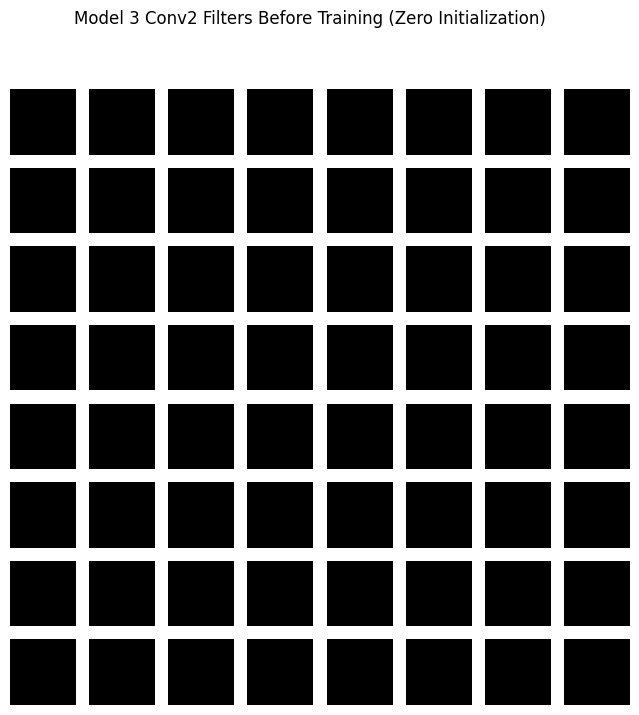

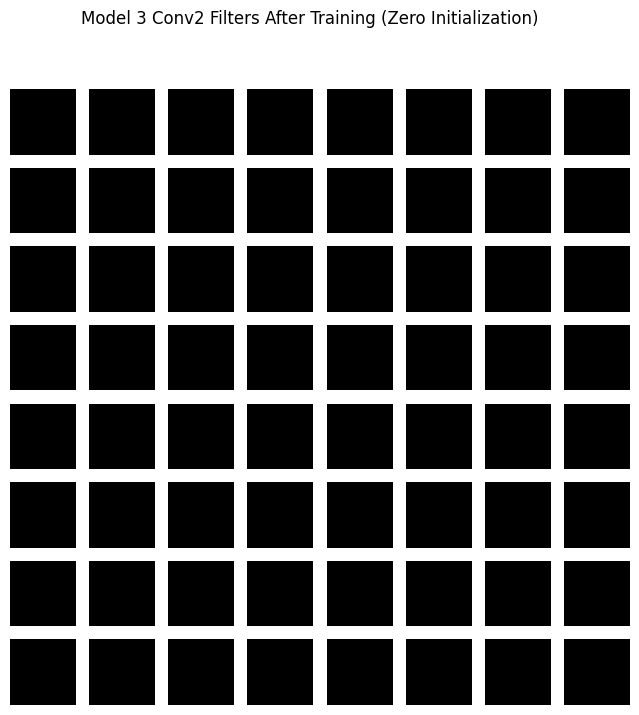

In [24]:
main_weights_comparison(0.7)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 3.770367
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.678927
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.409122
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.420518
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.348998
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.313658
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.323180
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.307507
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.339459
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.346221
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.368343
Train Epoch: 1 [7680/60000 (13%)]	Loss: 10.856879
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.293723
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.398746
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.428202
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.432000
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.320223
Train Epoc

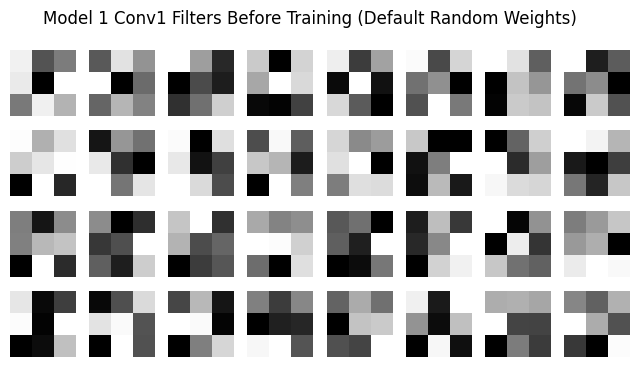

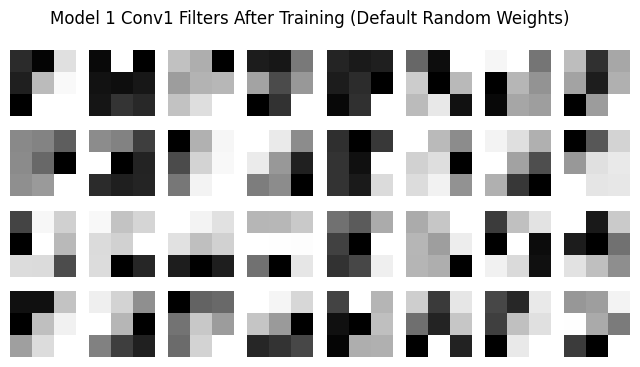

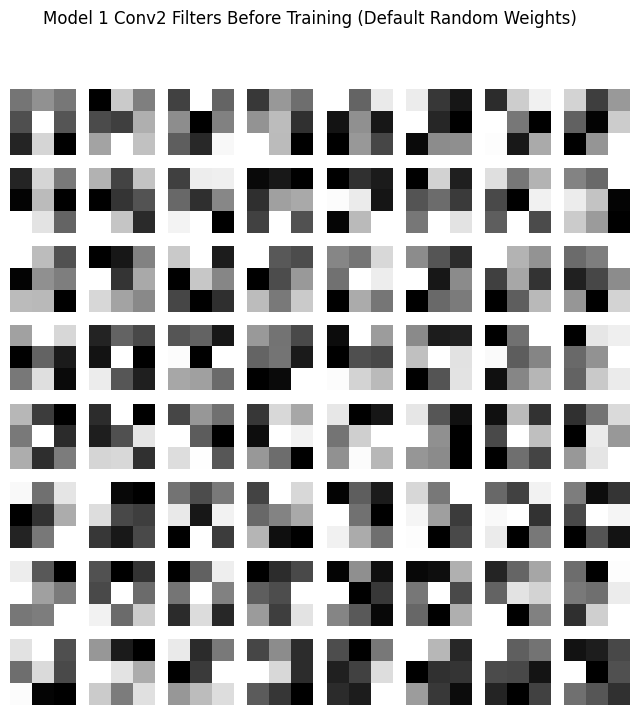

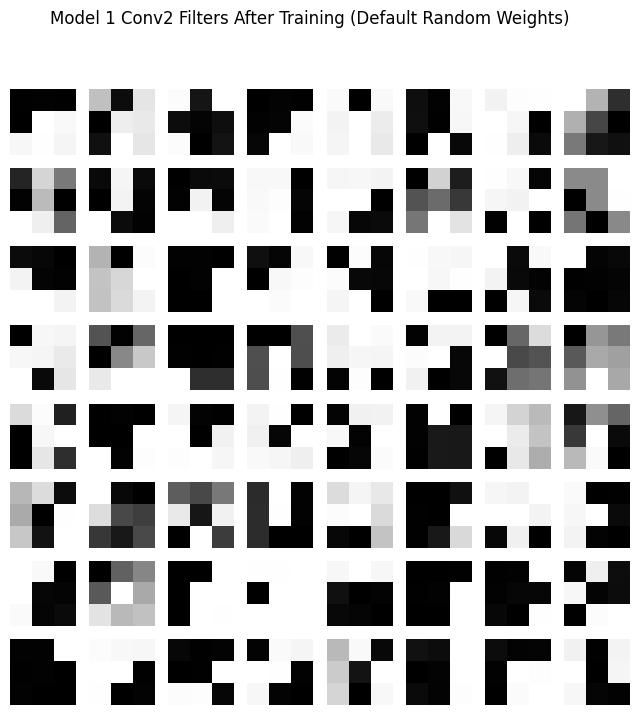

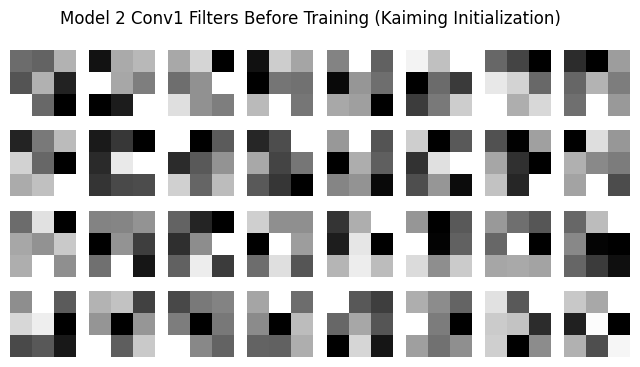

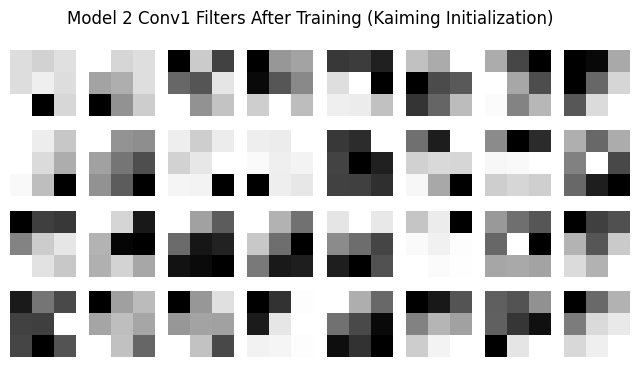

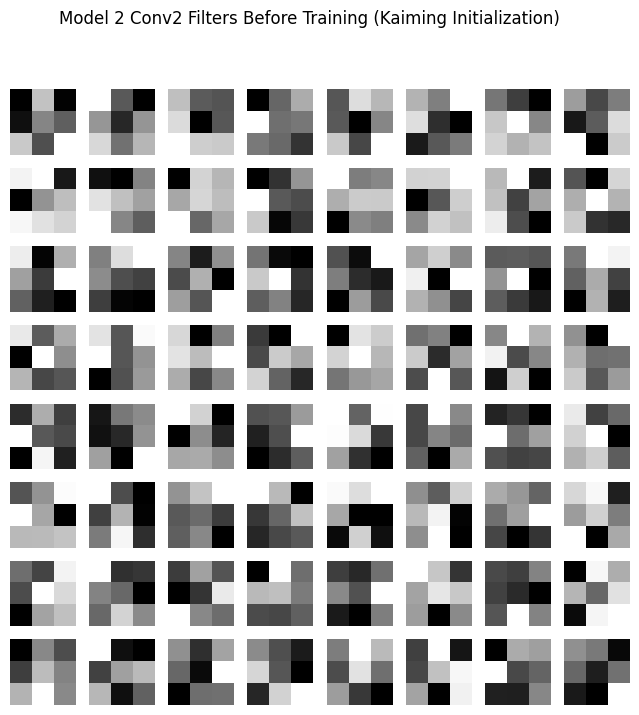

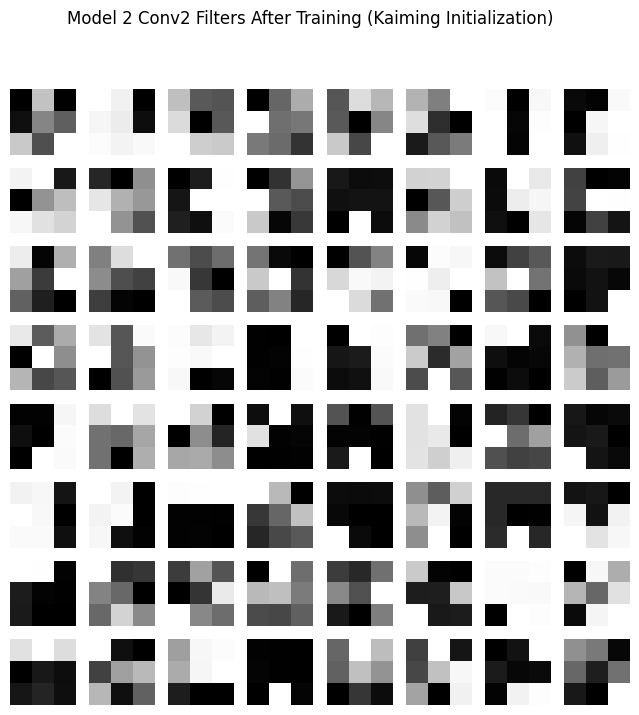

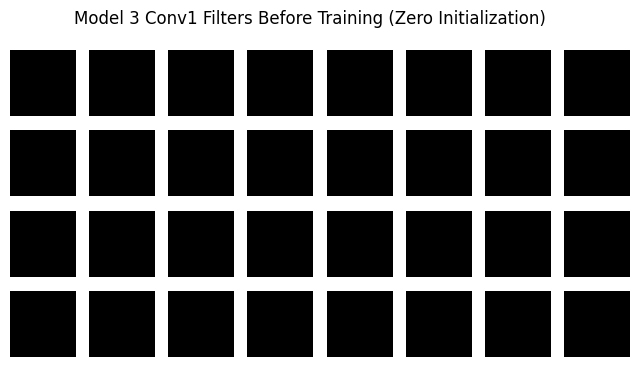

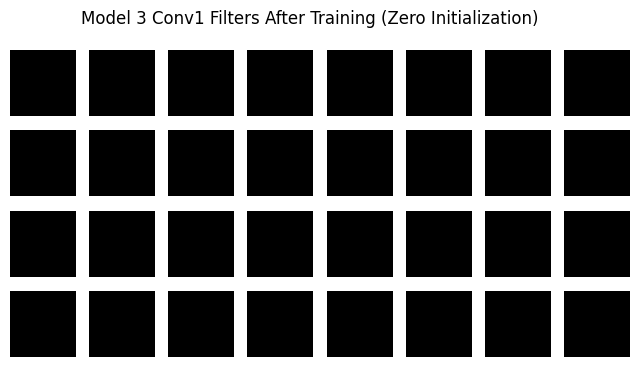

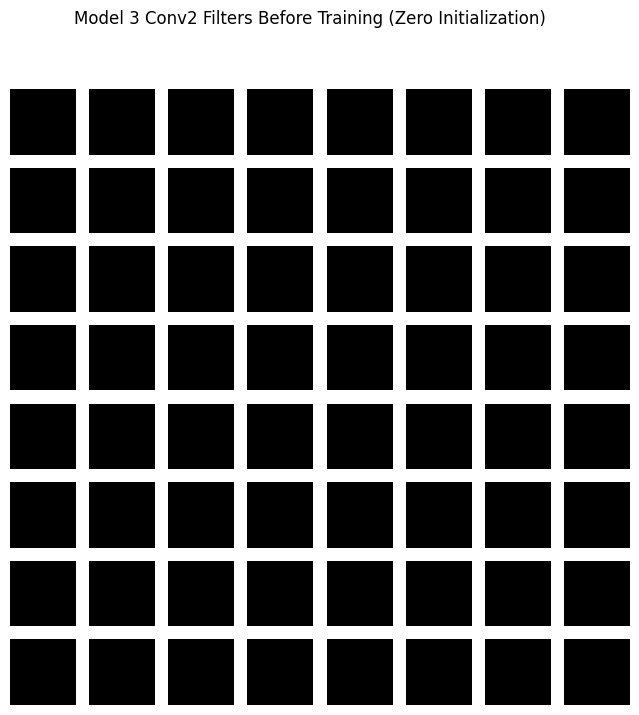

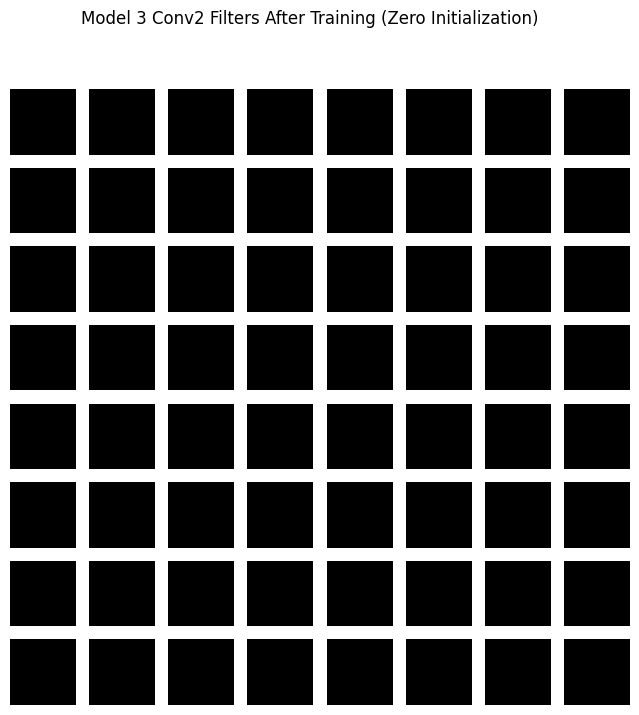

In [25]:
main_weights_comparison(0.8)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 3.101375
Train Epoch: 1 [1280/60000 (2%)]	Loss: 3.048279
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.389432
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.460925
Train Epoch: 1 [3200/60000 (5%)]	Loss: 149.512558
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.284244
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.352206
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.330020
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.342886
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.350463
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.341096
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.351244
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.317562
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.390141
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.392979
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.319763
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.319761
Train Epo

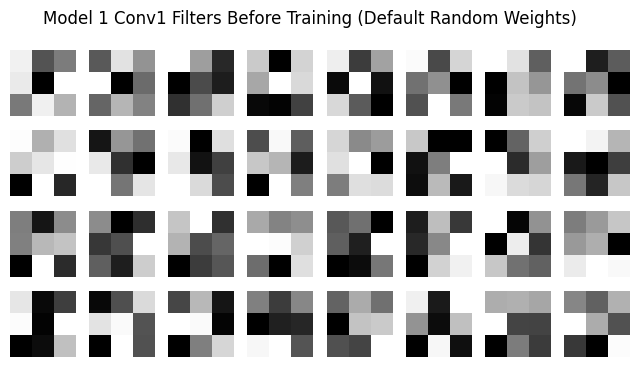

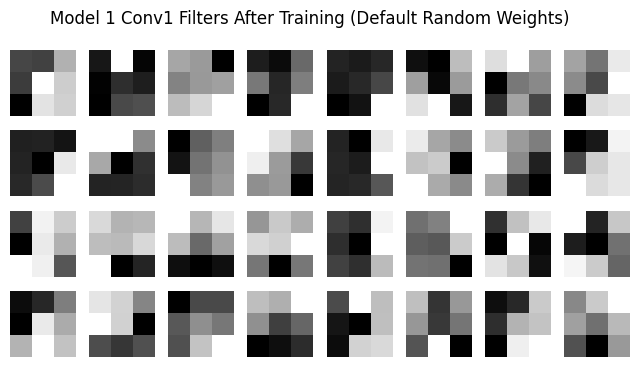

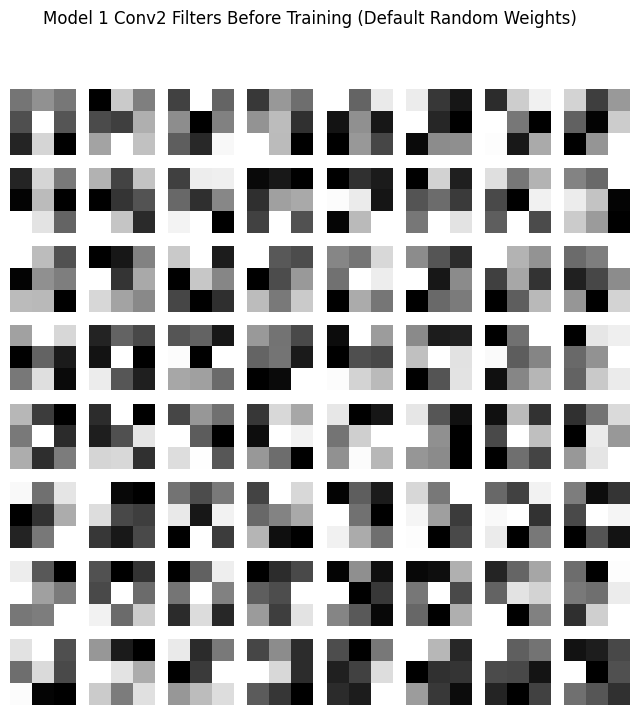

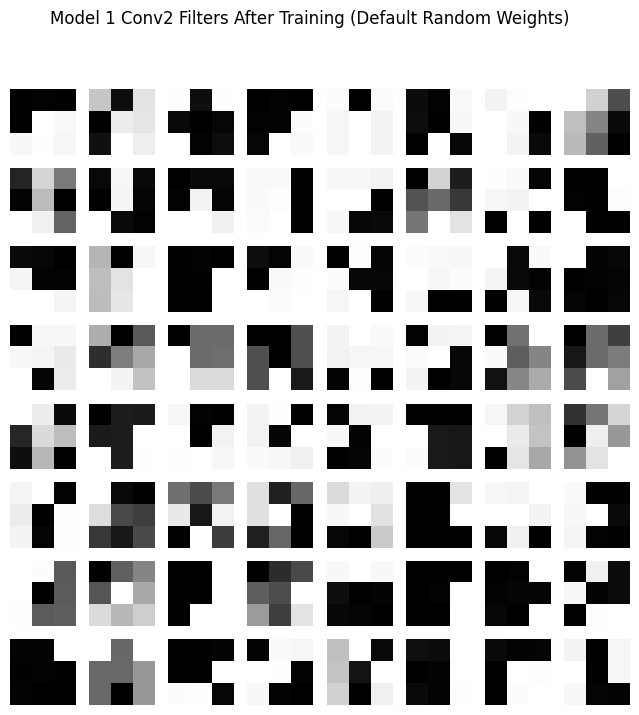

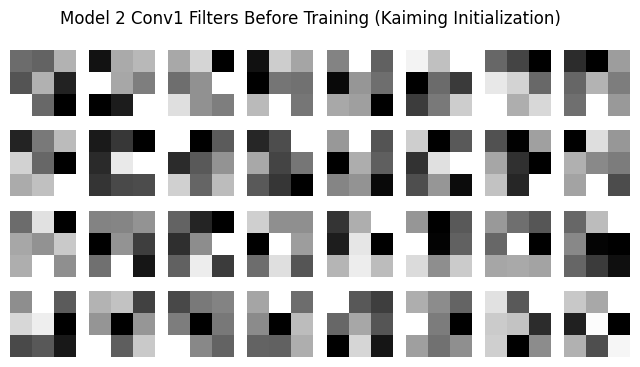

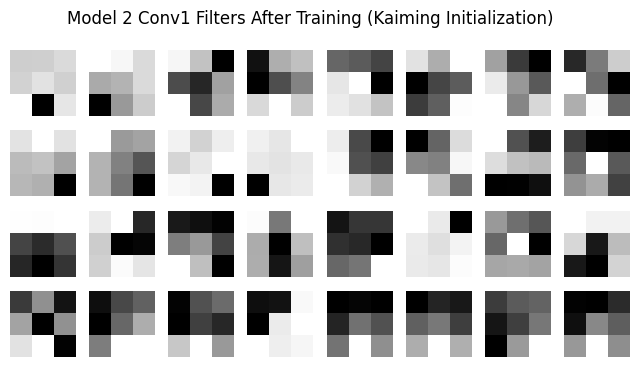

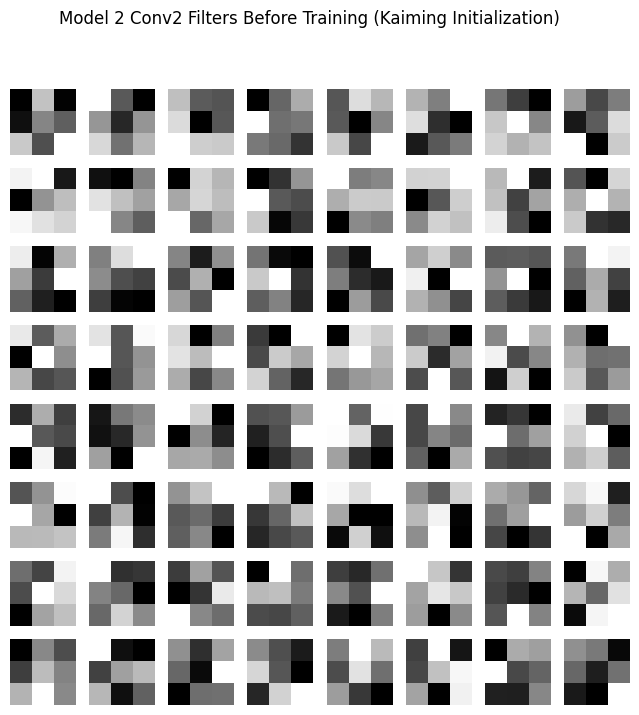

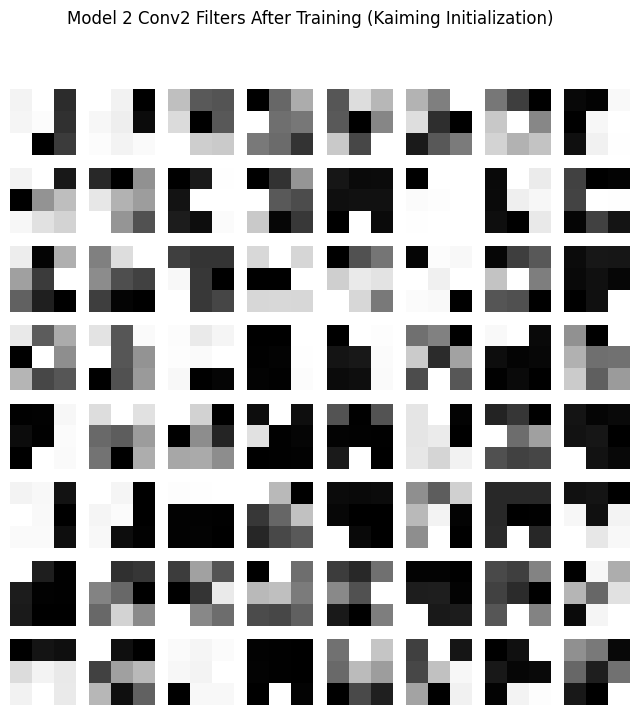

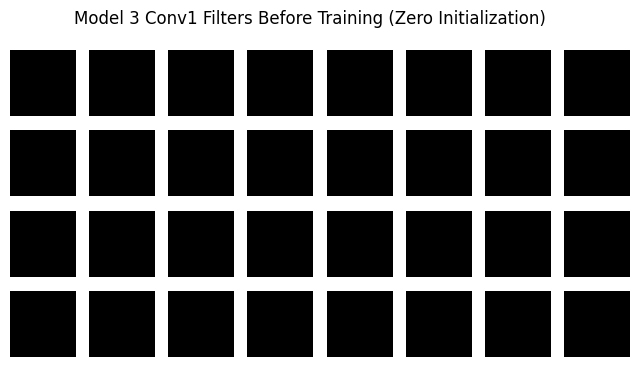

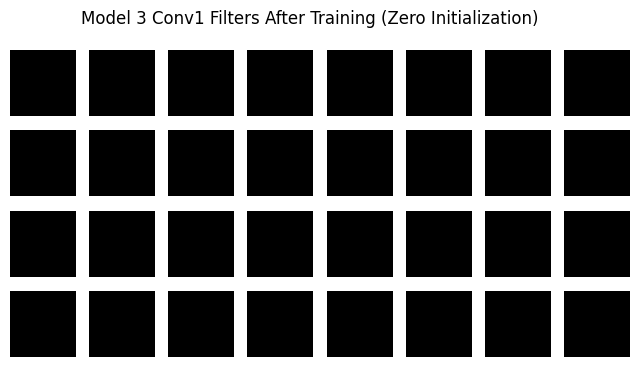

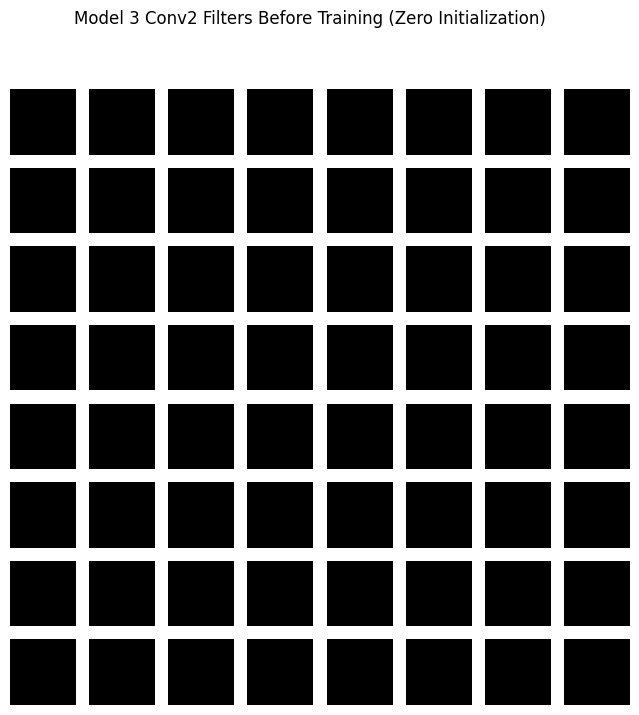

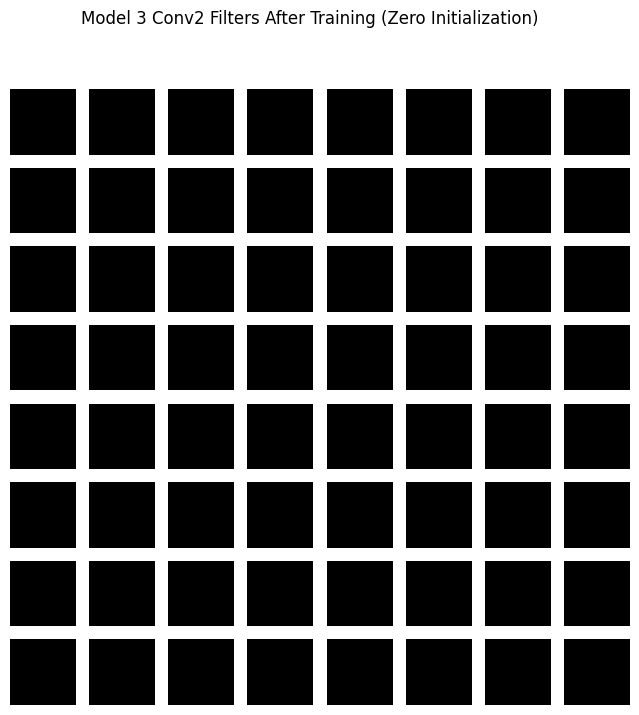

In [26]:
main_weights_comparison(0.9)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 1.682468
Train Epoch: 1 [1280/60000 (2%)]	Loss: 0.986242
Train Epoch: 1 [1920/60000 (3%)]	Loss: 0.769906
Train Epoch: 1 [2560/60000 (4%)]	Loss: 0.692919
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.551353
Train Epoch: 1 [3840/60000 (6%)]	Loss: 0.472024
Train Epoch: 1 [4480/60000 (7%)]	Loss: 0.460984
Train Epoch: 1 [5120/60000 (9%)]	Loss: 0.522712
Train Epoch: 1 [5760/60000 (10%)]	Loss: 0.554773
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.287389
Train Epoch: 1 [7040/60000 (12%)]	Loss: 0.358566
Train Epoch: 1 [7680/60000 (13%)]	Loss: 0.453527
Train Epoch: 1 [8320/60000 (14%)]	Loss: 0.375222
Train Epoch: 1 [8960/60000 (15%)]	Loss: 0.411058
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.852222
Train Epoch: 1 [10240/60000 (17%)]	Loss: 0.752232
Train Epoch: 1 [10880/60000 (18%)]	Loss: 0.282364
Train Epoch

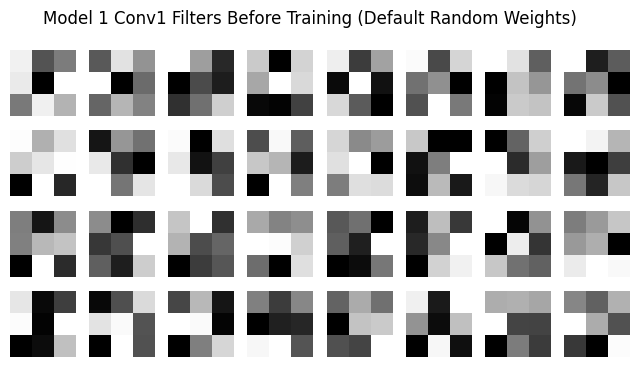

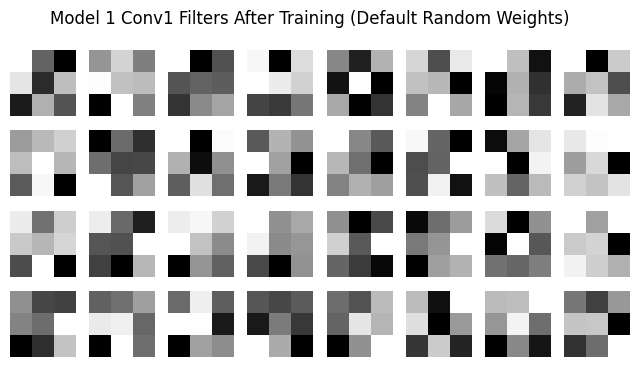

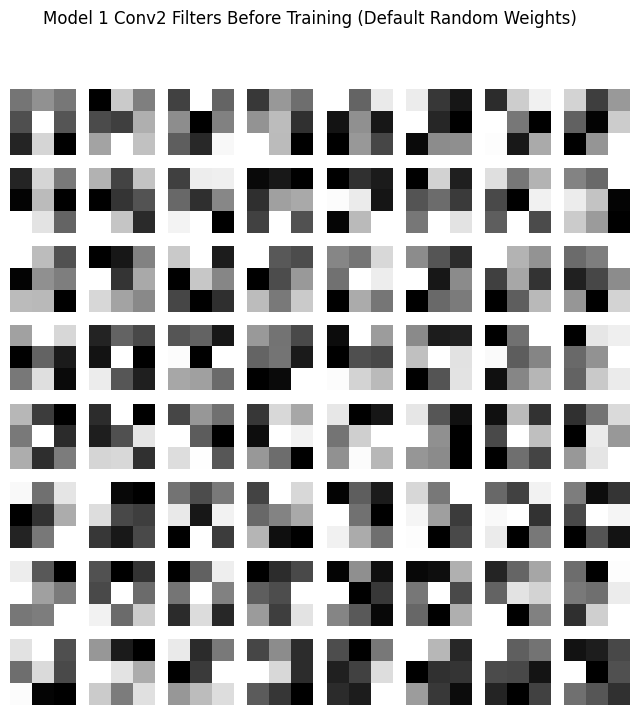

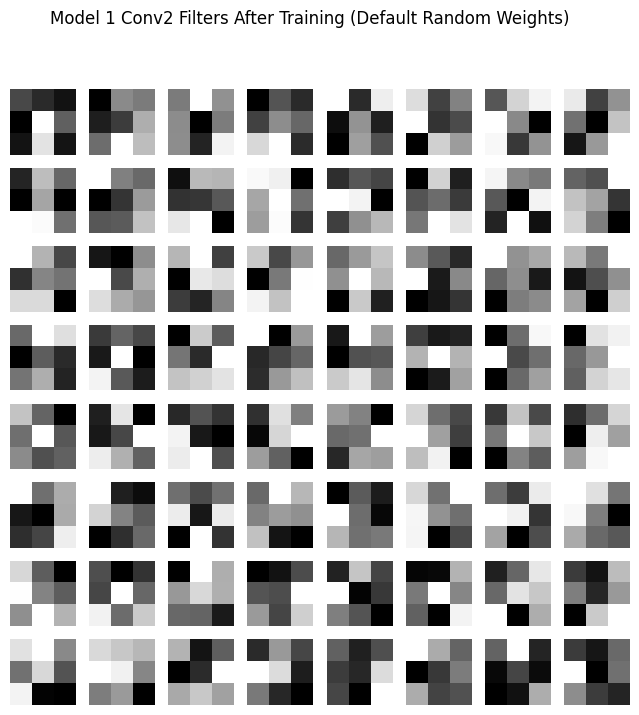

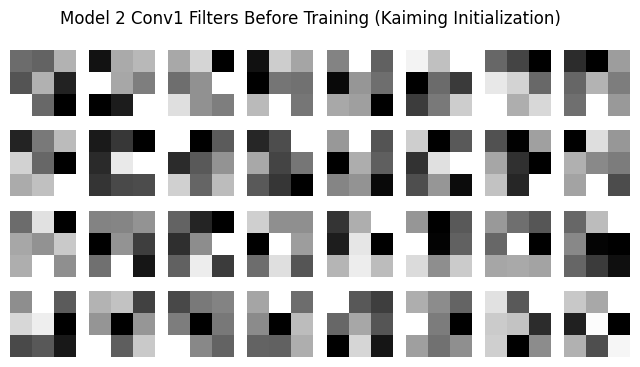

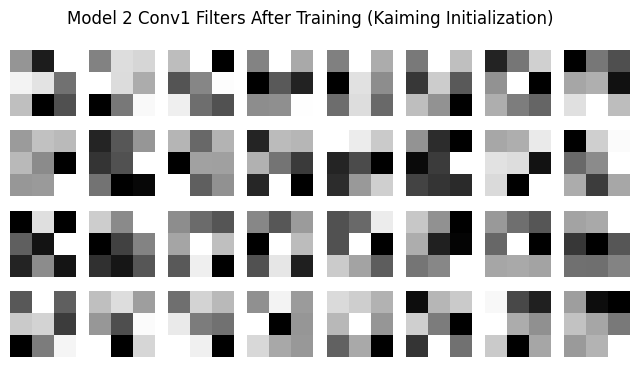

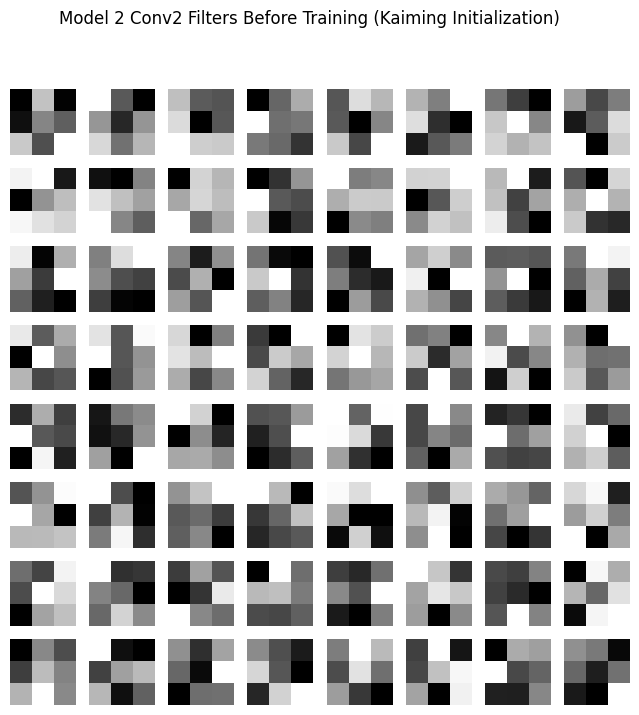

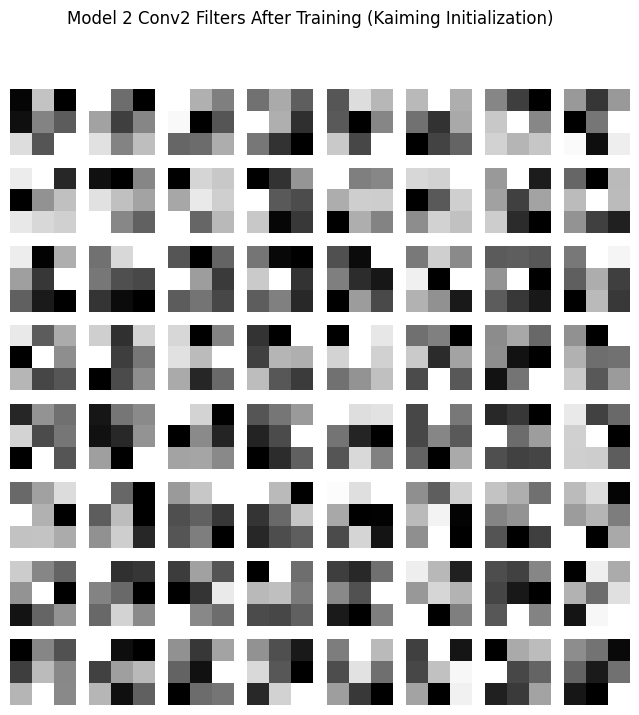

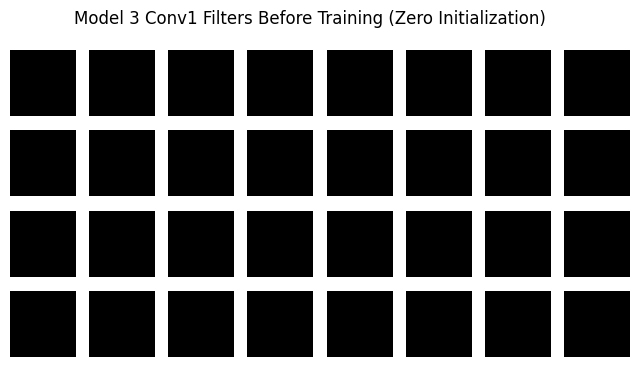

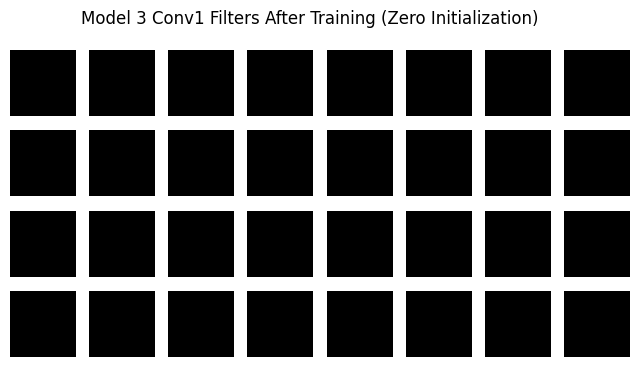

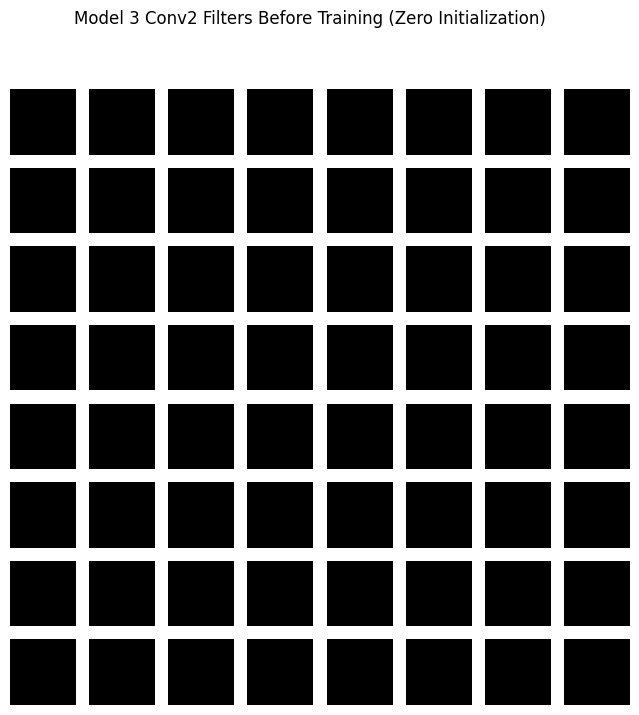

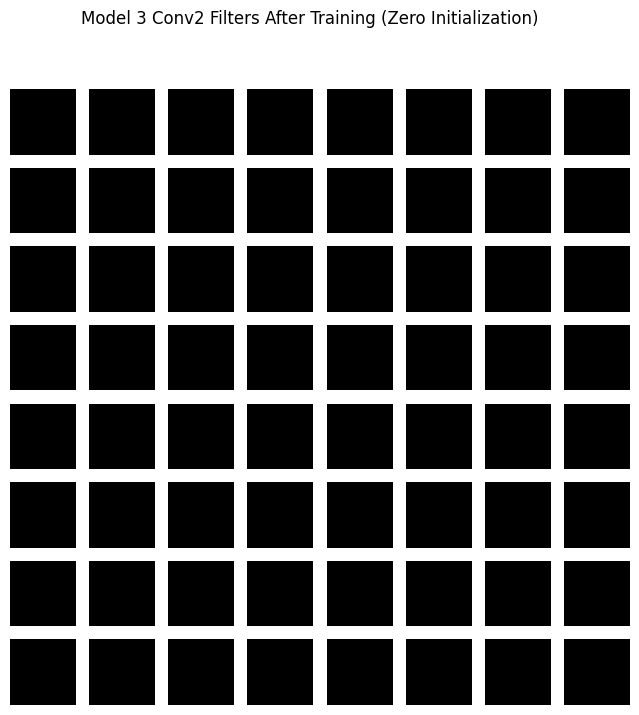

In [27]:
main_weights_comparison(0.01)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.310387
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.306198
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.304124
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.303417
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.292183
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.304301
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.297125
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.297171
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.286443
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.301059
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.299604
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.305854
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.296904
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.283685
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.291954
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.294937
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.308699
Train Epoch

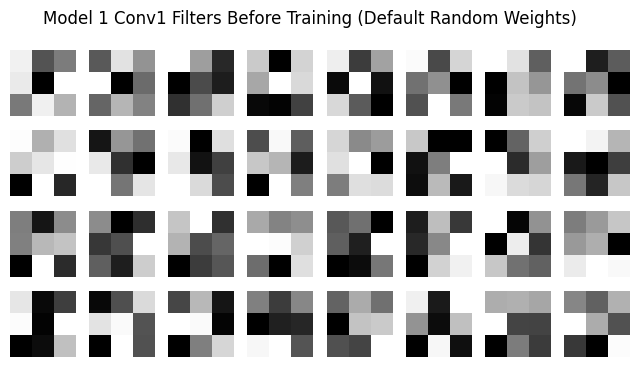

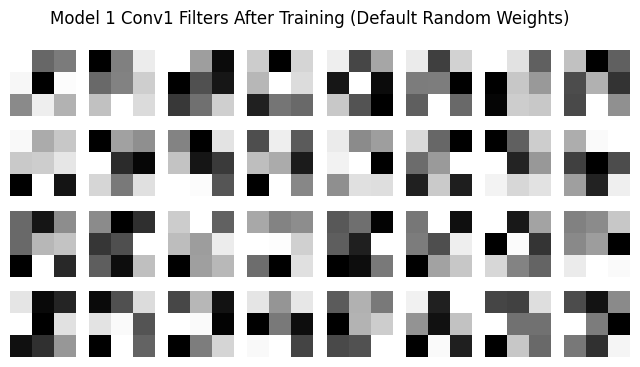

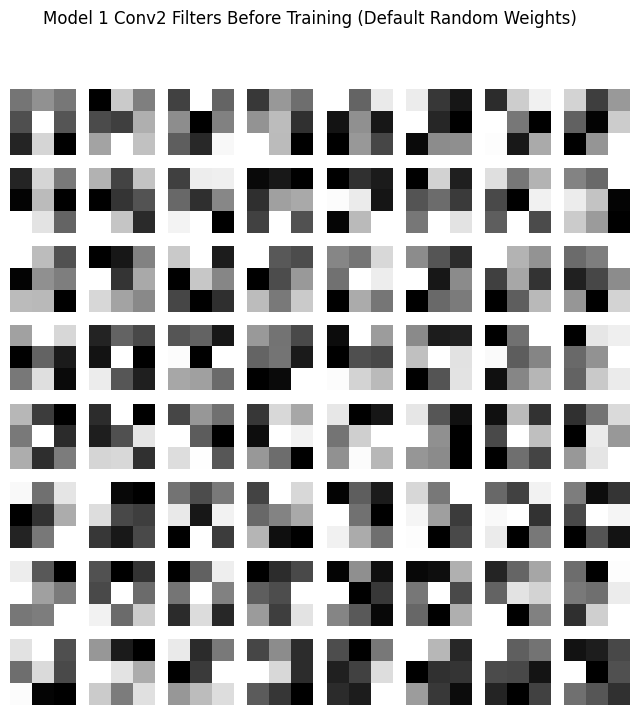

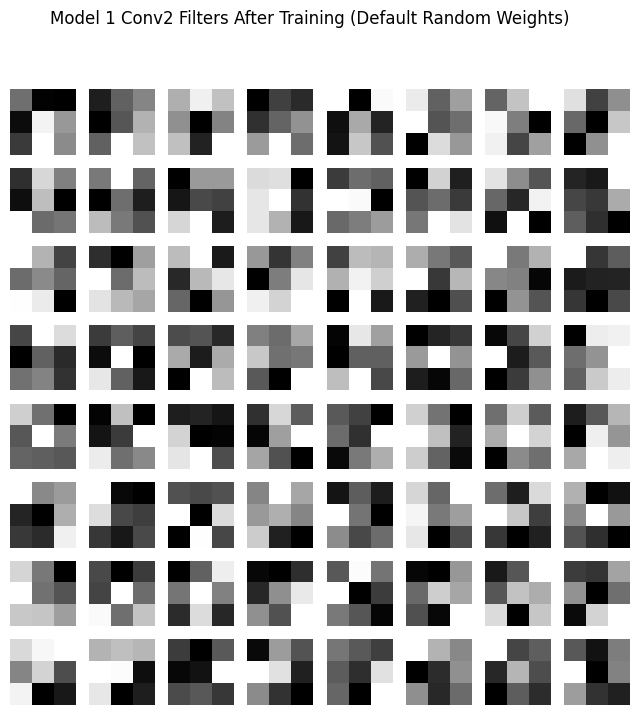

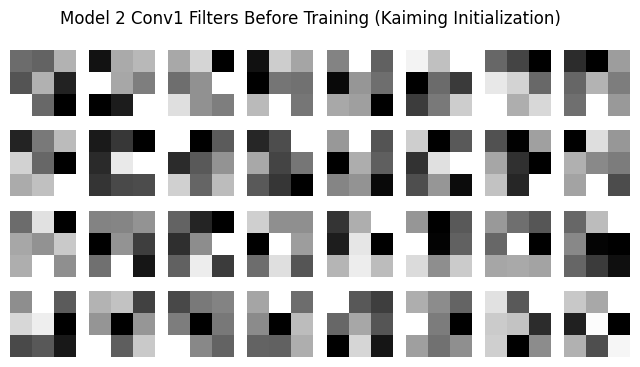

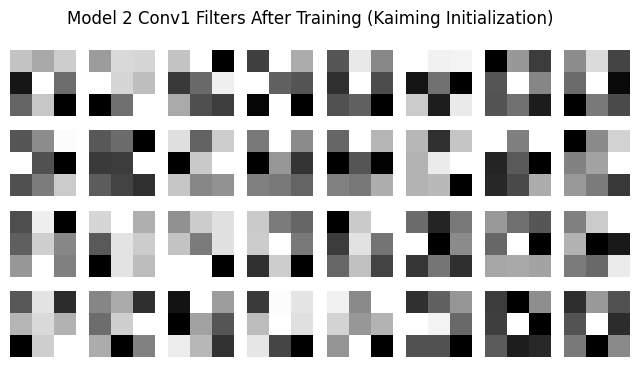

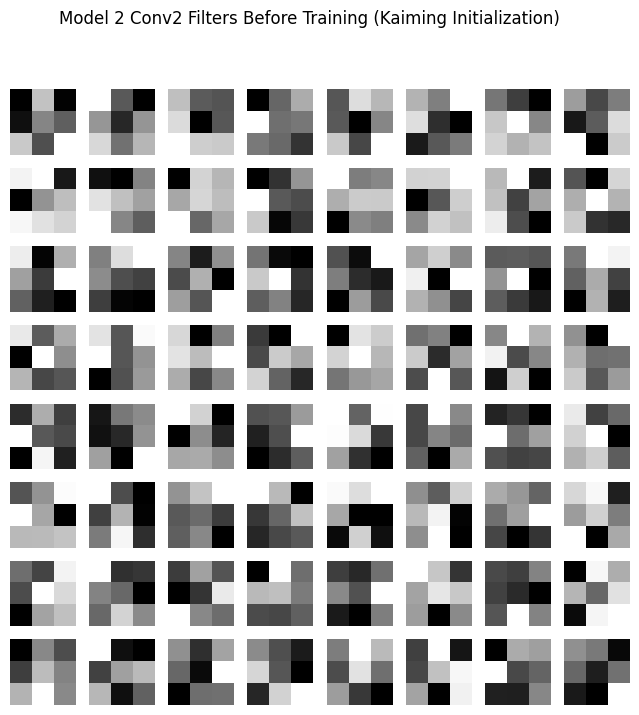

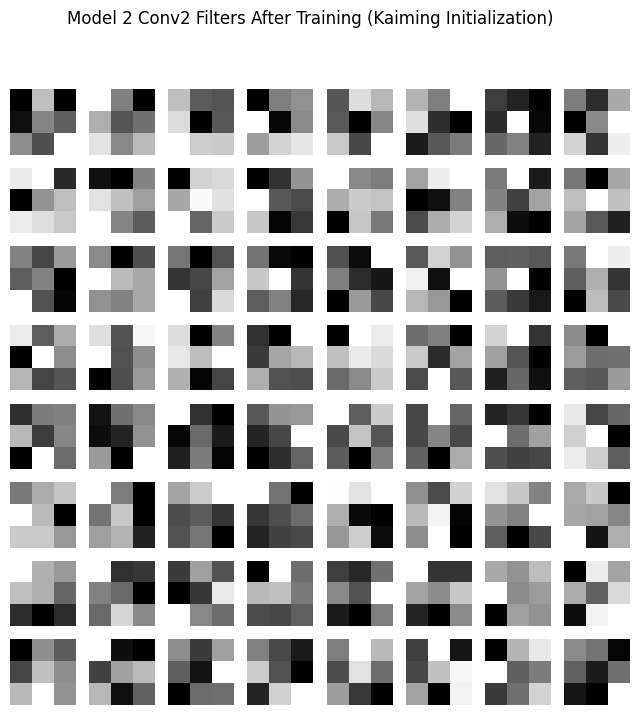

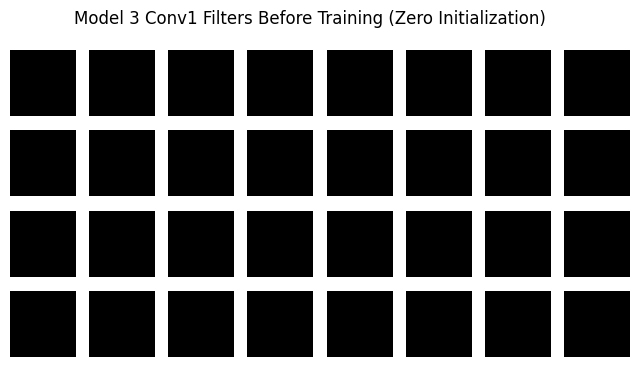

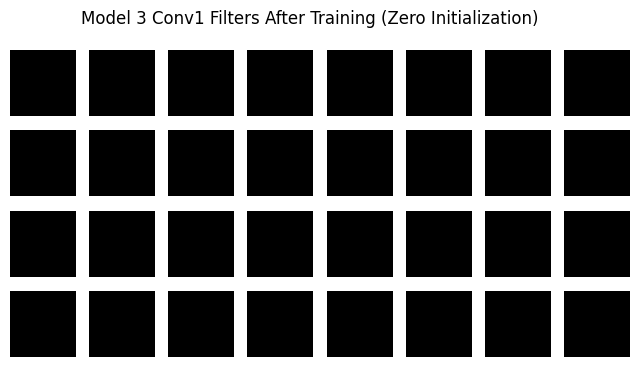

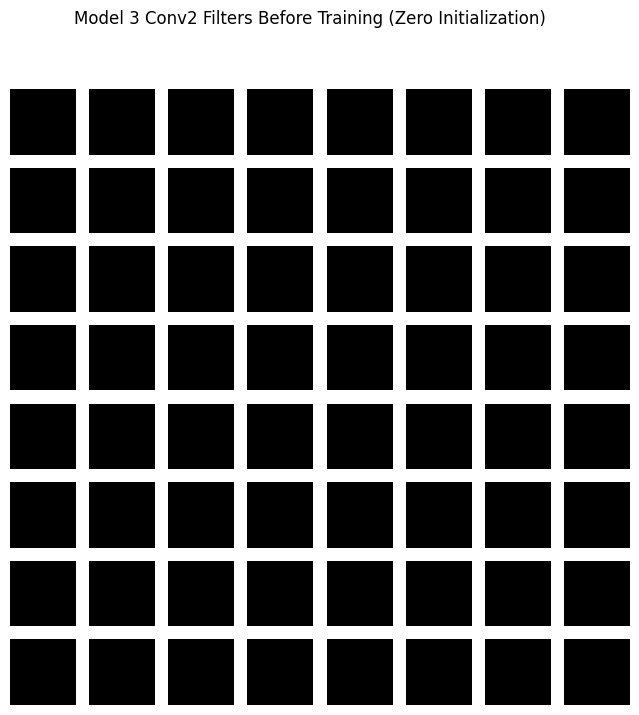

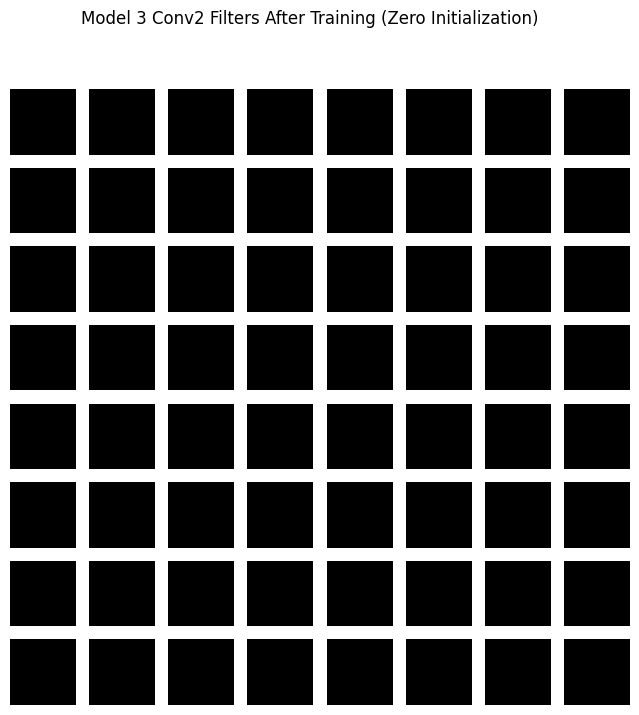

In [28]:
main_weights_comparison(0.02)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.320617
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.301803
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.300430
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.298748
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.300180
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.300746
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.308601
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.297233
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.282253
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.302542
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.301972
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.307261
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.298107
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.282219
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.292933
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.296462
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.309048
Train Epoch

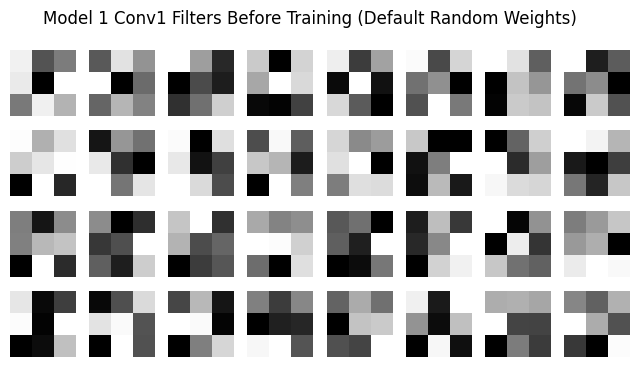

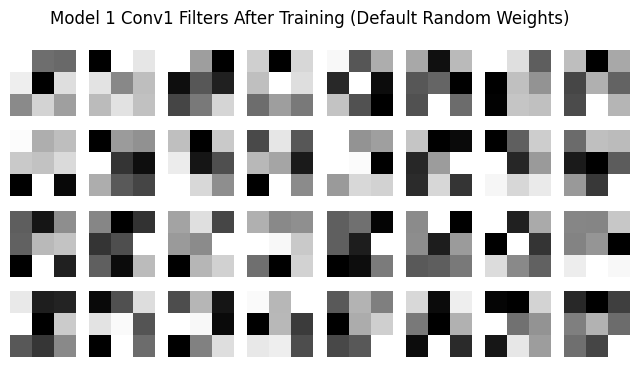

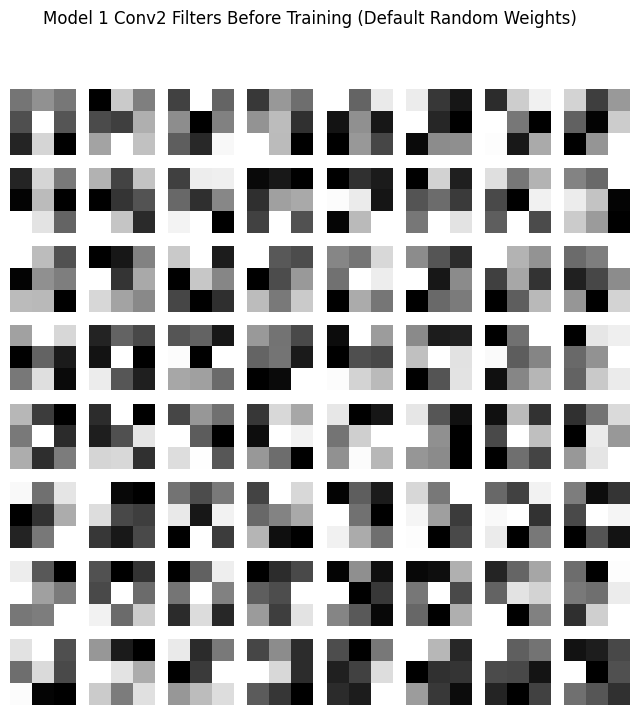

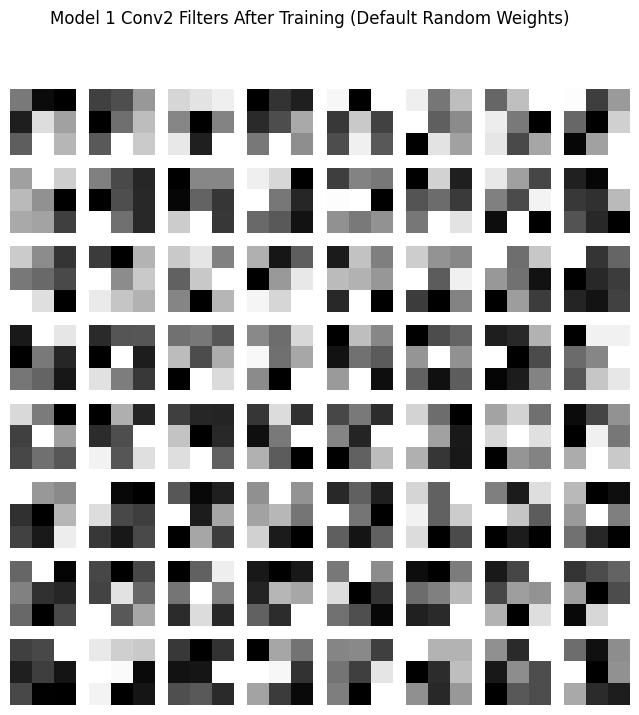

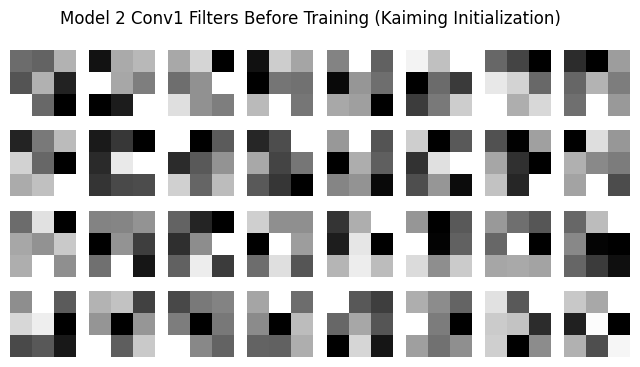

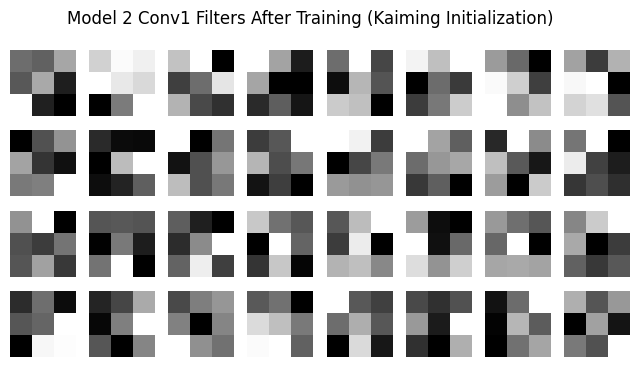

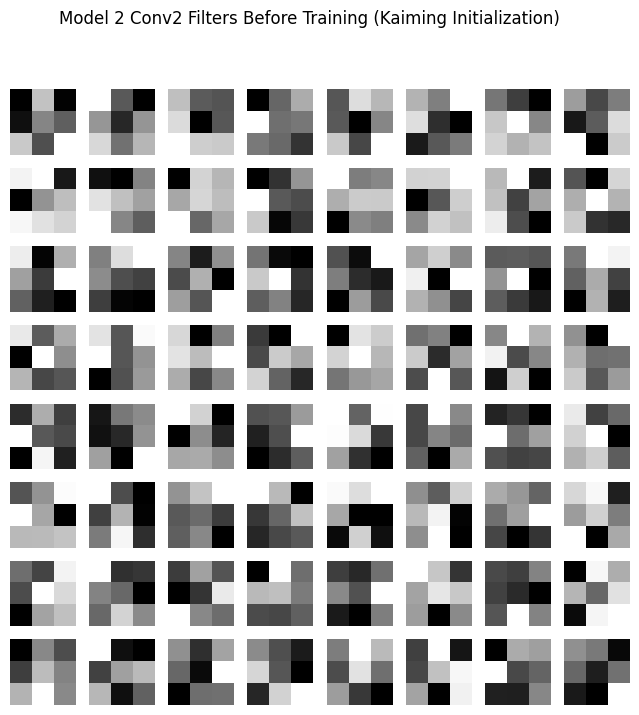

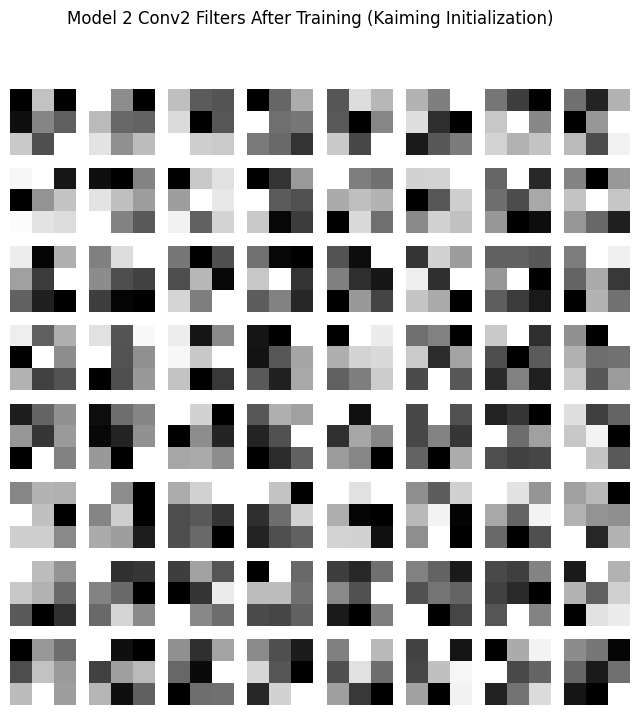

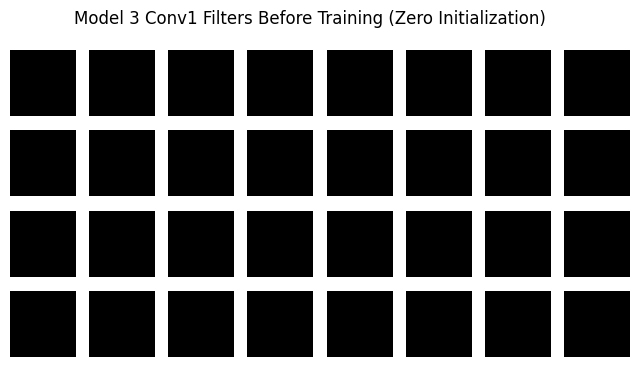

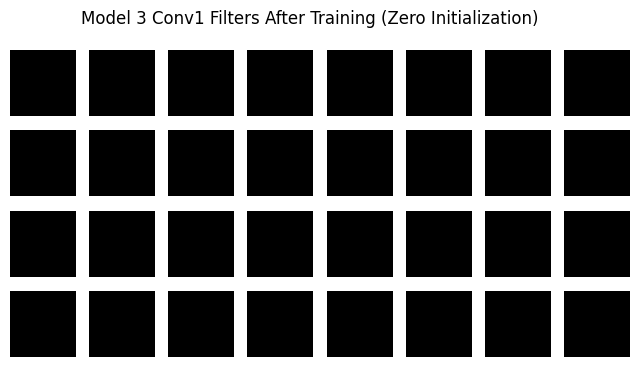

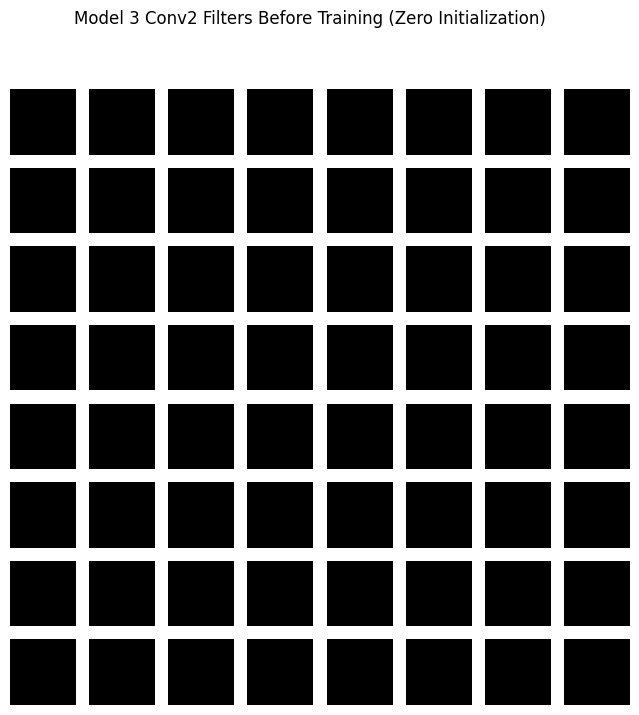

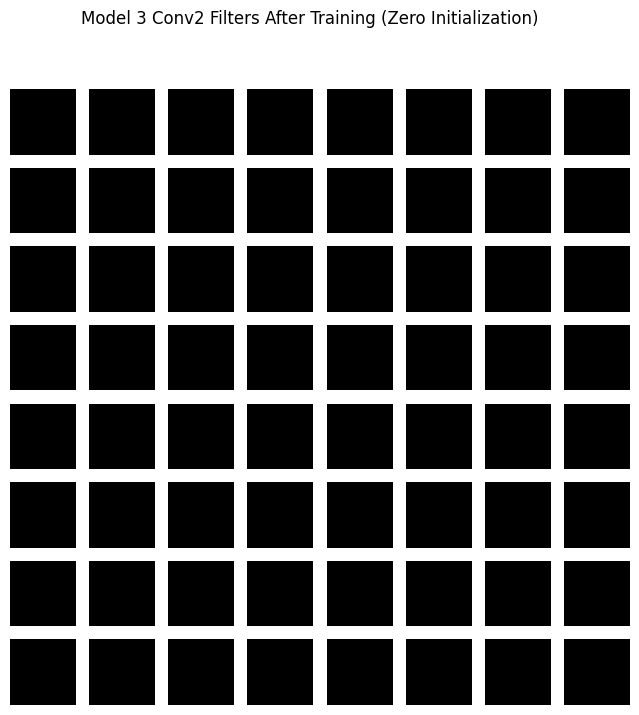

In [29]:
main_weights_comparison(0.03)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.316889
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.306418
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.298688
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.306571
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.306687
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.315080
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.301613
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.299121
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.287695
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.294546
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.298107
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.310008
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.298909
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.279205
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.294067
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.296685
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.308788
Train Epoch

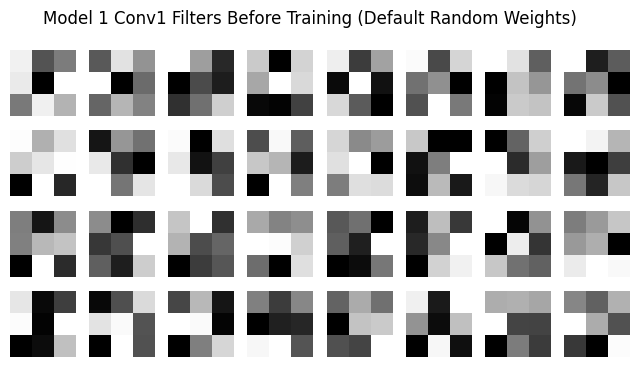

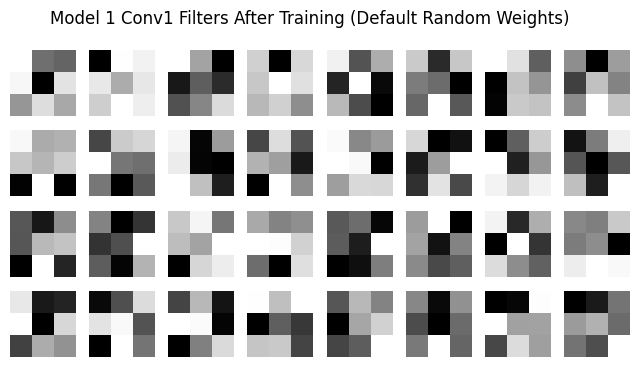

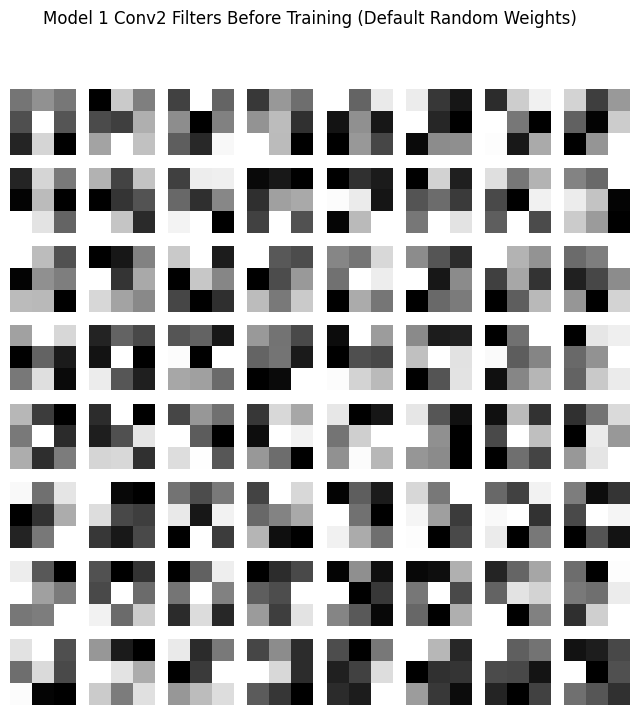

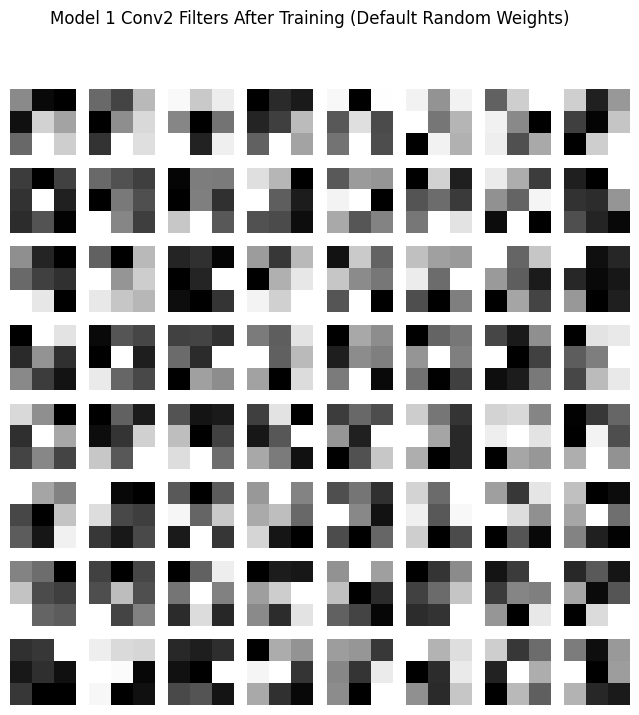

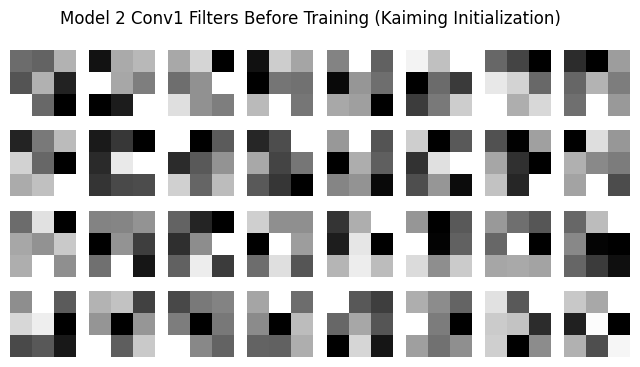

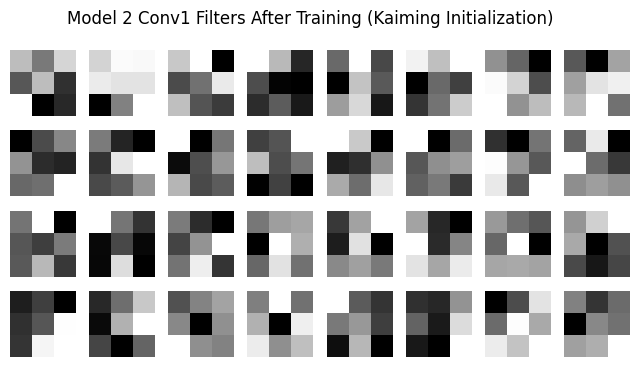

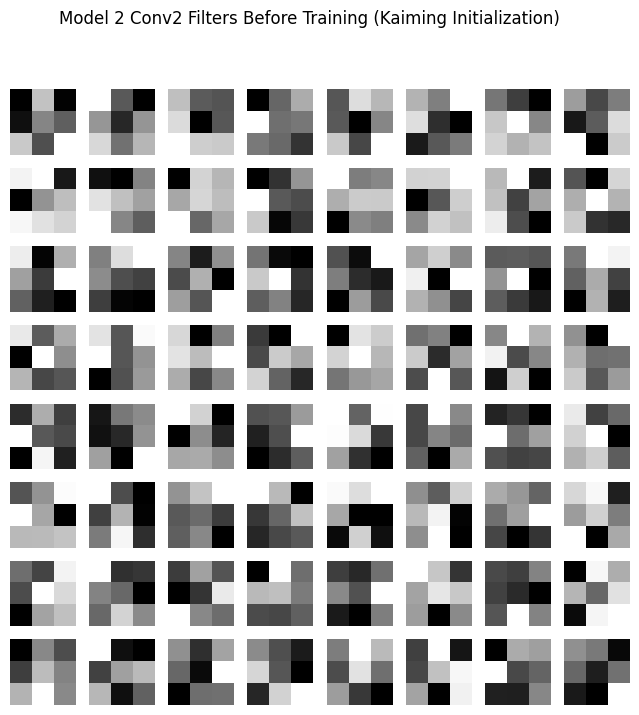

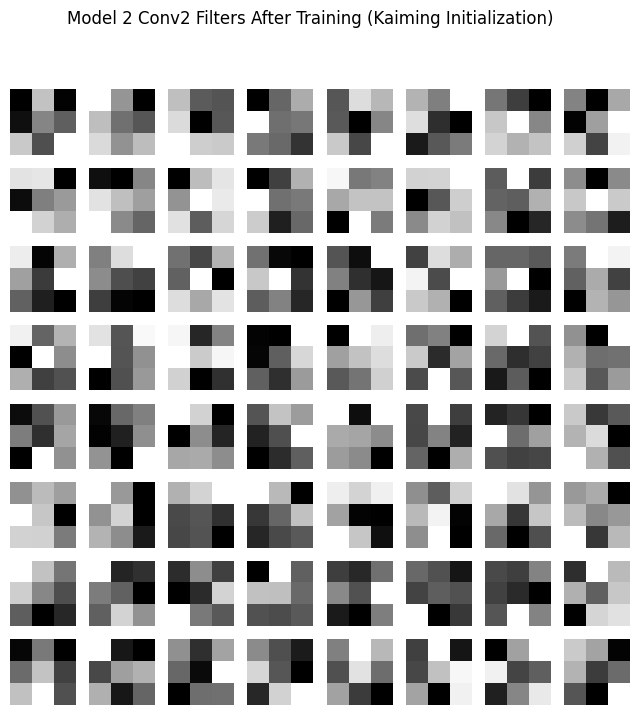

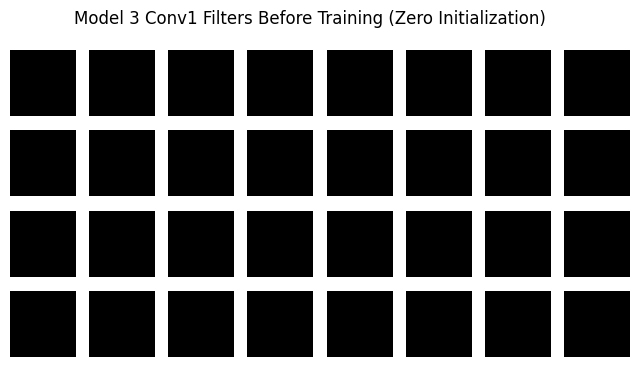

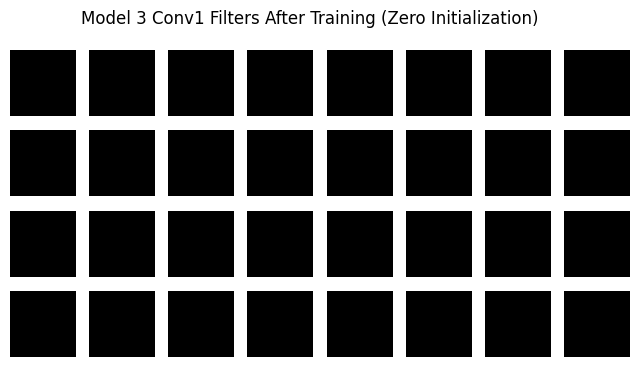

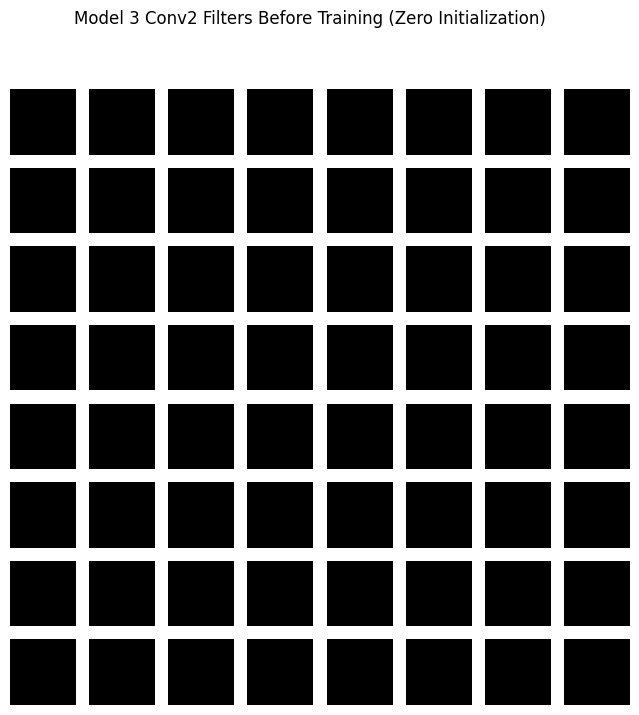

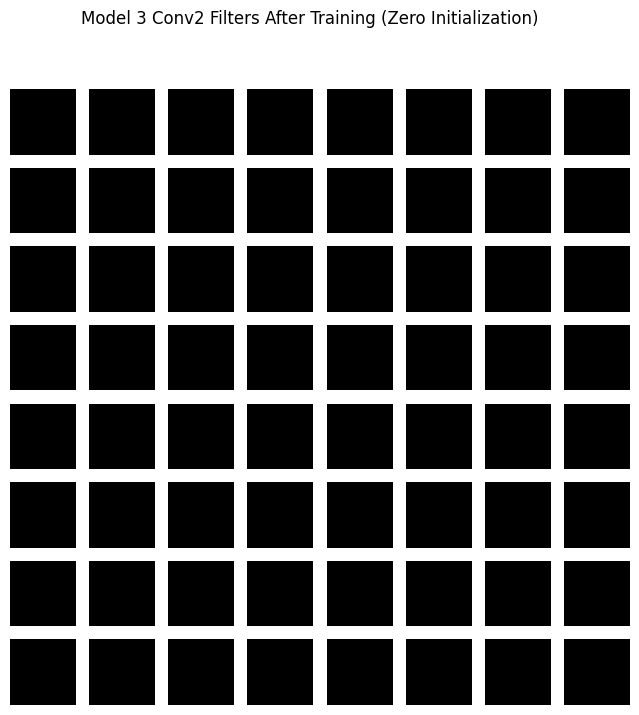

In [30]:
main_weights_comparison(0.04)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.326241
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.303838
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.298107
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.305976
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.309724
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.298568
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.323632
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.298010
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.284492
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.300897
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.304634
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.309680
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.299785
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.280788
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.291896
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.305263
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.307259
Train Epoch

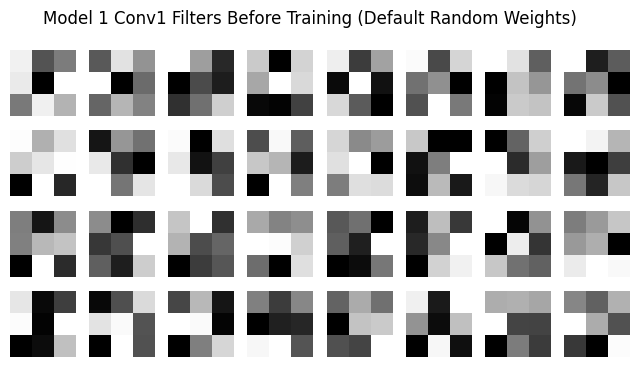

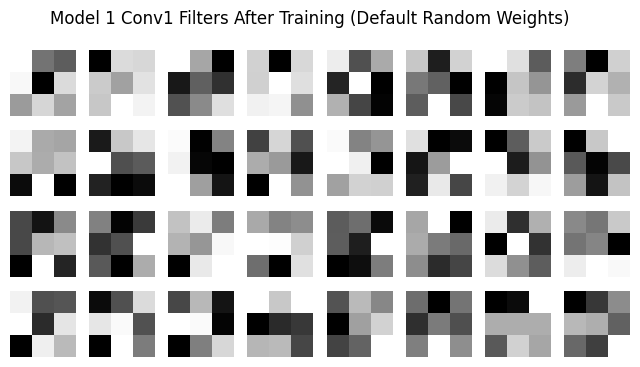

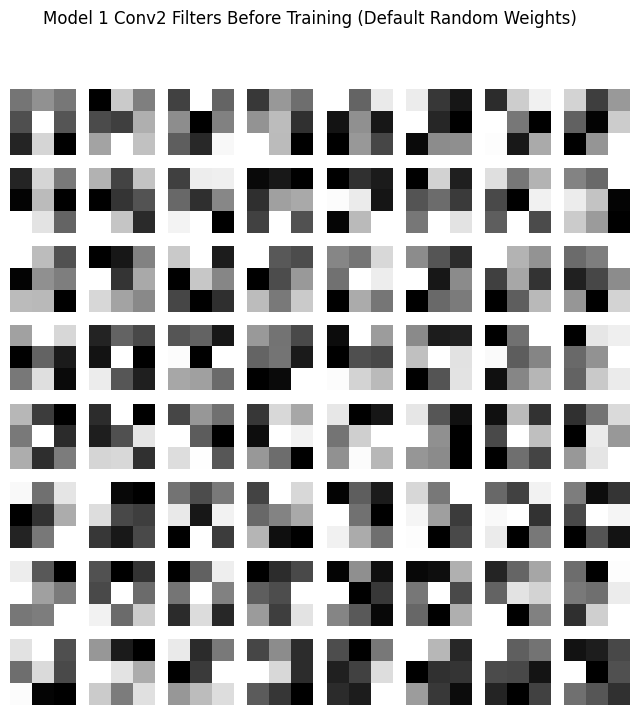

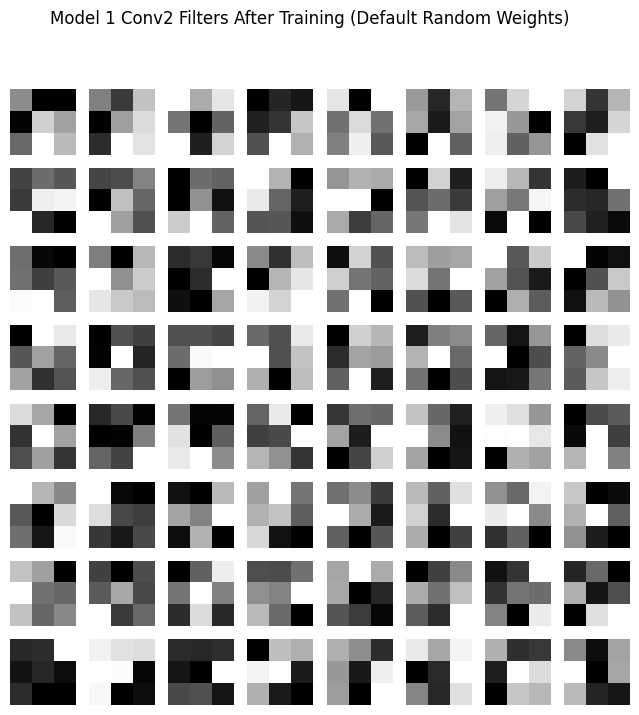

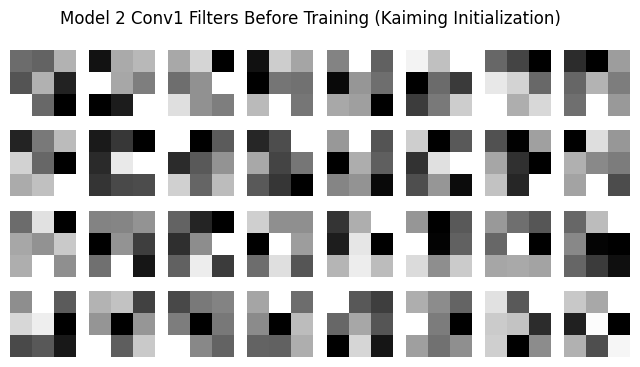

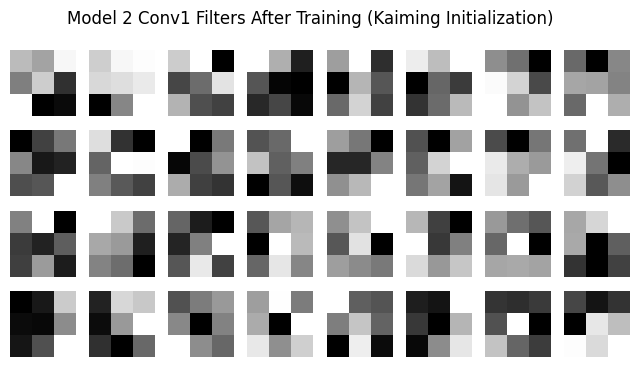

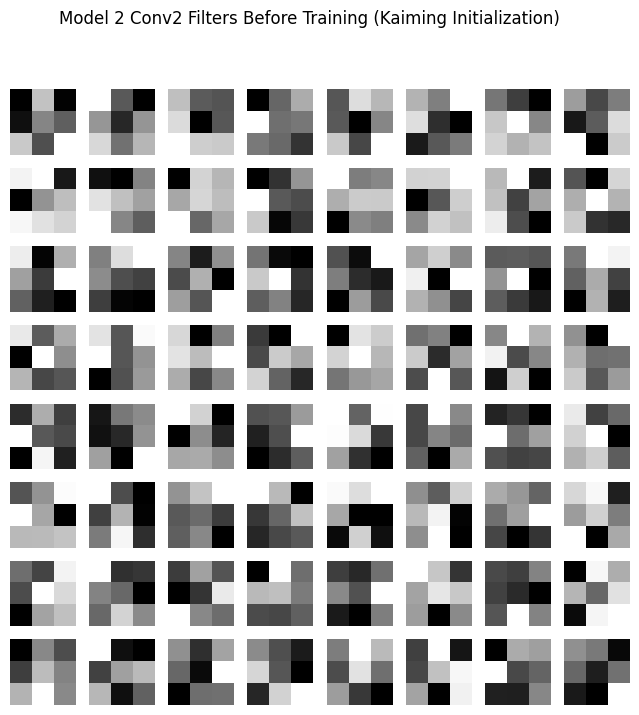

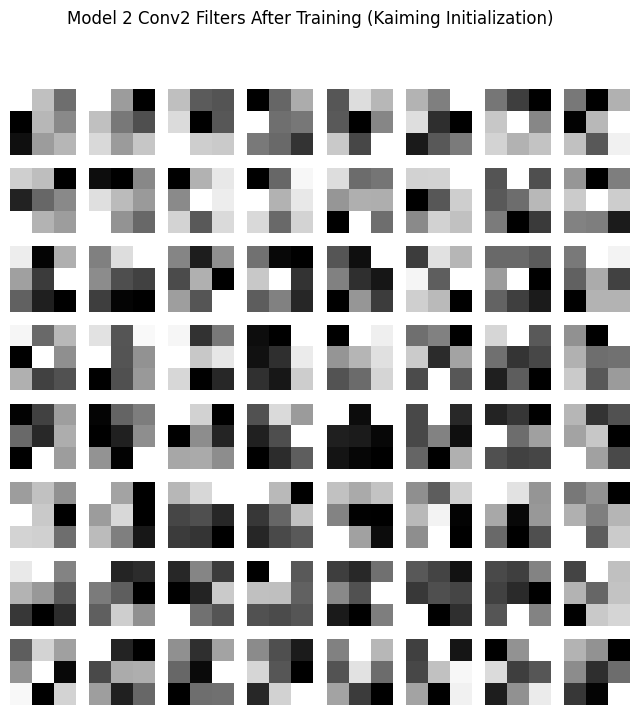

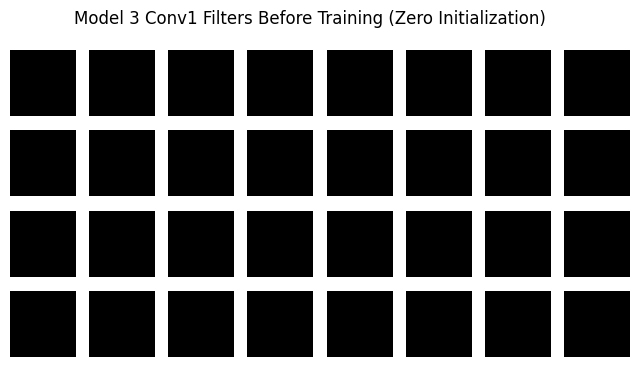

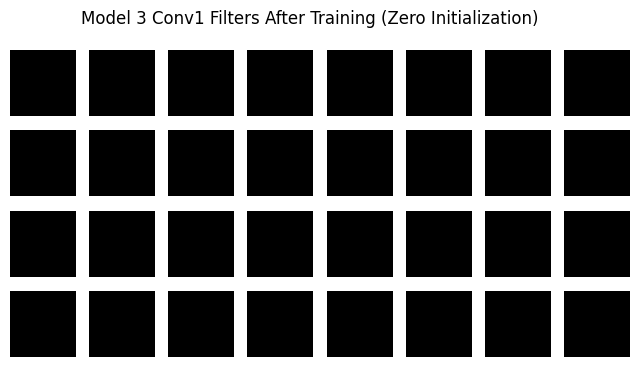

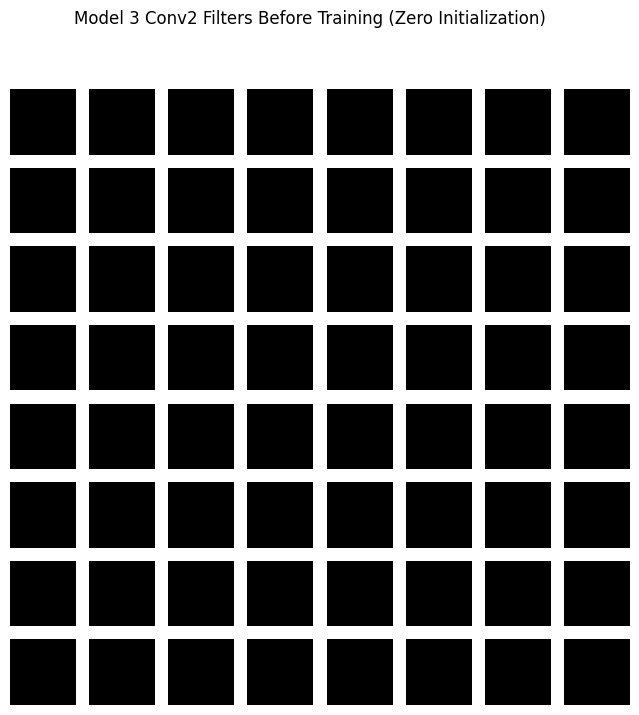

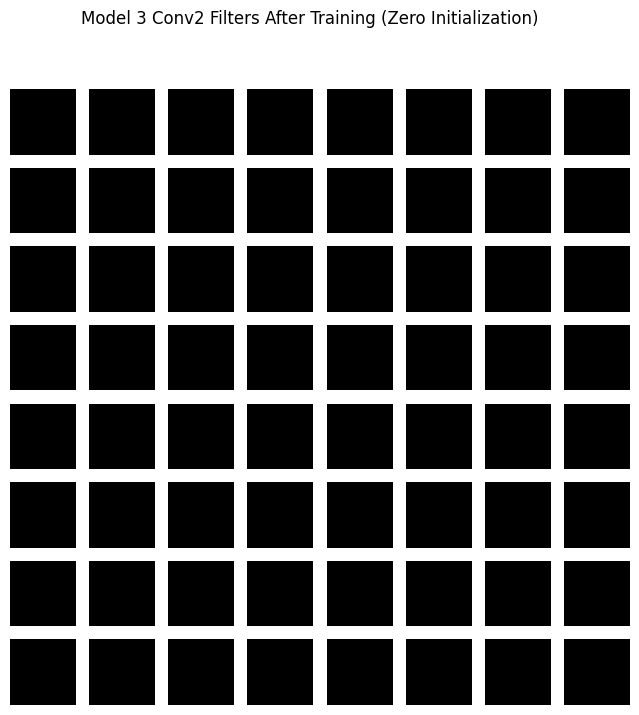

In [31]:
main_weights_comparison(0.05)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.338052
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.296694
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.293161
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.313819
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.310468
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.299372
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.303220
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.299700
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.288373
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.290308
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.297452
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.321971
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.297733
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.280368
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.294943
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.299144
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.307694
Train Epoch

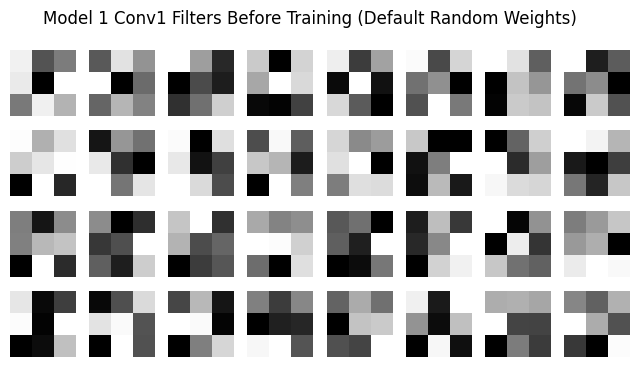

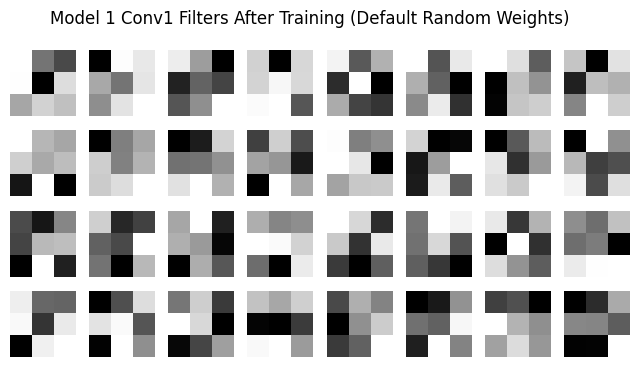

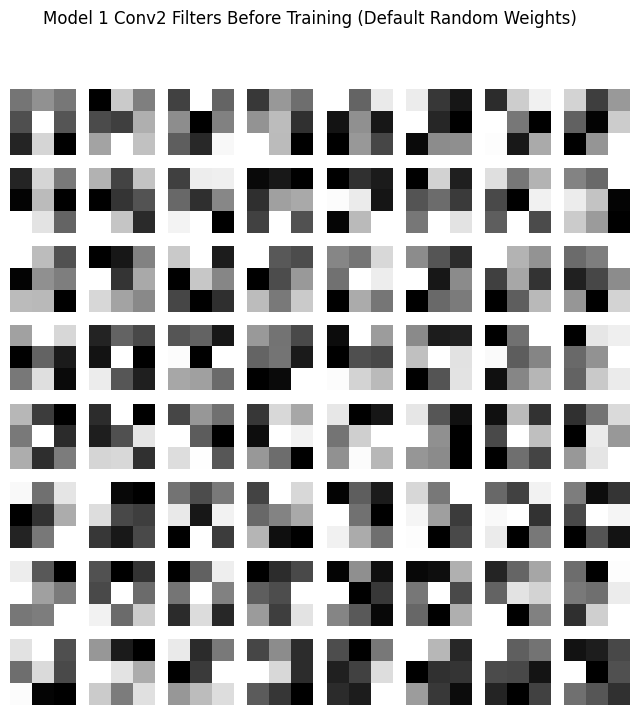

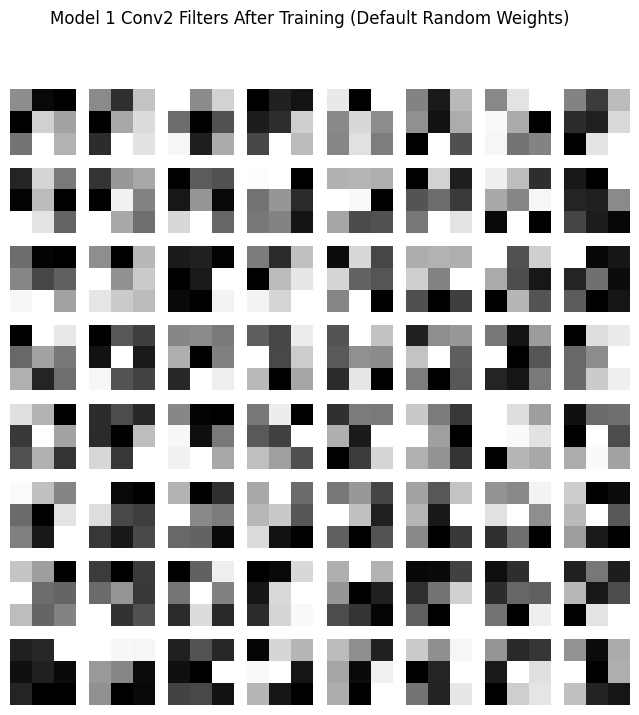

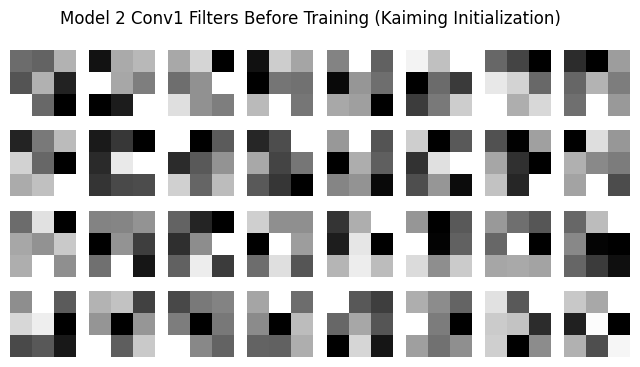

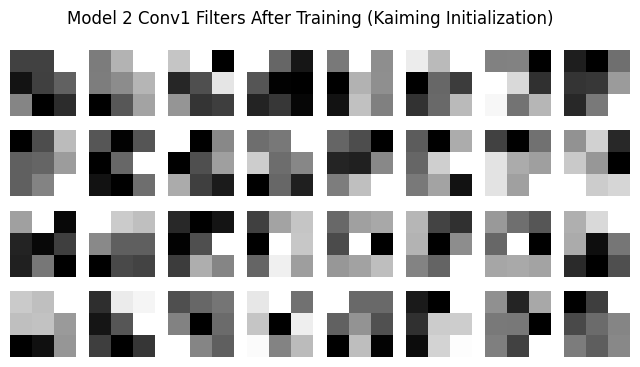

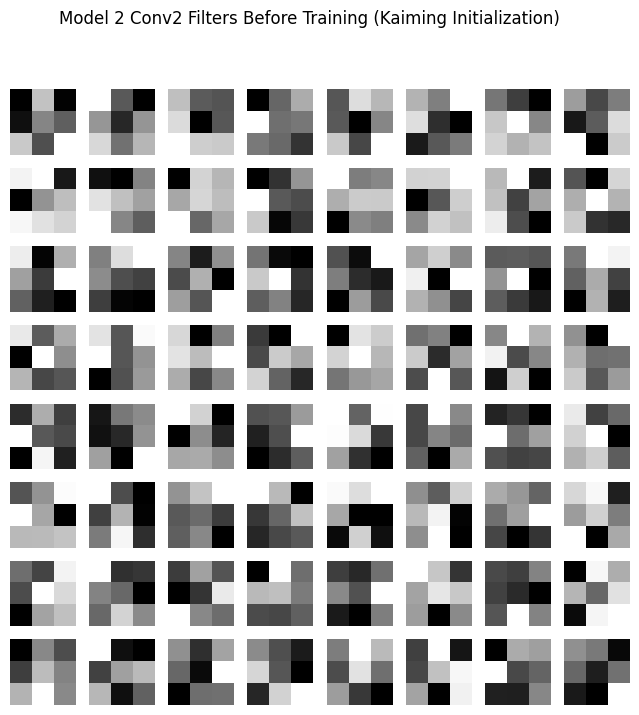

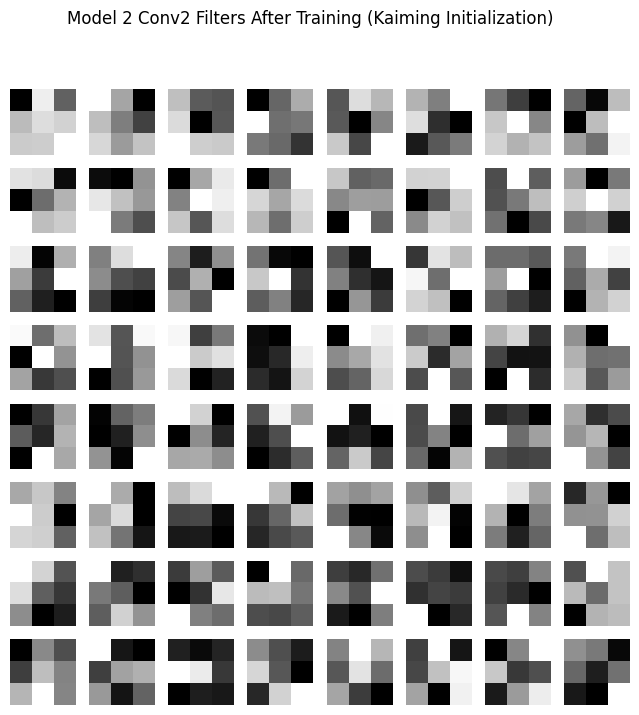

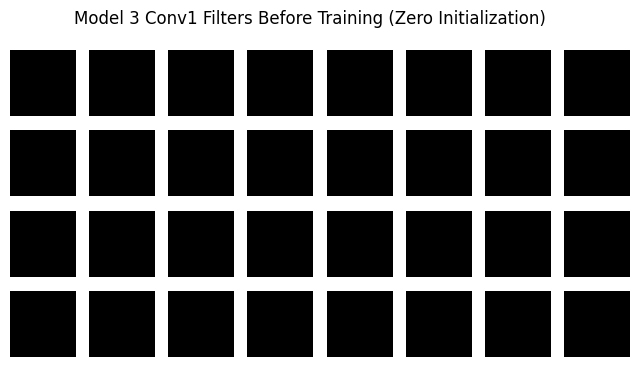

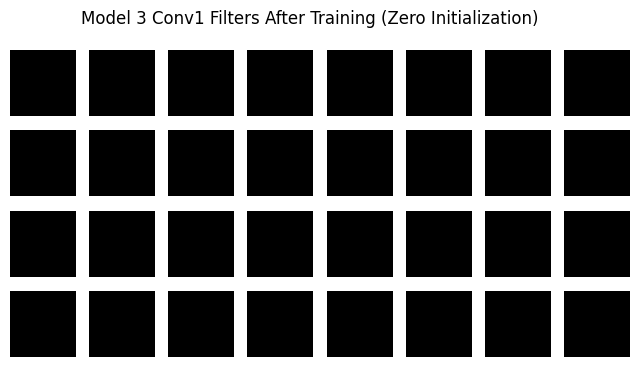

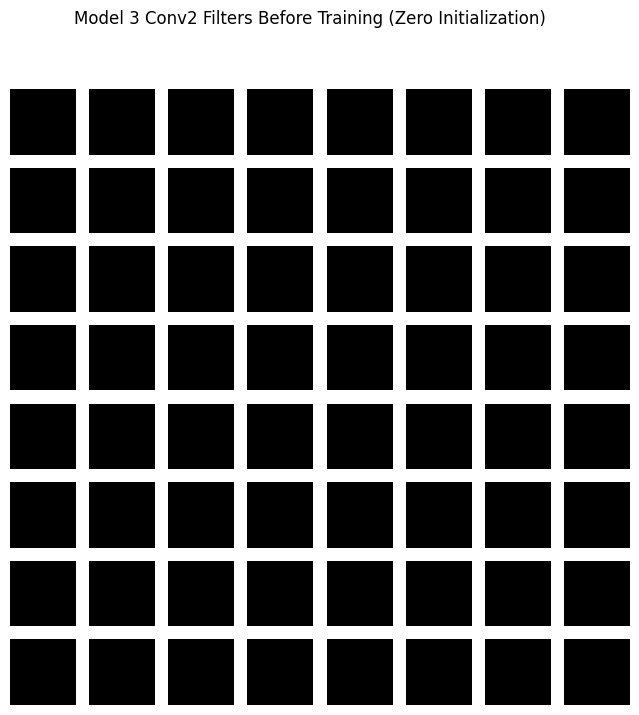

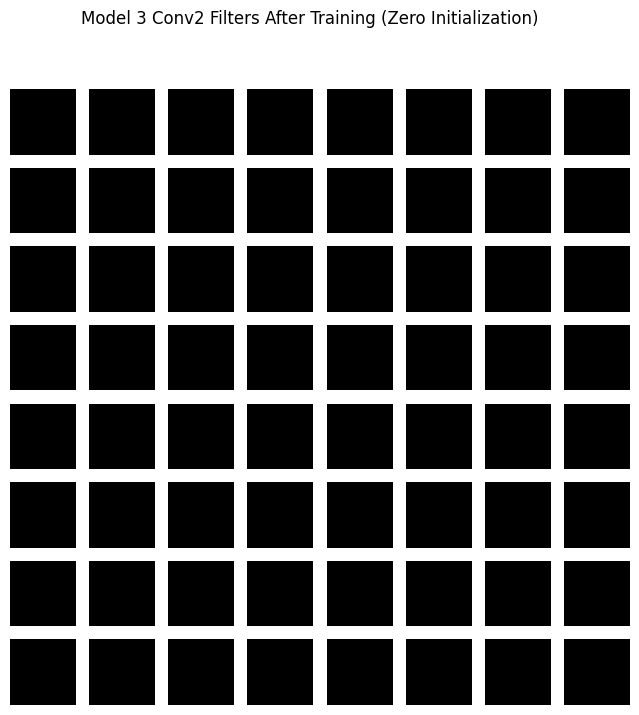

In [32]:
main_weights_comparison(0.06)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.375082
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.283807
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.308093
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.314066
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.312432
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.300169
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.306772
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.300303
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.289710
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.289741
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.298275
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.314499
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.296410
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.279897
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.293883
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.301231
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.307777
Train Epoch

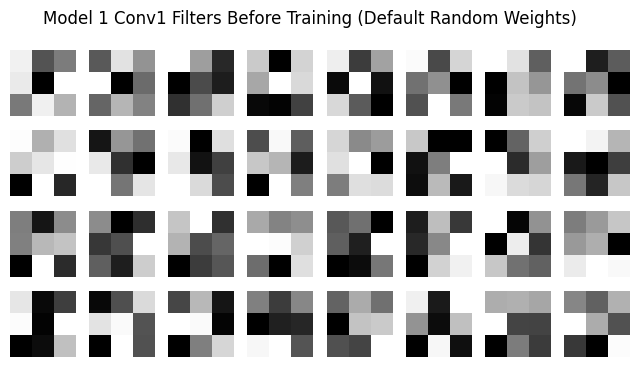

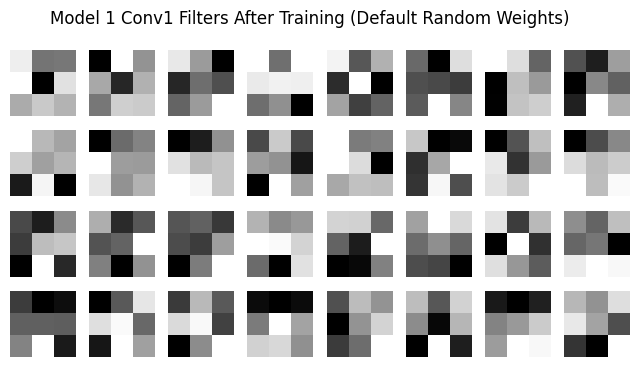

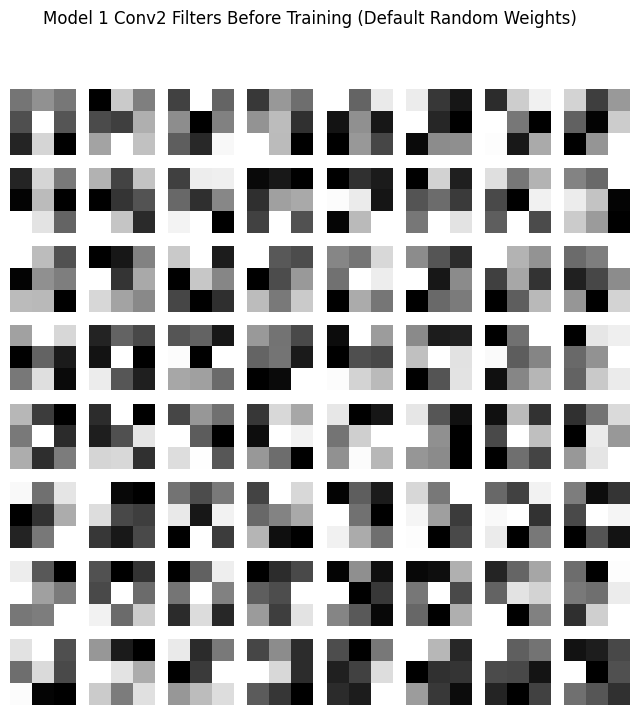

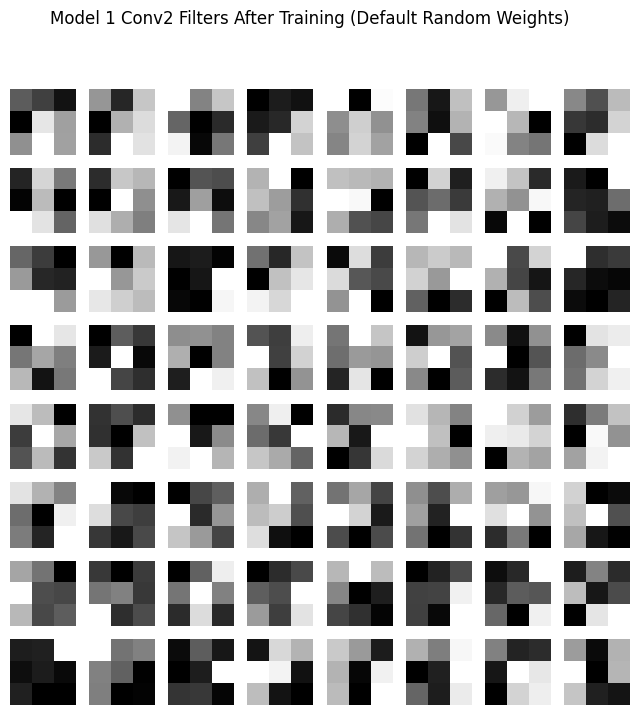

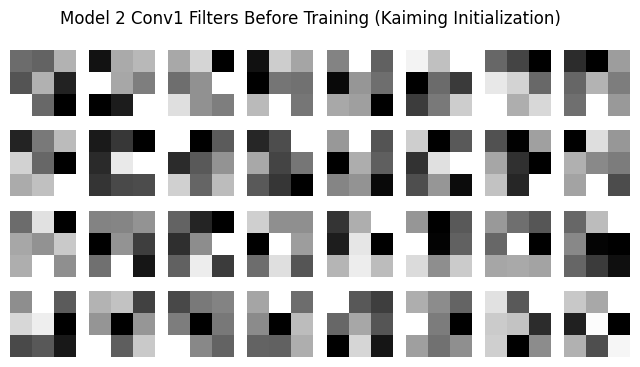

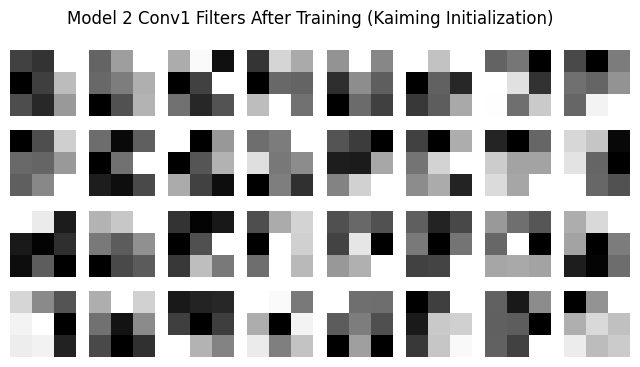

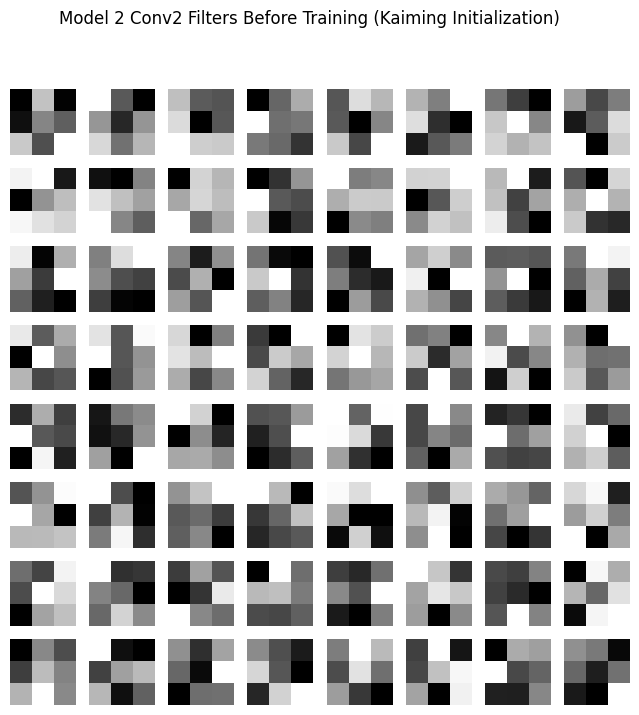

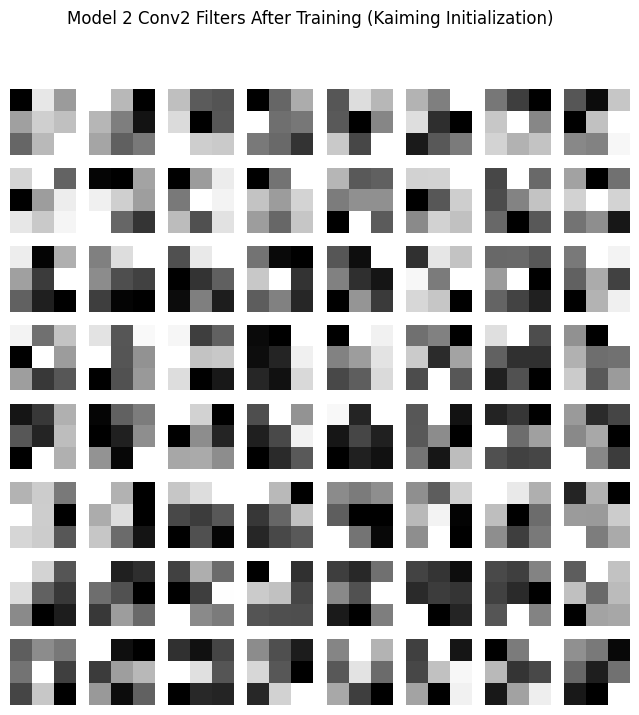

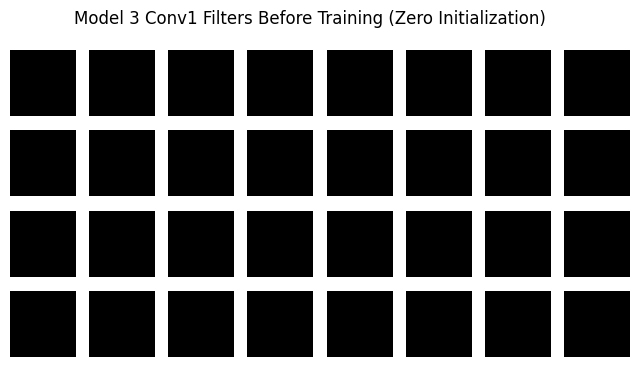

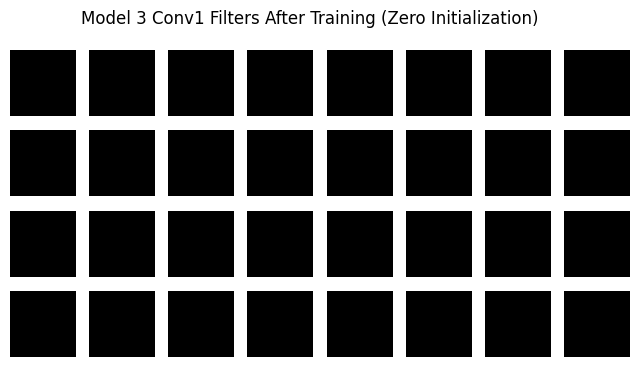

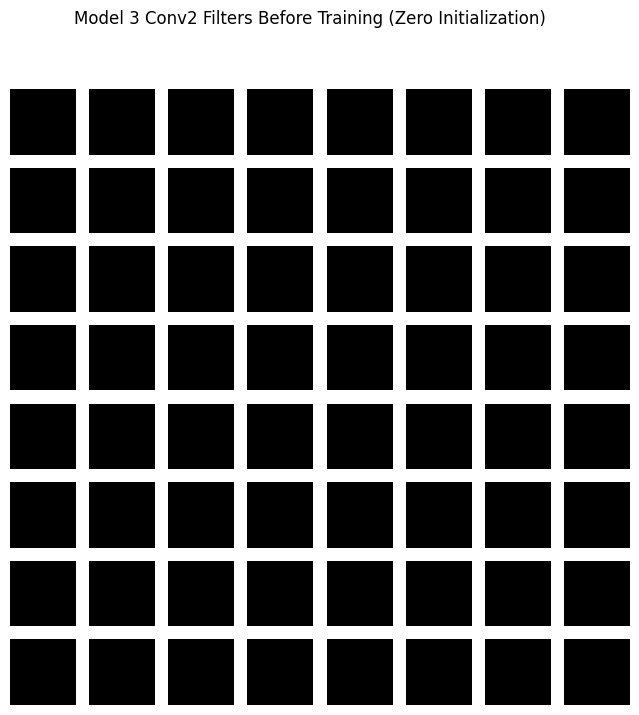

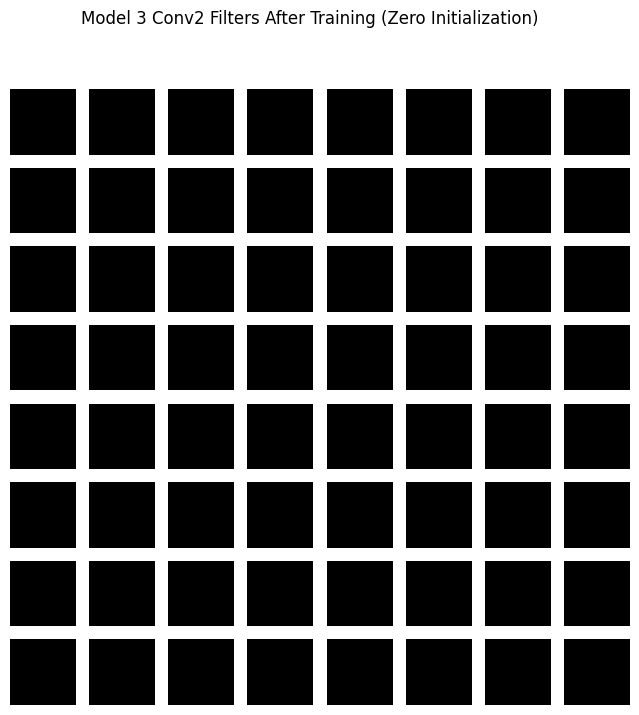

In [33]:
main_weights_comparison(0.07)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.397815
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.332293
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.273647
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.318283
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.312555
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.300740
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.311086
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.296856
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.283892
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.292622
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.299406
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.314548
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.294821
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.281008
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.293867
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.298427
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.309145
Train Epoch

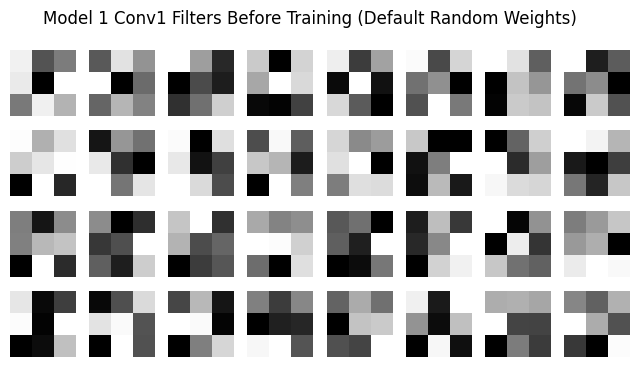

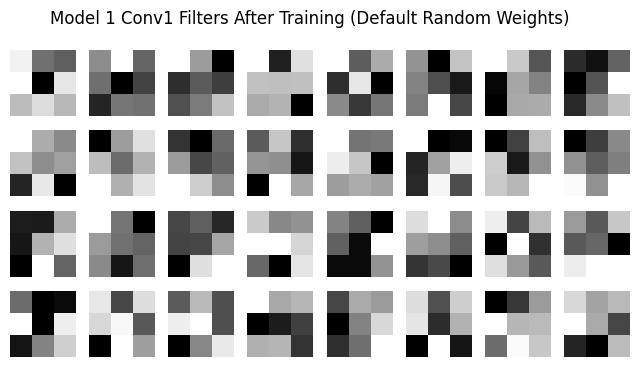

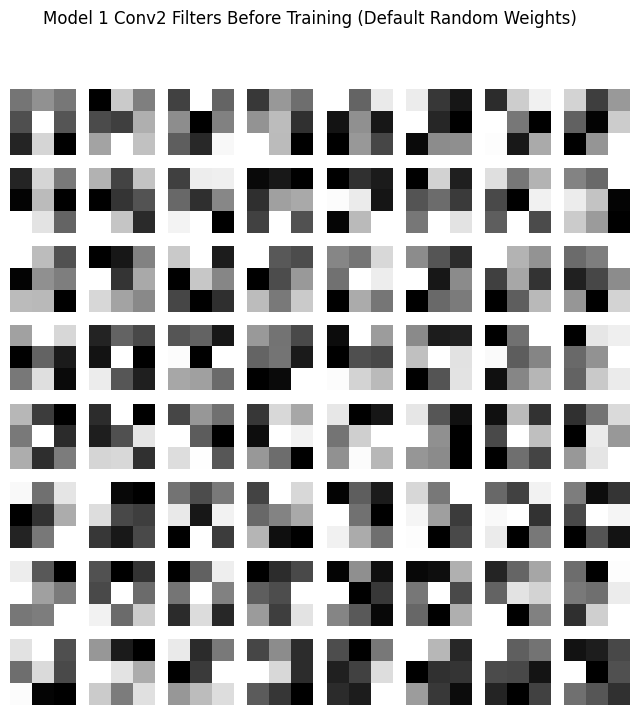

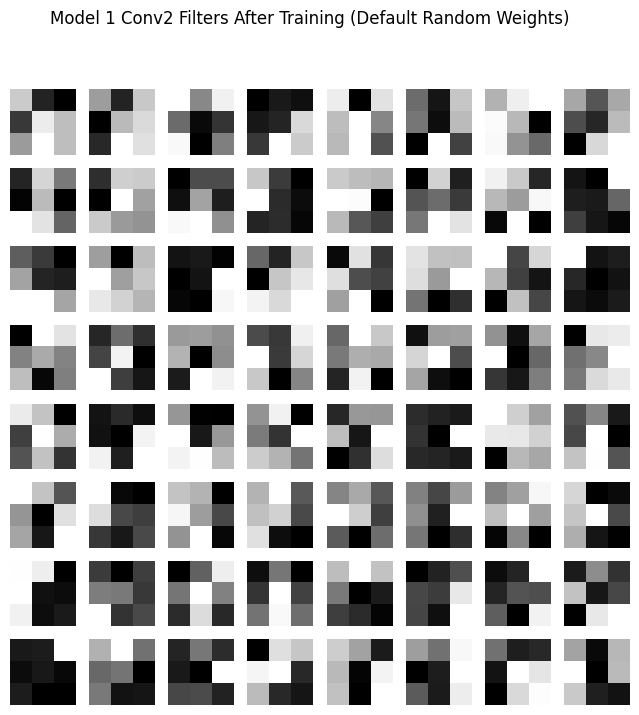

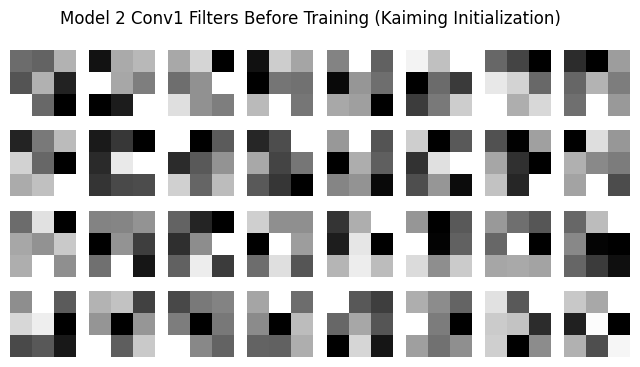

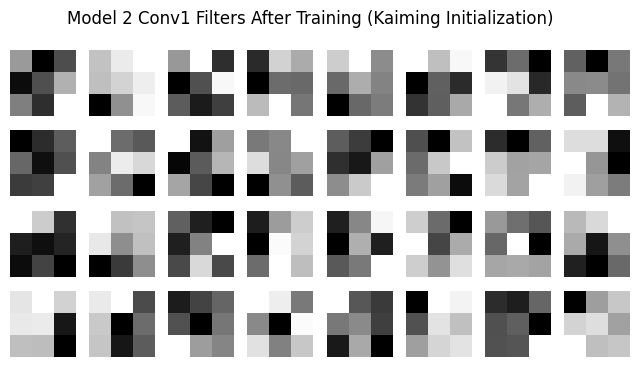

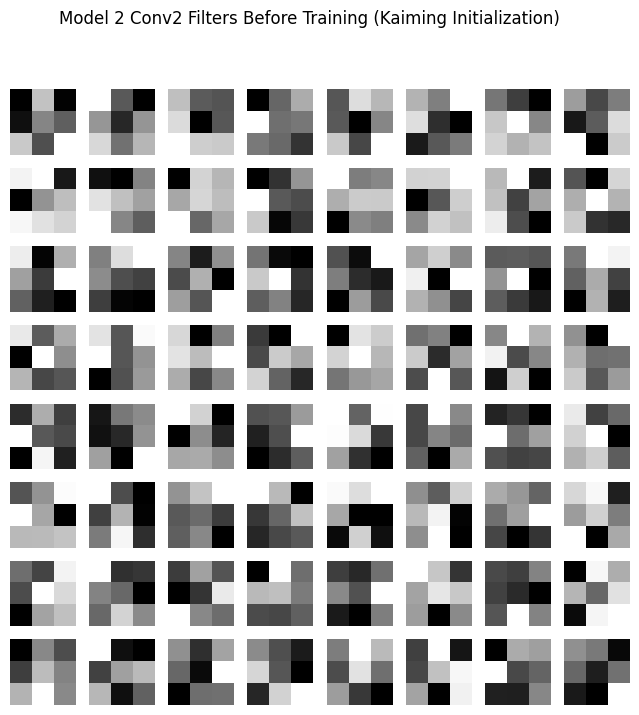

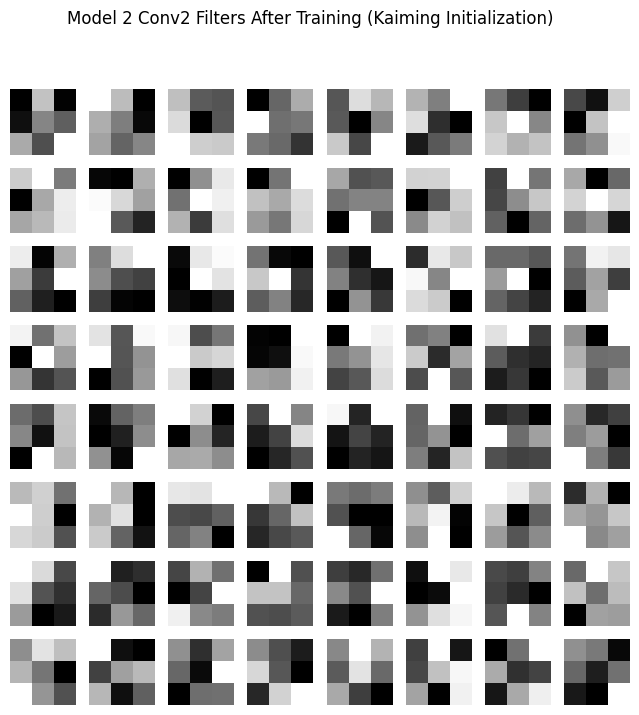

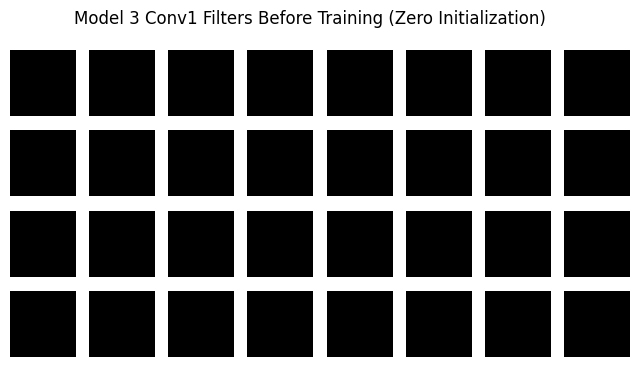

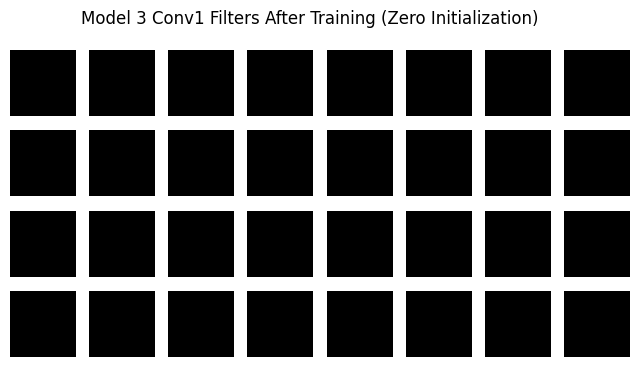

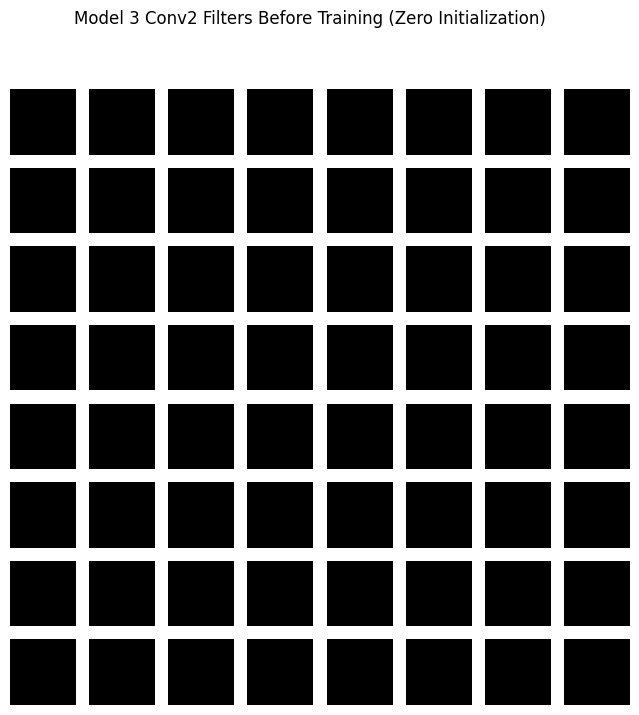

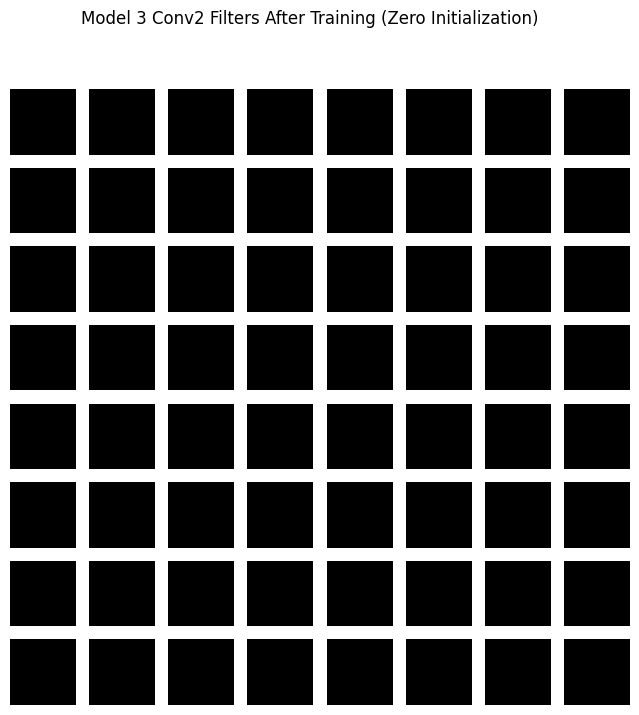

In [34]:
main_weights_comparison(0.08)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.388852
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.317669
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.307570
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.311158
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.292713
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.298918
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.306511
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.298814
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.290678
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.292052
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.300130
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.316694
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.296932
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.284717
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.295868
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.303118
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.308747
Train Epoch

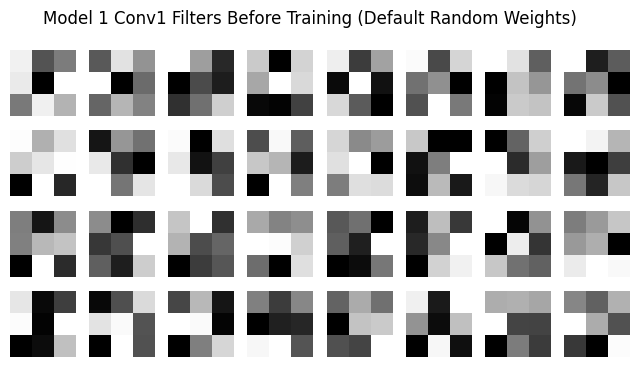

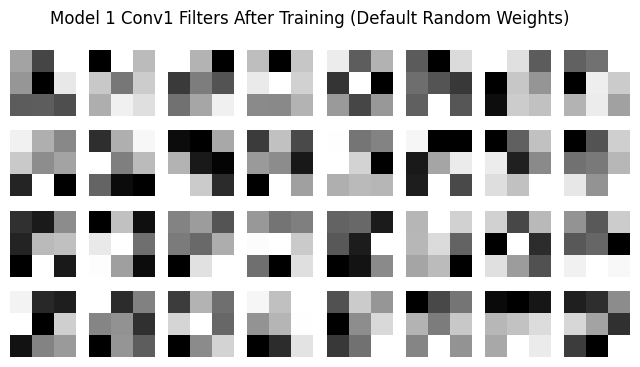

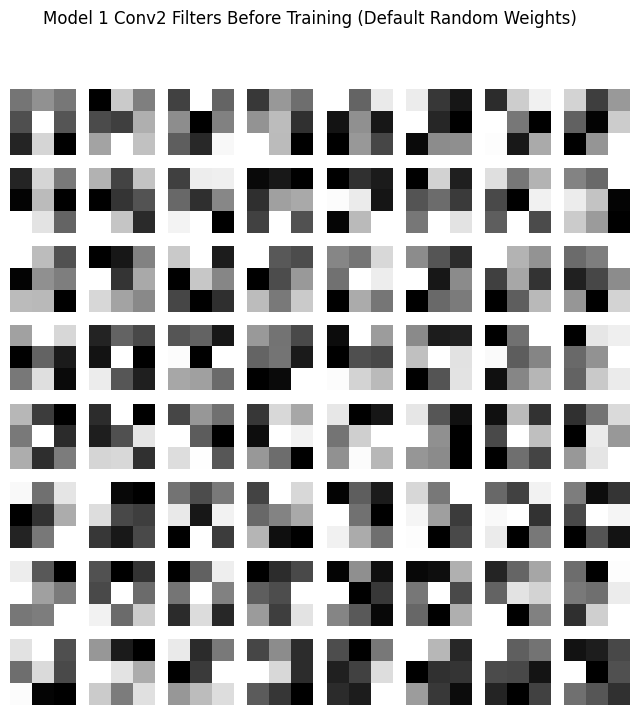

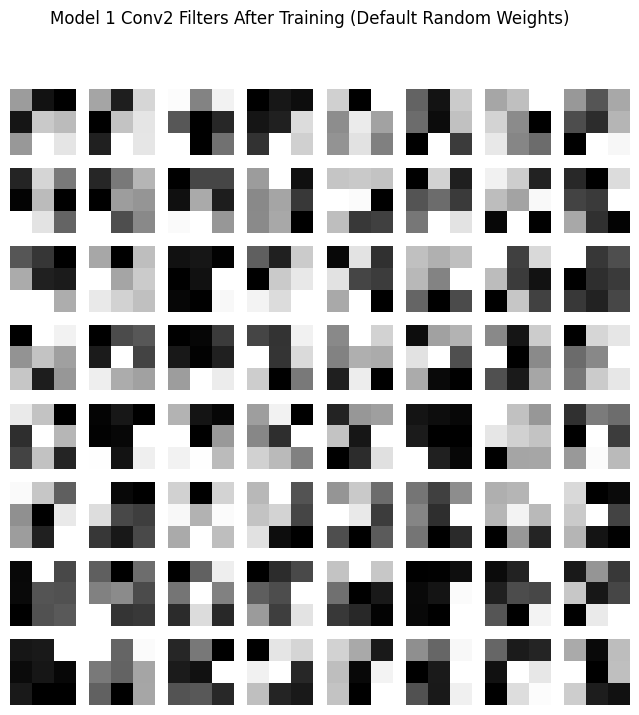

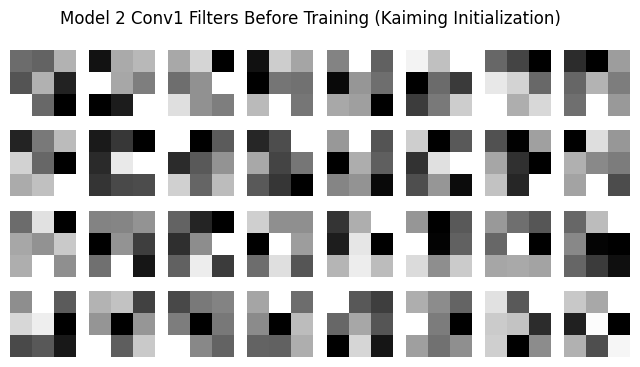

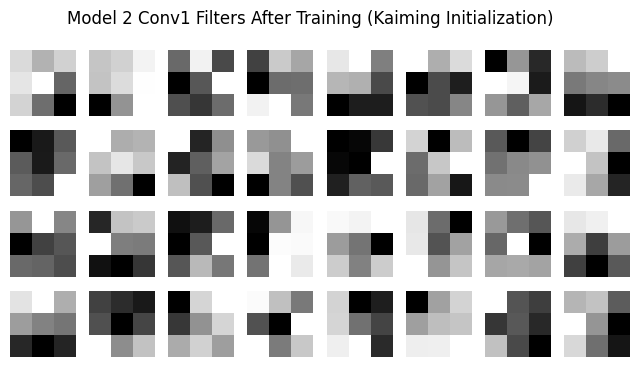

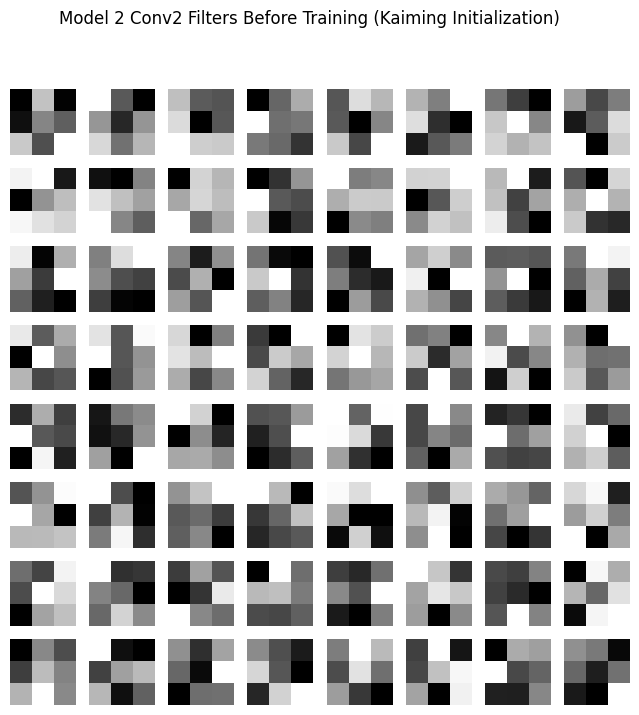

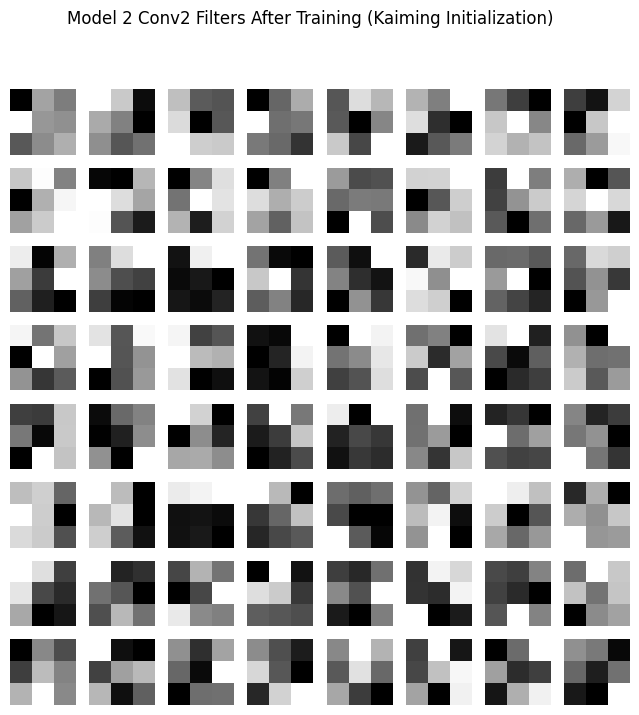

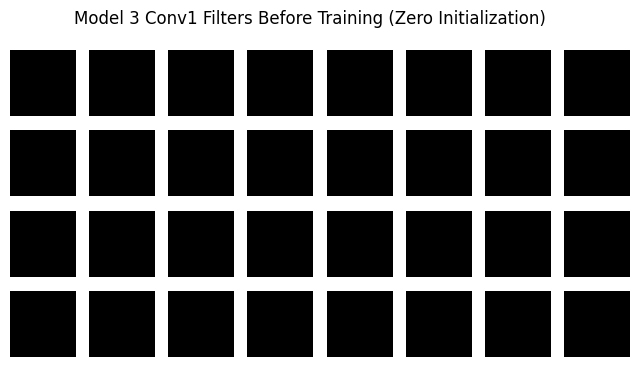

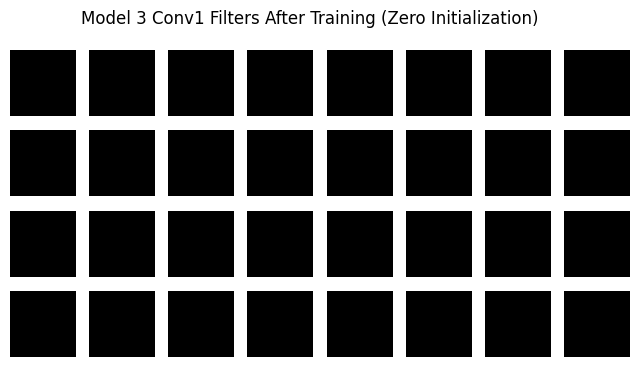

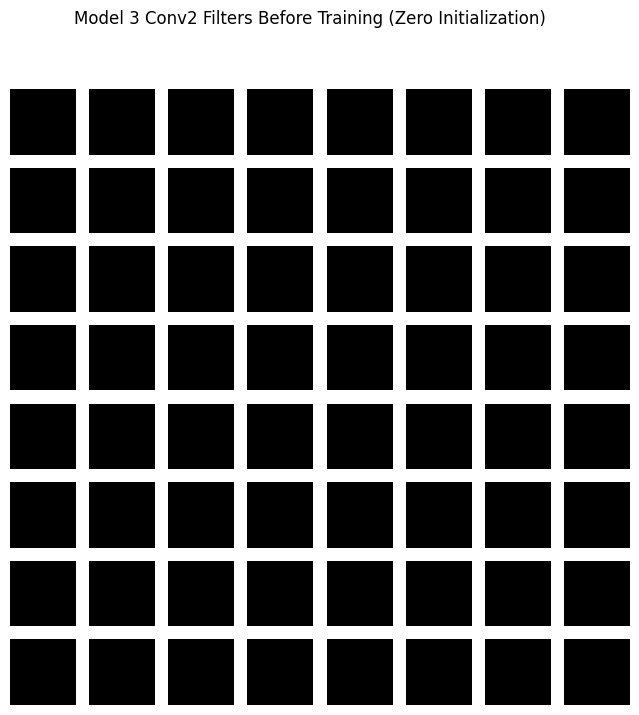

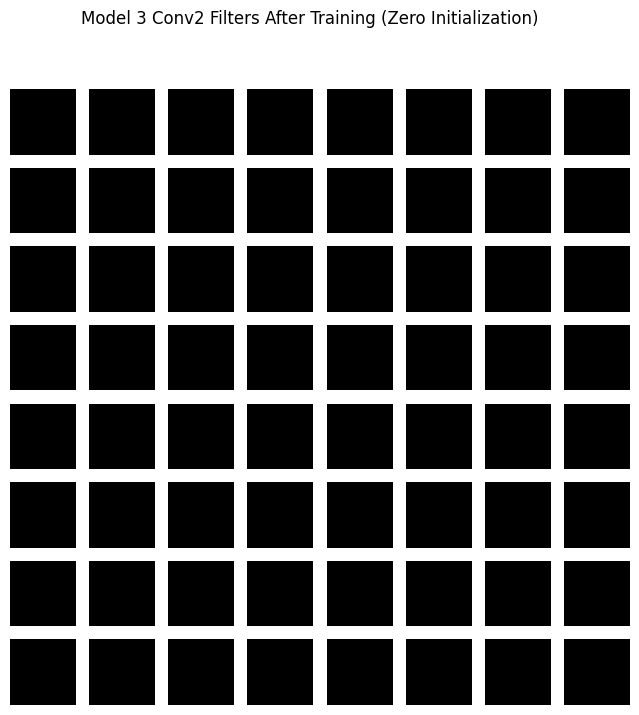

In [35]:
main_weights_comparison(0.09)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.426123
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.283681
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.309873
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.307745
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.307323
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.304810
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.311701
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.297063
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.293850
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.301366
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.309996
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.315312
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.300414
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.297065
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.306565
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.312051
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.308500
Train Epoch

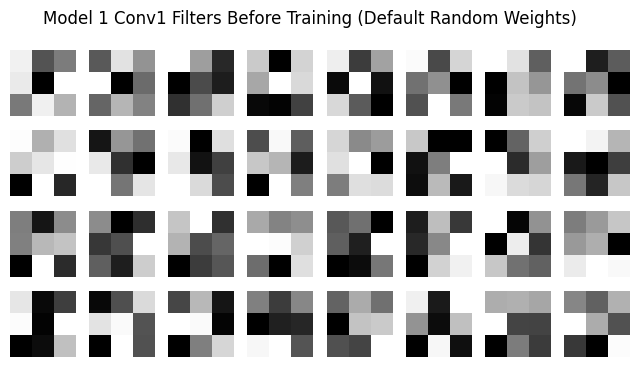

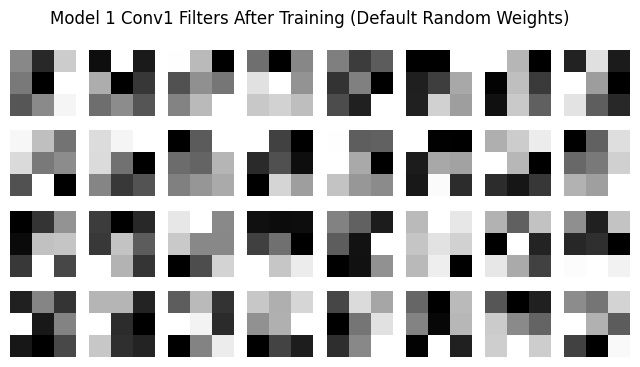

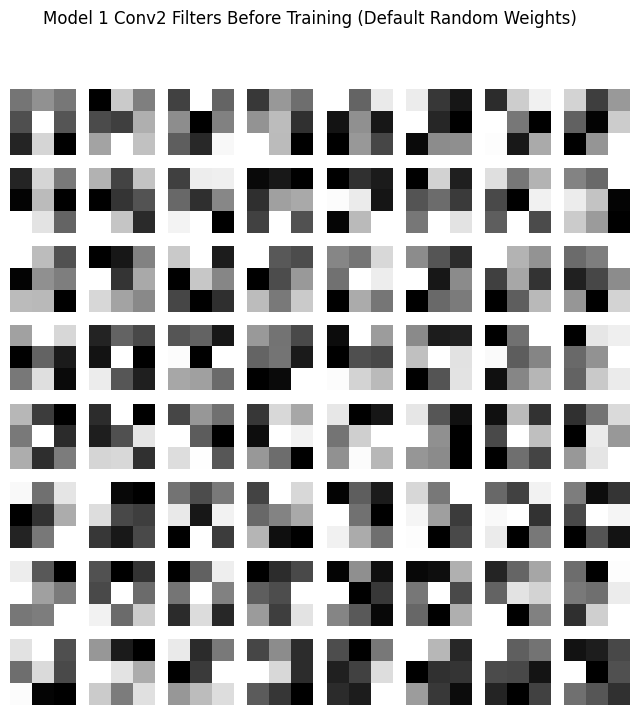

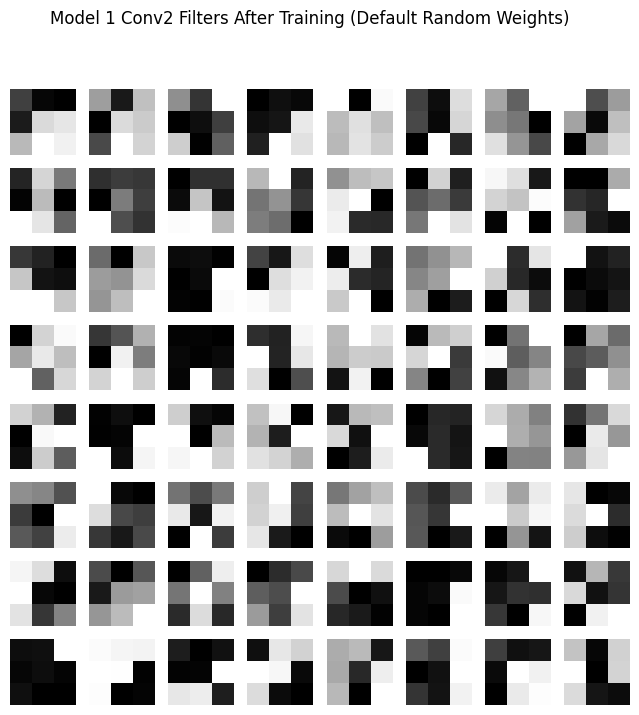

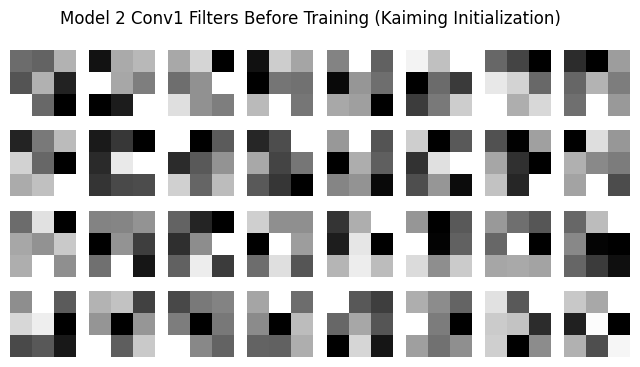

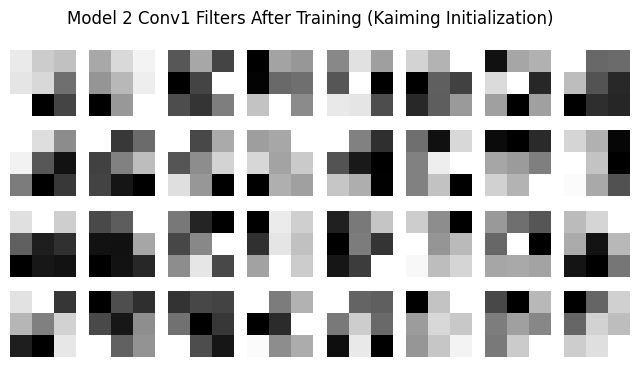

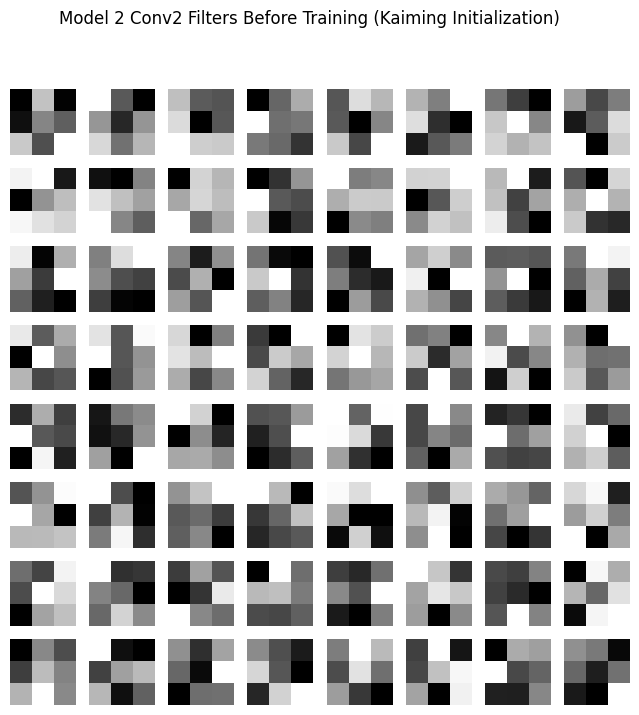

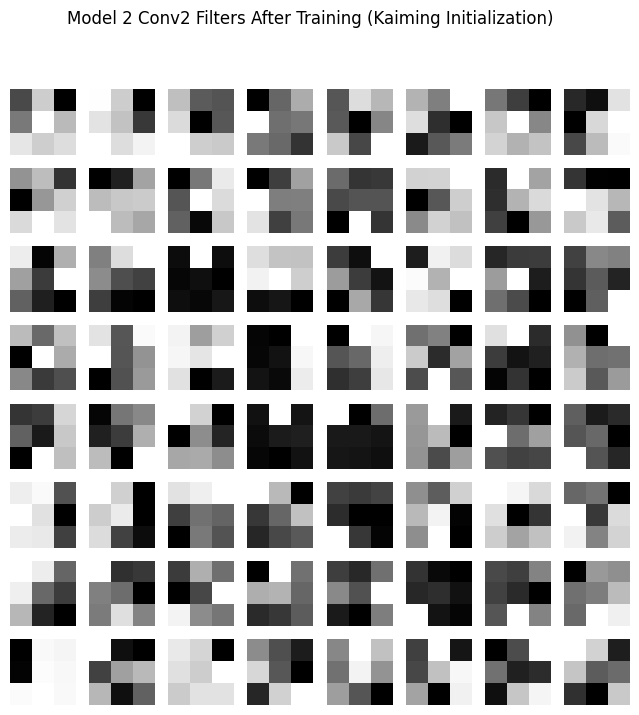

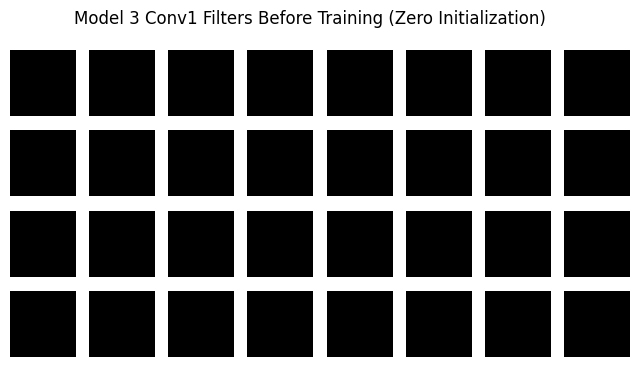

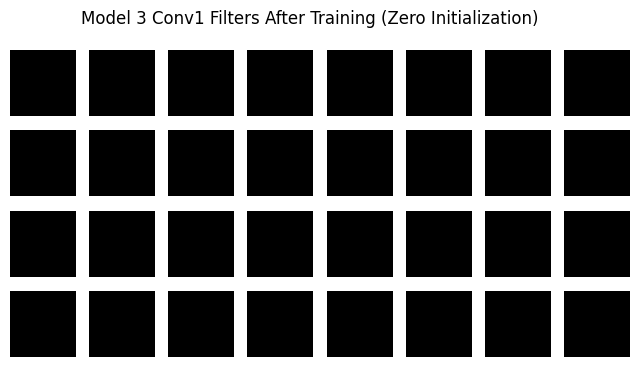

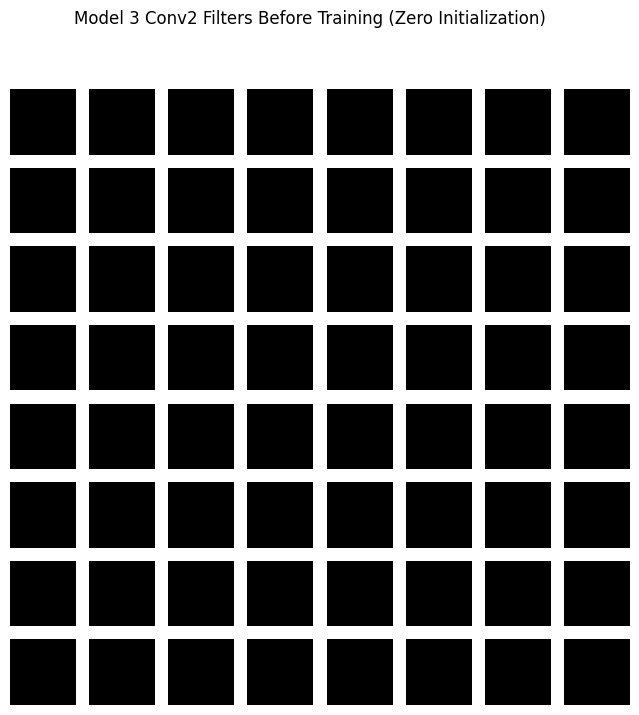

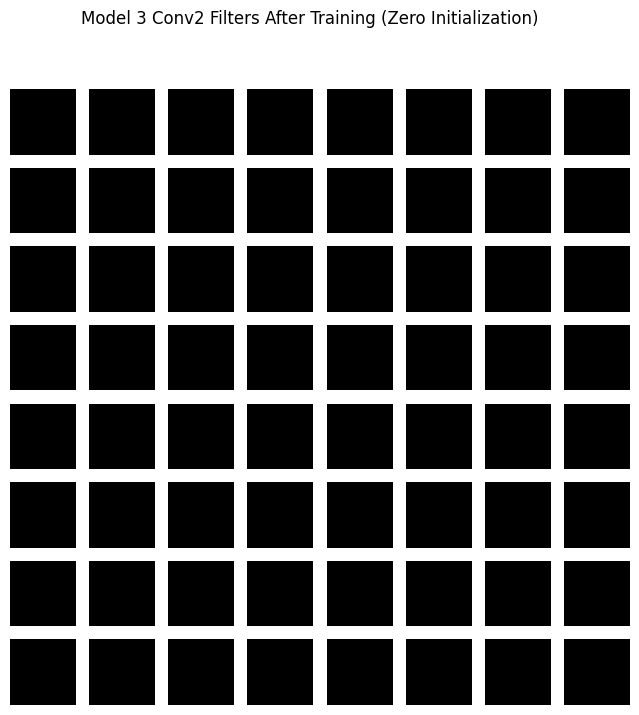

In [36]:
main_weights_comparison(0.15)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.344228
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.323396
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.317585
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.297870
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.307230
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.330225
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.312161
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.293480
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.300063
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.309004
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.328895
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.310504
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.296288
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.312262
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.317579
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.326246
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.296754
Train Epoch

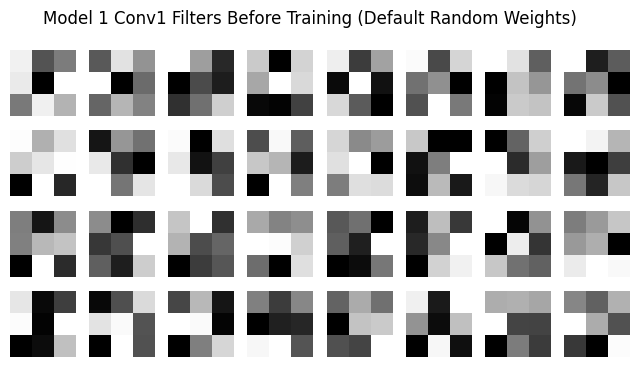

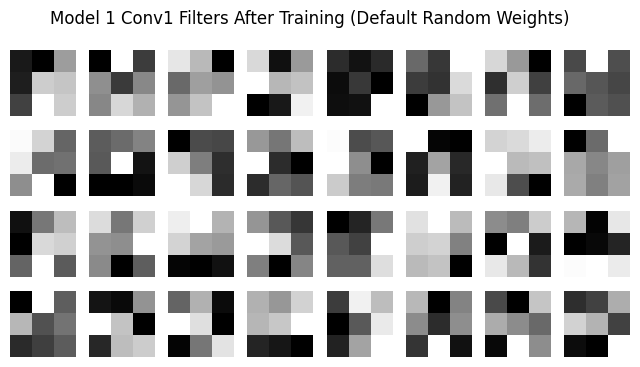

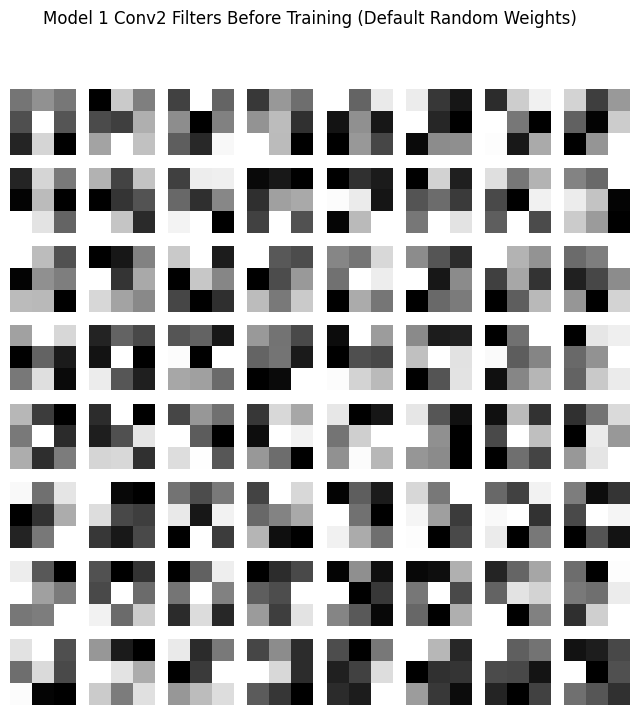

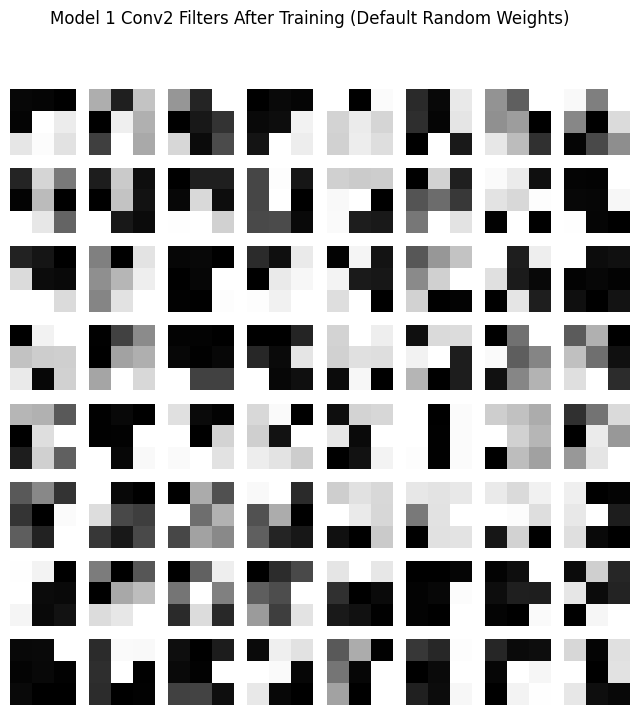

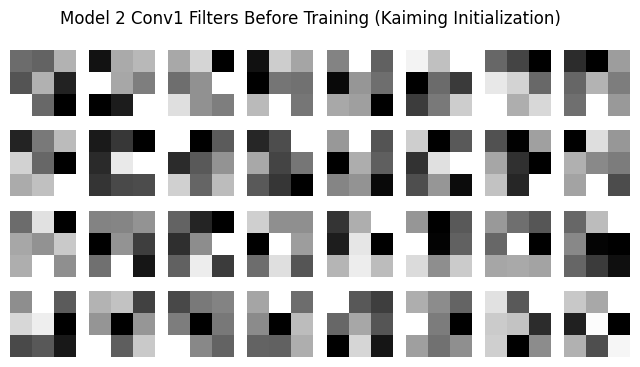

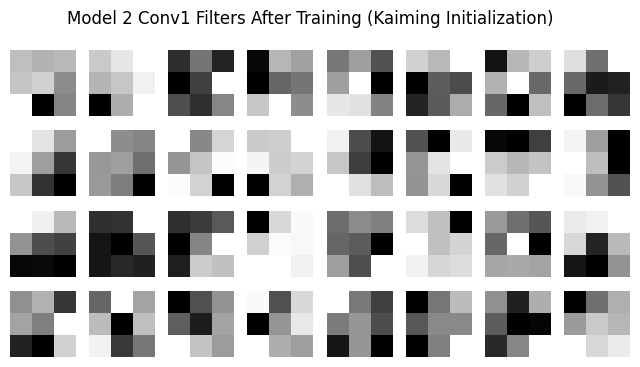

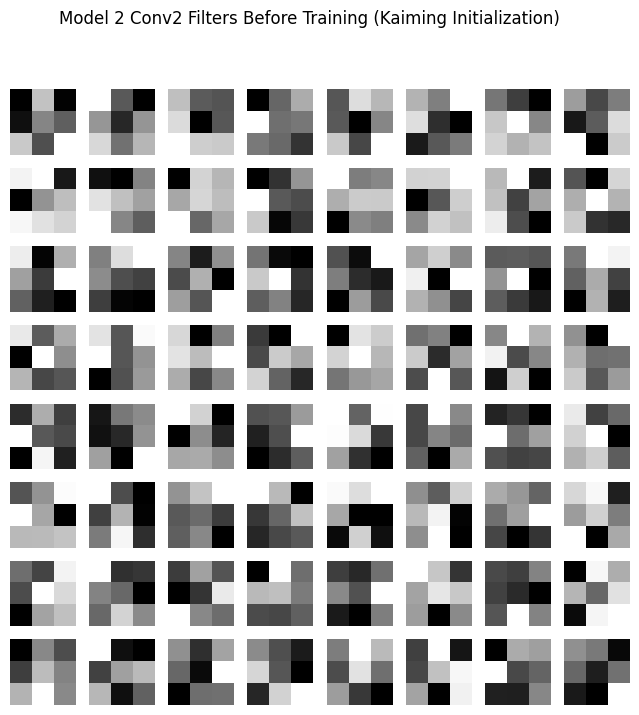

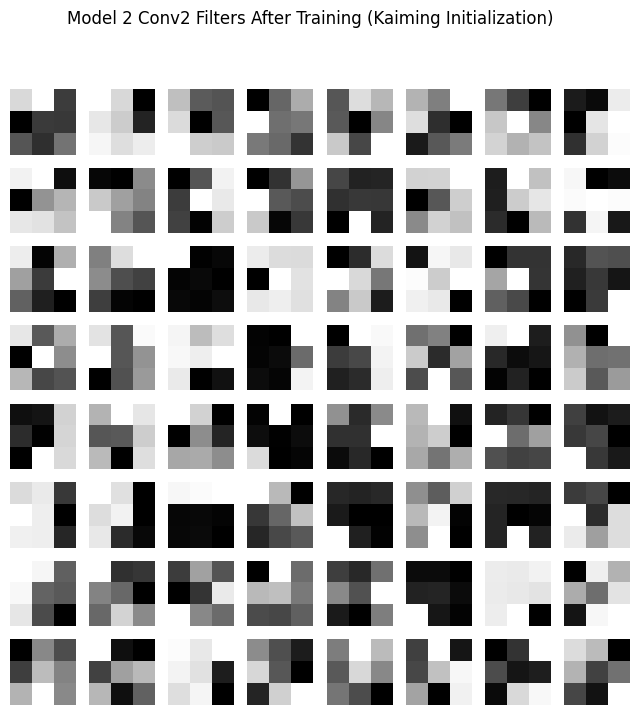

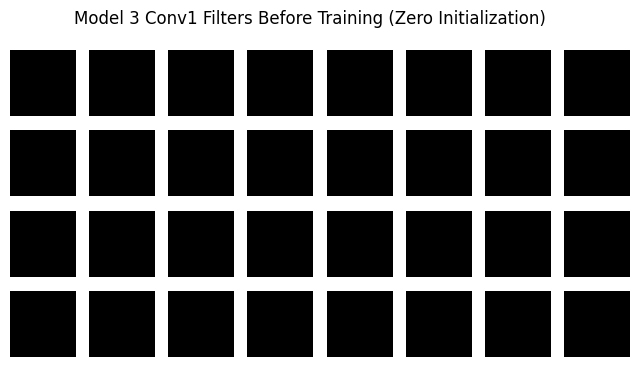

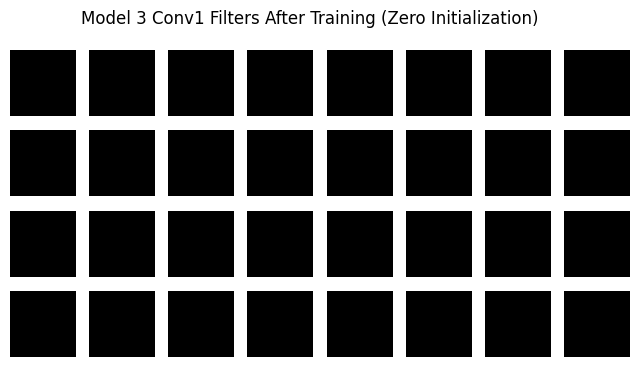

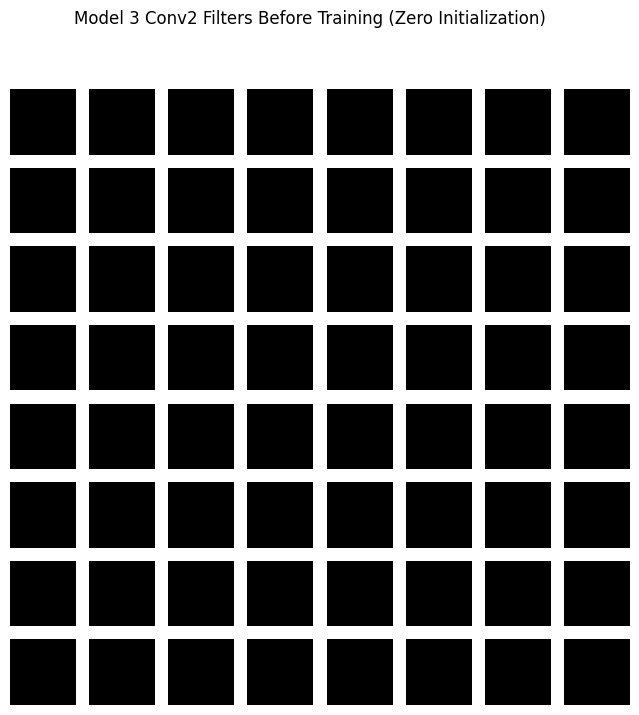

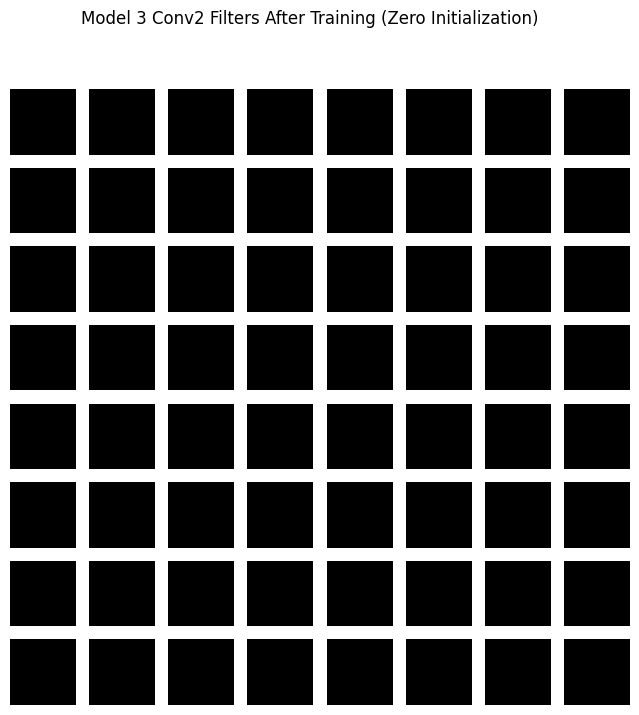

In [37]:
main_weights_comparison(0.25)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.498430
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.387962
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.327869
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.309820
Train Epoch: 1 [3200/60000 (5%)]	Loss: 9.860057
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.331128
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.310270
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.292571
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.308746
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.314597
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.349654
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.321150
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.289210
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.308042
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.314590
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.349882
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.296982
Train Epoch

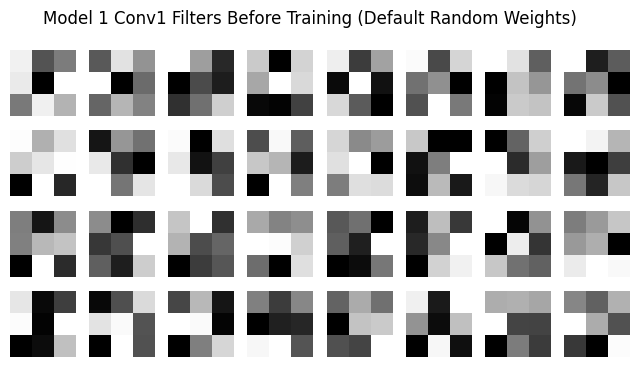

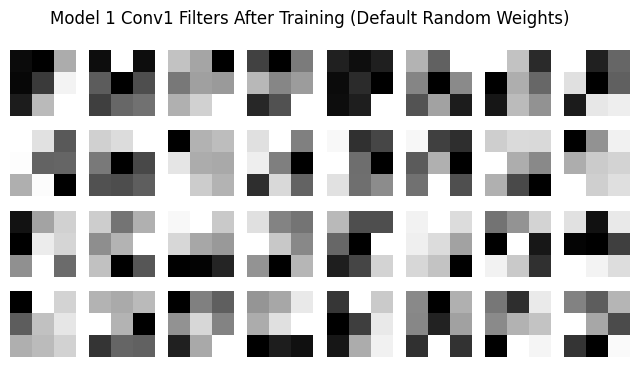

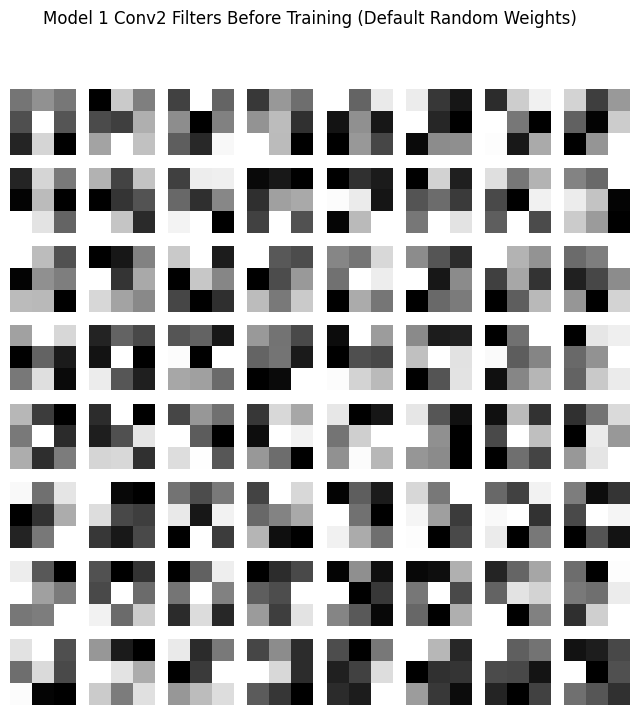

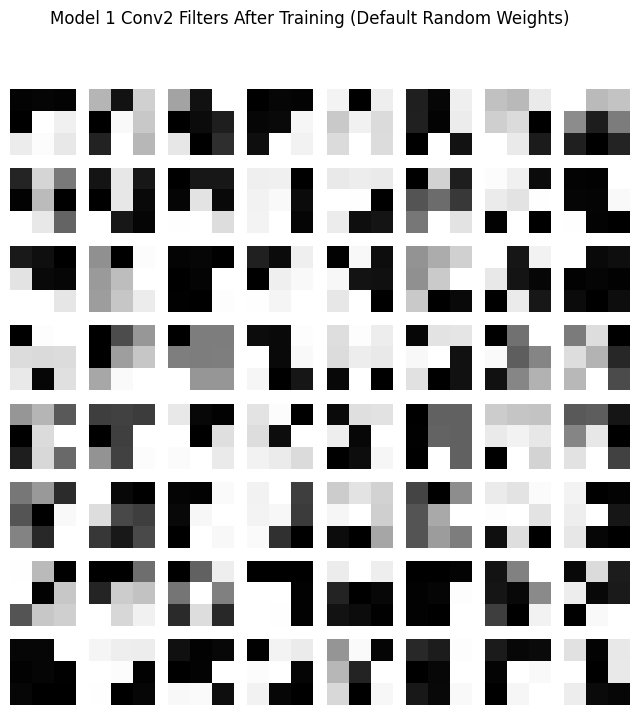

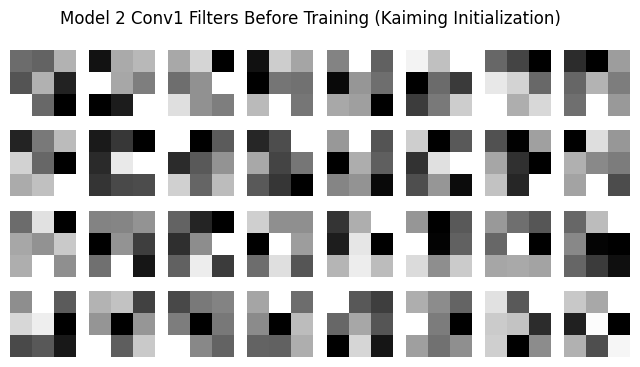

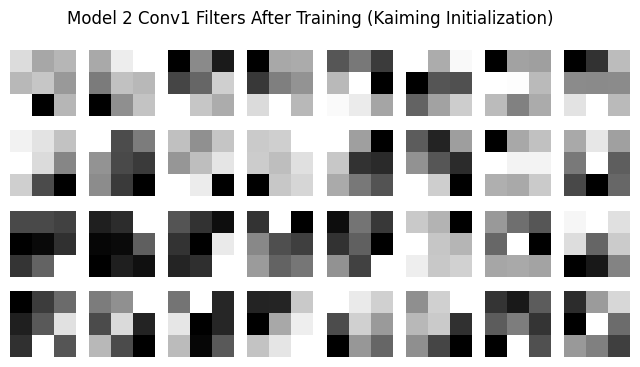

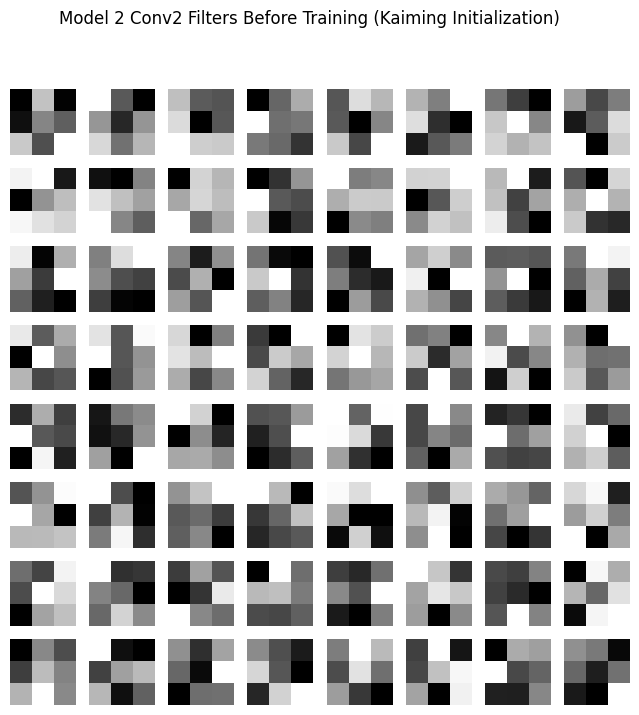

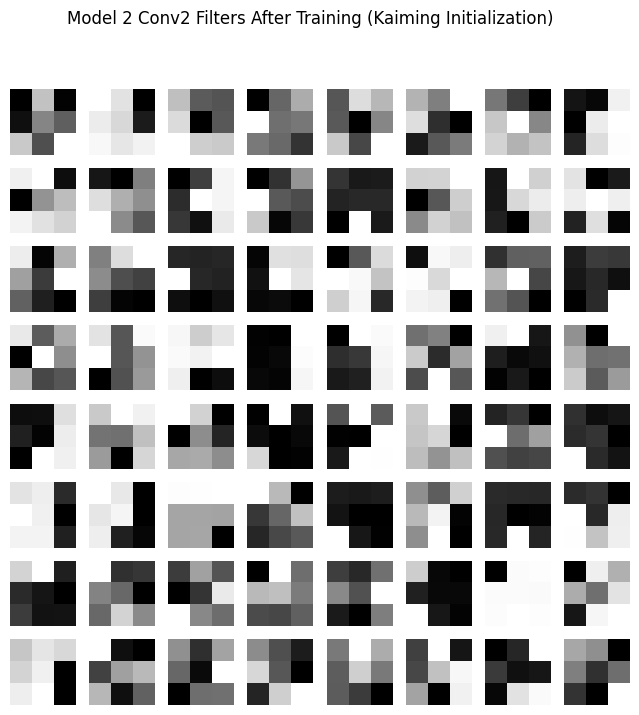

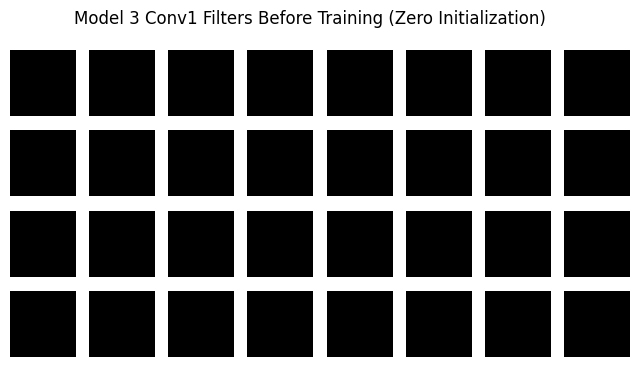

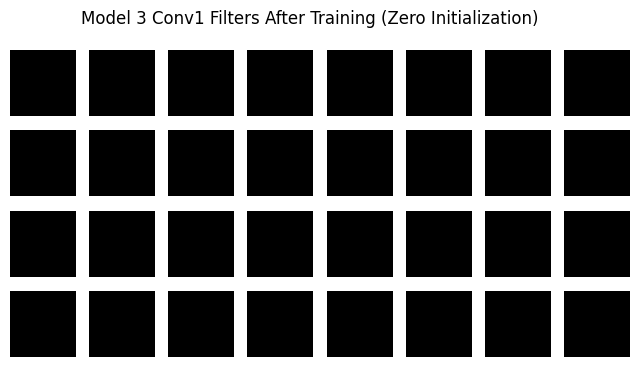

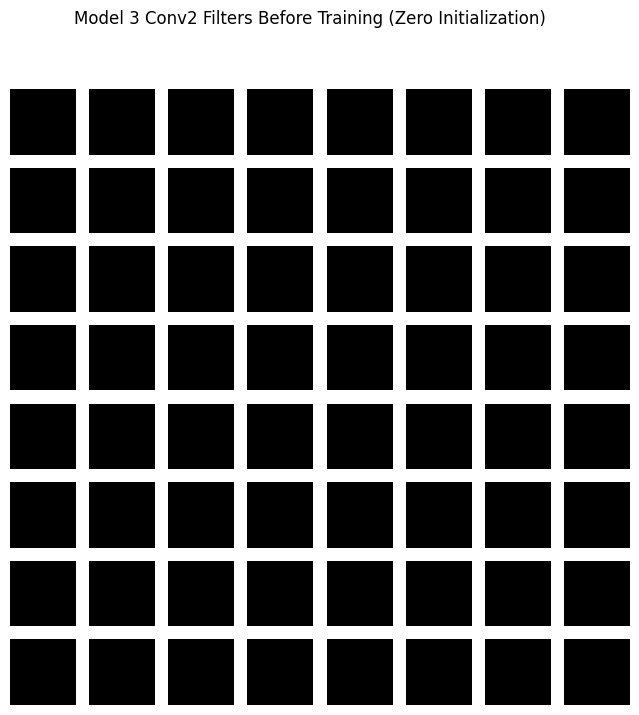

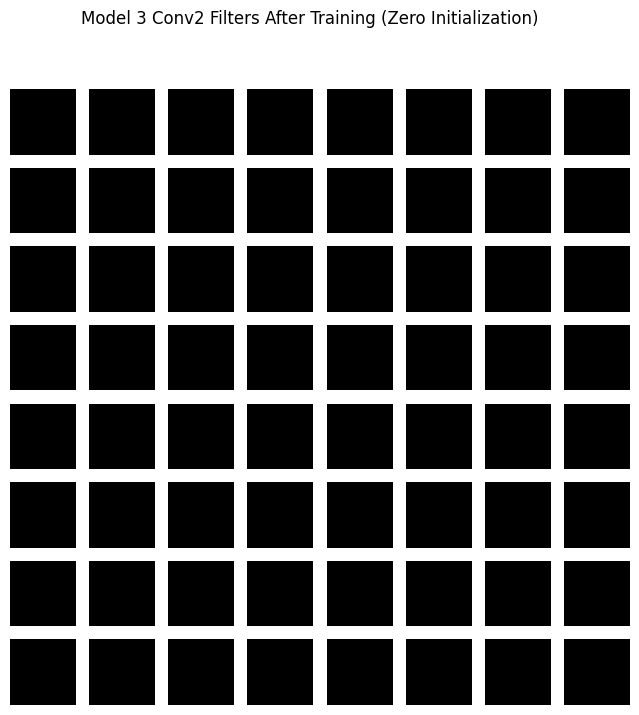

In [38]:
main_weights_comparison(0.35)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 2.528888
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.456929
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.341986
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.324971
Train Epoch: 1 [3200/60000 (5%)]	Loss: 2.332944
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.334115
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.323343
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.302137
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.326784
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.327449
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.343612
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.333632
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.292783
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.308905
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.331580
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.363428
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.298066
Train Epoch

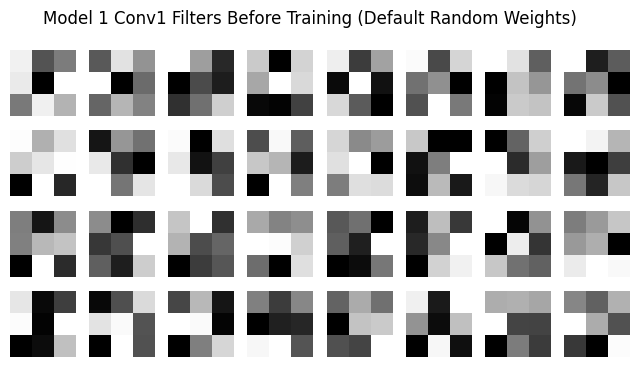

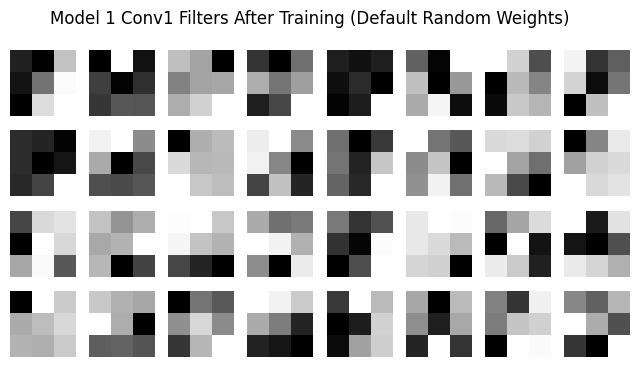

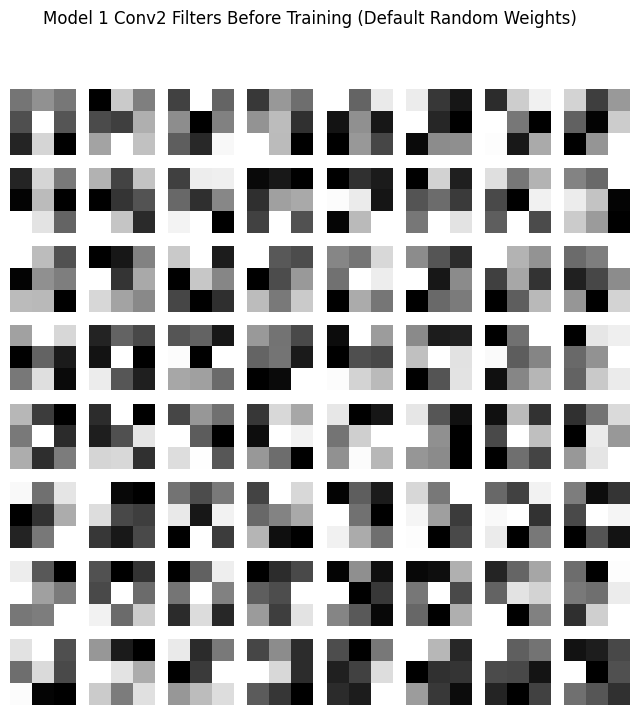

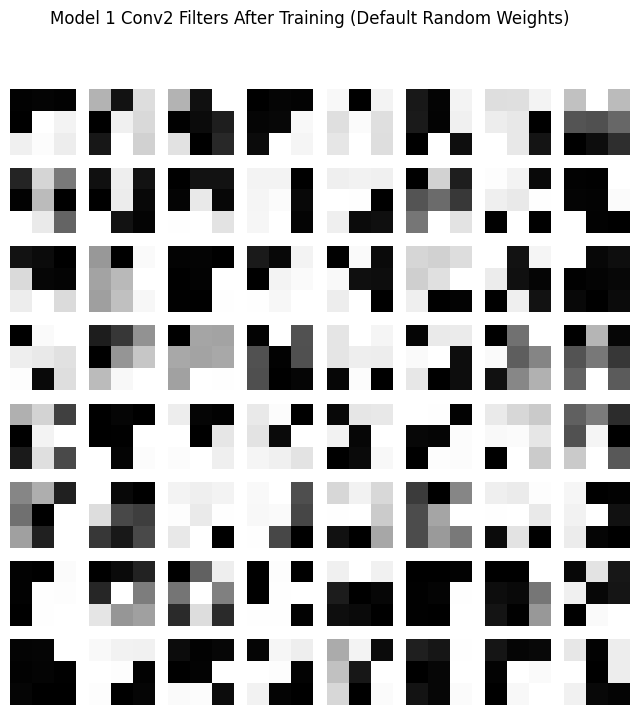

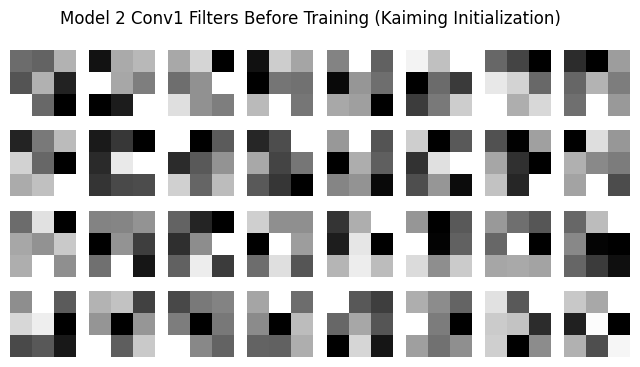

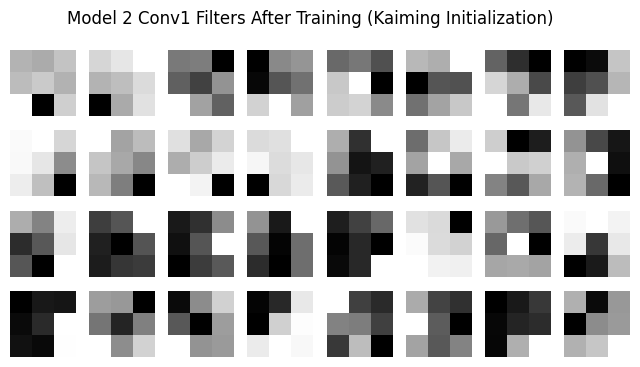

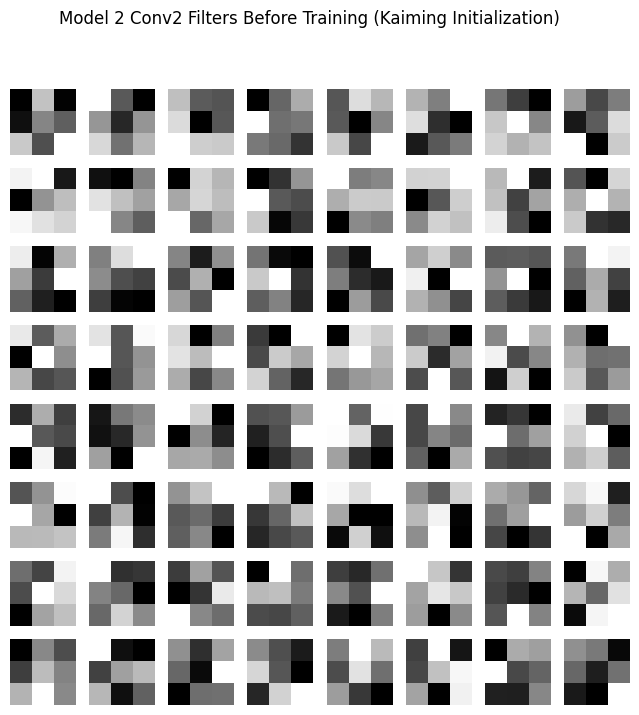

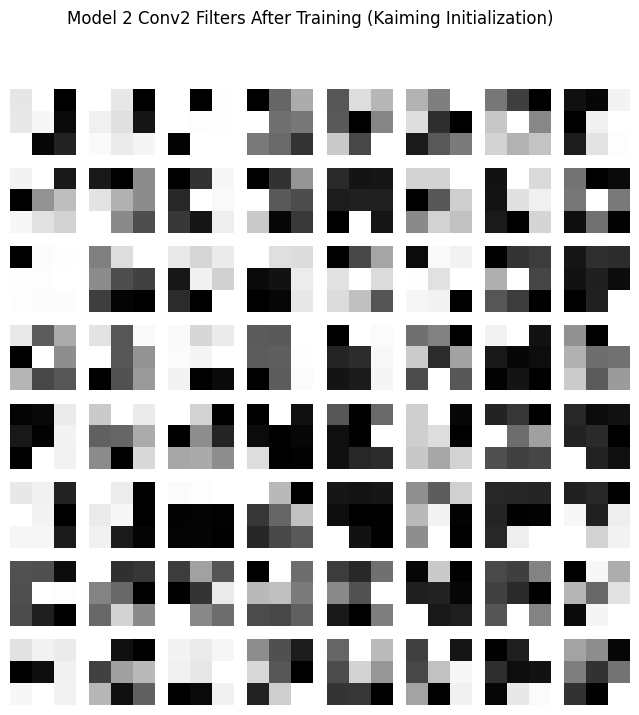

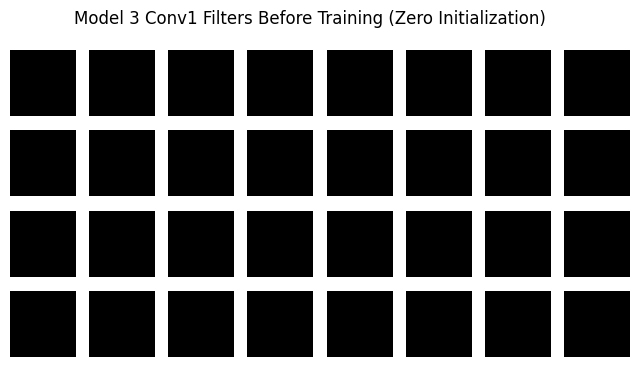

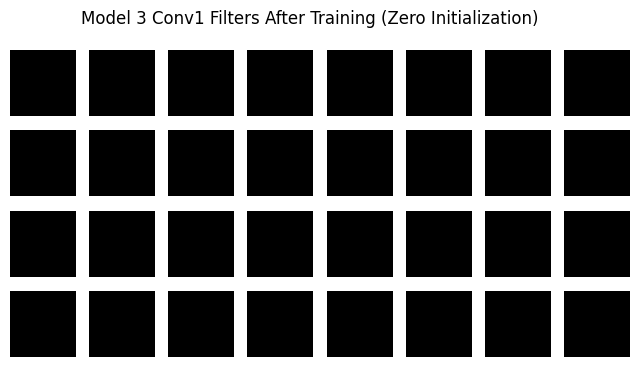

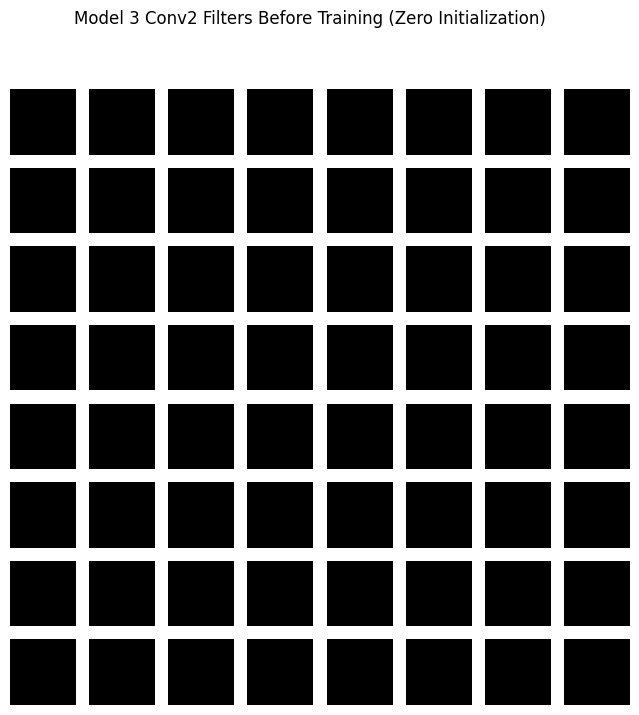

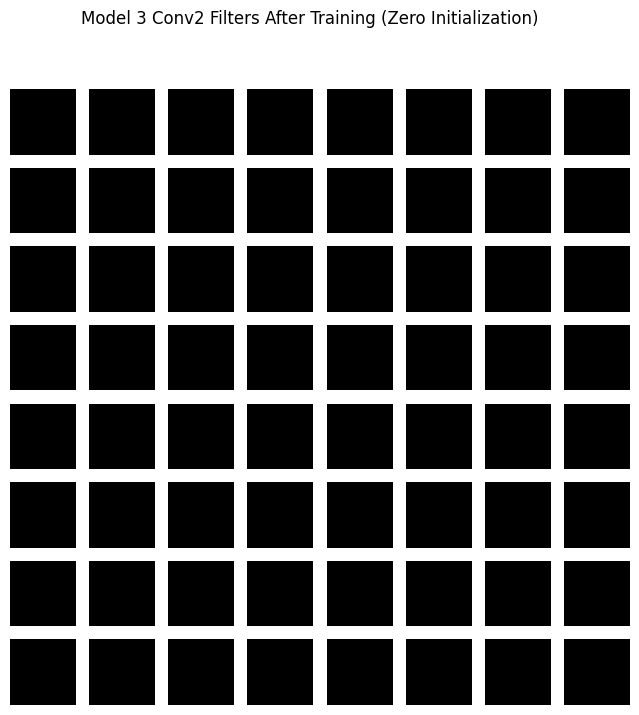

In [39]:
main_weights_comparison(0.45)


--- Training with Different Weight Initializations ---


--- 1. Weights Initialized with Default Random Weights ---

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.329474
Train Epoch: 1 [640/60000 (1%)]	Loss: 3.189932
Train Epoch: 1 [1280/60000 (2%)]	Loss: 2.574702
Train Epoch: 1 [1920/60000 (3%)]	Loss: 2.353033
Train Epoch: 1 [2560/60000 (4%)]	Loss: 2.349105
Train Epoch: 1 [3200/60000 (5%)]	Loss: 36.301487
Train Epoch: 1 [3840/60000 (6%)]	Loss: 2.332614
Train Epoch: 1 [4480/60000 (7%)]	Loss: 2.316781
Train Epoch: 1 [5120/60000 (9%)]	Loss: 2.299589
Train Epoch: 1 [5760/60000 (10%)]	Loss: 2.319196
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.327991
Train Epoch: 1 [7040/60000 (12%)]	Loss: 2.341394
Train Epoch: 1 [7680/60000 (13%)]	Loss: 2.340858
Train Epoch: 1 [8320/60000 (14%)]	Loss: 2.297823
Train Epoch: 1 [8960/60000 (15%)]	Loss: 2.324621
Train Epoch: 1 [9600/60000 (16%)]	Loss: 2.357291
Train Epoch: 1 [10240/60000 (17%)]	Loss: 2.369011
Train Epoch: 1 [10880/60000 (18%)]	Loss: 2.296149
Train Epoc

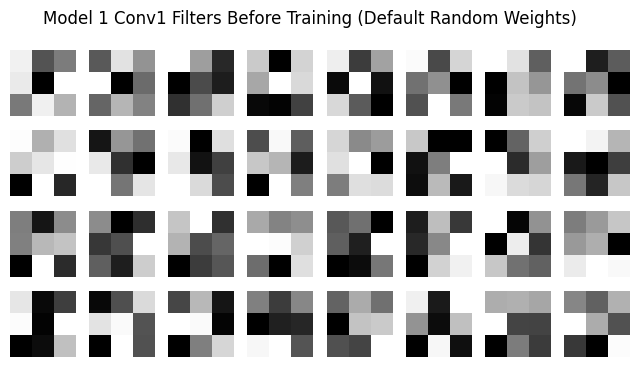

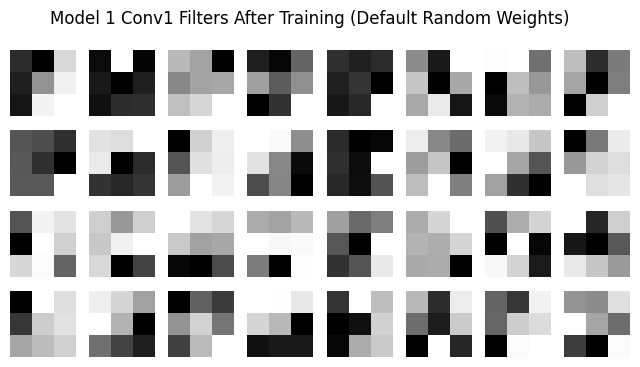

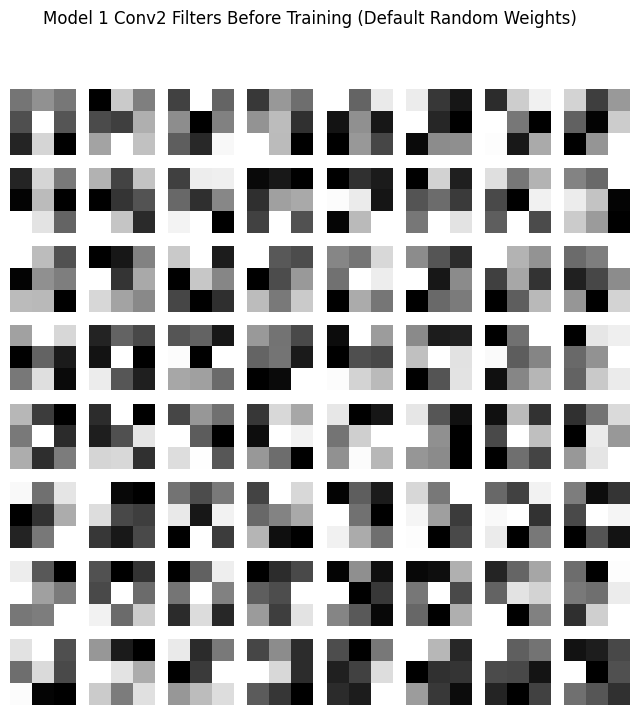

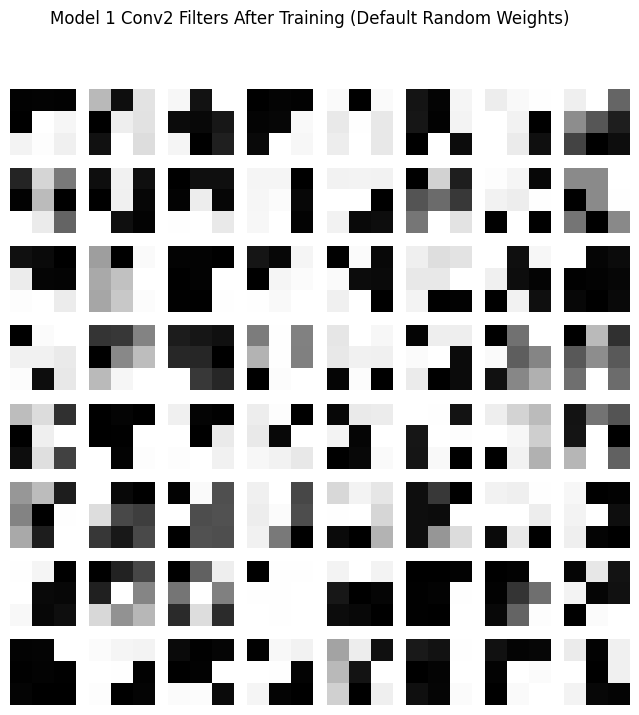

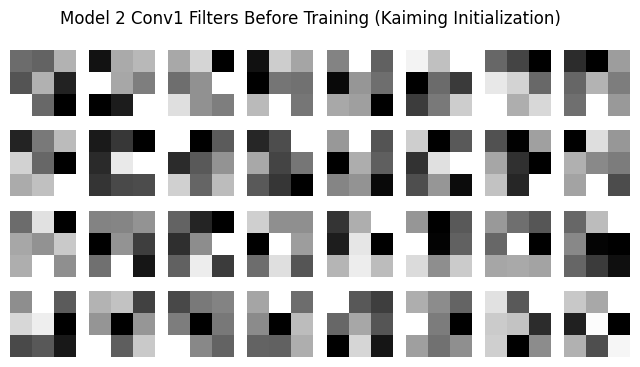

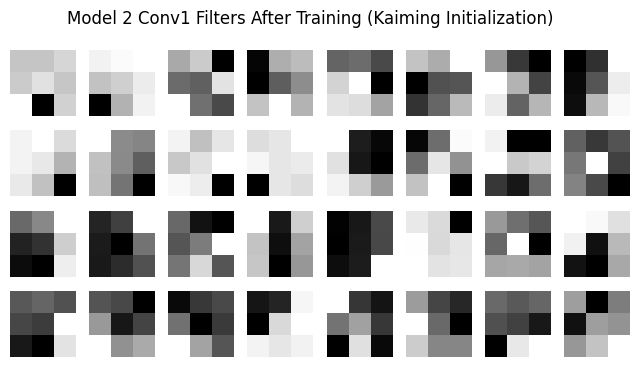

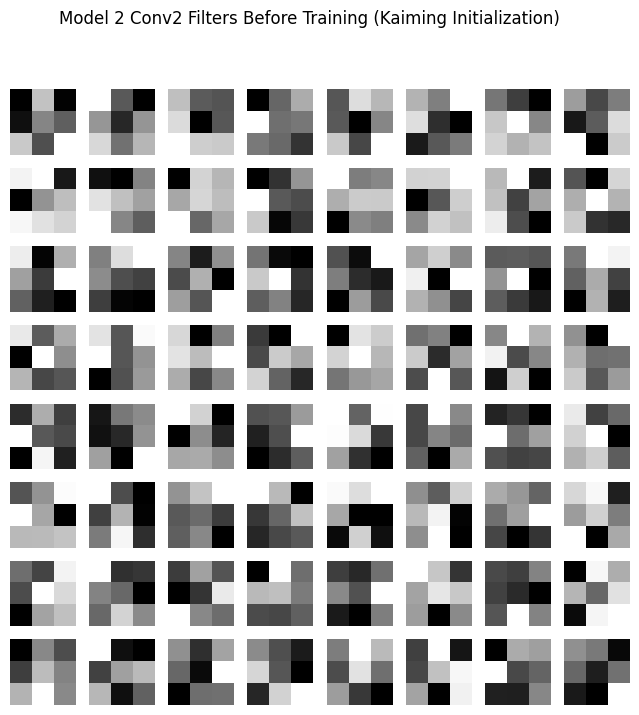

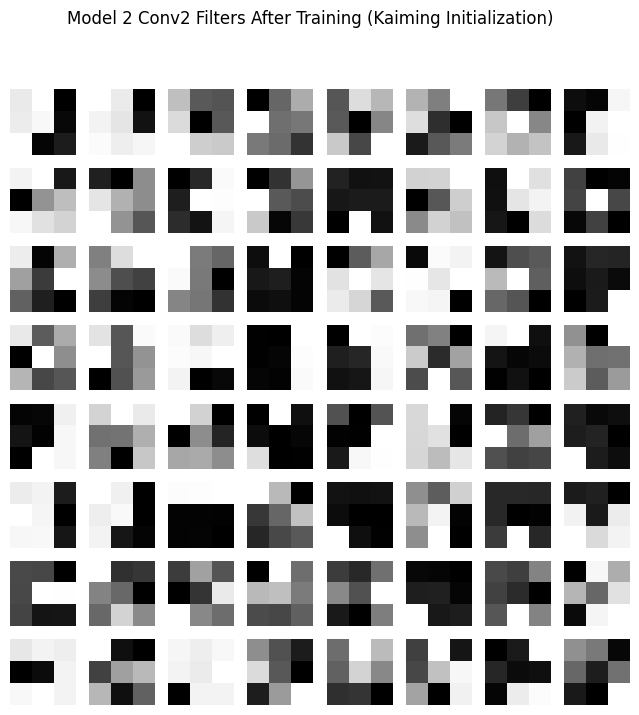

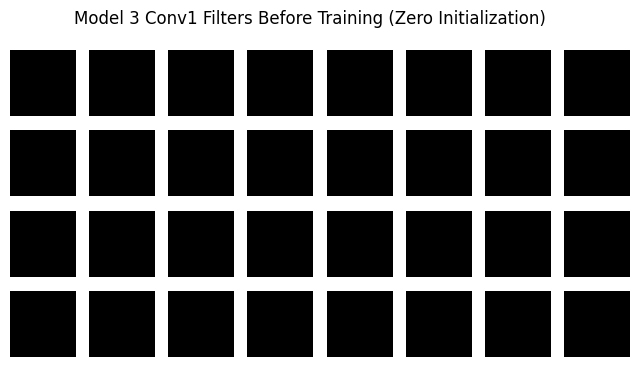

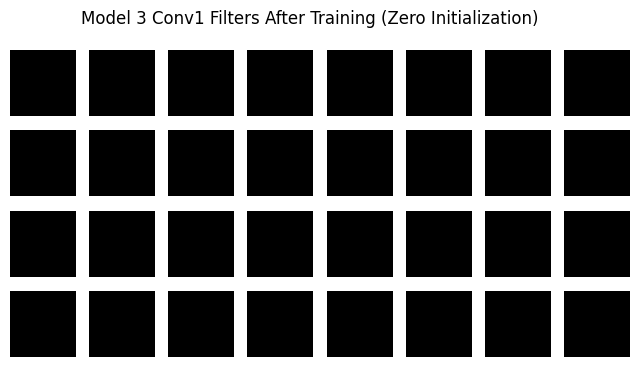

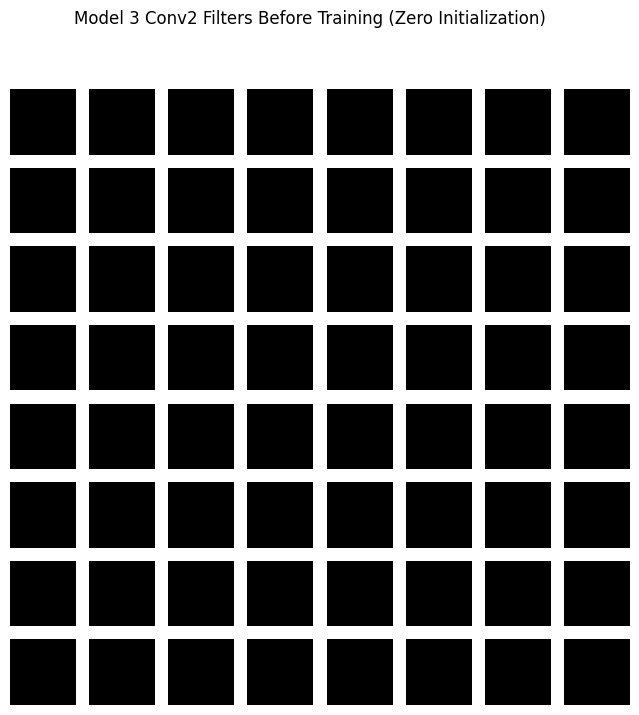

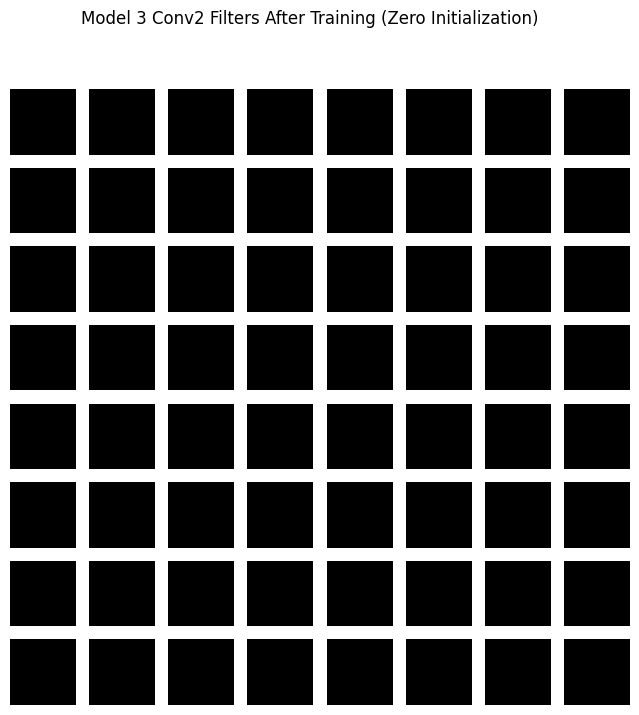

In [40]:
main_weights_comparison(0.55)